In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import mplhep as hep
import yaml

In [2]:
yaml_file_path = '../../configs/ntuples/signal_2mu2e_v10.yaml'
# Open and read the YAML file
with open(yaml_file_path, 'r') as file:
    data = yaml.safe_load(file)
signals_2mu2e_all = list(data["llpNanoAOD_v2"]["samples"].keys())

yaml_file_path = '../../configs/ntuples/signal_4mu_v10.yaml'
# Open and read the YAML file
with open(yaml_file_path, 'r') as file:
    data = yaml.safe_load(file)
signals_4mu_all = list(data["llpNanoAOD_v2"]["samples"].keys())

In [3]:
samples_bkg = [
    "TTJets",
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120", 
    "QCD_Pt120To170",
    "QCD_Pt170To300", 
    "QCD_Pt300To470",
    "QCD_Pt470To600", 
    "QCD_Pt600To800", 
    "QCD_Pt800To1000",
    "QCD_Pt1000", 
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50", 
]

In [4]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in signals_2mu2e_all:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = "signal_2mu2e.coffea"
        try: 
            output = coffea.util.load("data_control_region_1egmLj/"+filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead
Loading file for sample 2Mu2E_100GeV_0p25GeV_0p02mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_0p25GeV_0p2mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_0p25GeV_2p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_0p25GeV_10p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_0p25GeV_20p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_0p096mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_0p96mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_9p6mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_48p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_96p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_5p0GeV_0p4mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_5p0G

In [5]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}
    
#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in signals_4mu_all:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = "signal_4mu.coffea"
        try: 
            output = coffea.util.load("data_control_region_1egmLj/"+filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample 4Mu_100GeV_0p25GeV_0p02mm
Successfully opened file
Loading file for sample 4Mu_100GeV_0p25GeV_0p2mm
Successfully opened file
Loading file for sample 4Mu_100GeV_0p25GeV_2p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_0p25GeV_10p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_0p25GeV_20p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_0p096mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_0p96mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_9p6mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_48p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_96p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_5p0GeV_0p4mm
Successfully opened file
Loading file for sample 4Mu_100GeV_5p0GeV_4p0mm
Successfully opened file
Loading file for sample 4Mu_1

In [6]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples_bkg:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = sample + ".coffea"
        try: 
            output = coffea.util.load("data_control_region_1egmLj/"+filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample TTJets
Successfully opened file
Loading file for sample QCD_Pt15To20
Successfully opened file
Loading file for sample QCD_Pt20To30
Successfully opened file
Loading file for sample QCD_Pt30To50
Successfully opened file
Loading file for sample QCD_Pt50To80
Successfully opened file
Loading file for sample QCD_Pt80To120
Successfully opened file
Loading file for sample QCD_Pt120To170
Successfully opened file
Loading file for sample QCD_Pt170To300
Successfully opened file
Loading file for sample QCD_Pt300To470
Successfully opened file
Loading file for sample QCD_Pt470To600
Successfully opened file
Loading file for sample QCD_Pt600To800
Successfully opened file
Loading file for sample QCD_Pt800To1000
Successfully opened file
Loading file for sample QCD_Pt1000
Successfully opened file
Loading file for sample DYJetsToMuMu_M10to50
Successfully opened file
Loading file for sample DYJetsToMuMu

In [7]:
channels = [
    "data_control_region_1egmLj",
]

In [8]:
map_2mu2e = {
    100: [
        "2Mu2E_100GeV_0p25GeV_0p02mm",
        "2Mu2E_100GeV_0p25GeV_20p0mm",
        "2Mu2E_100GeV_1p2GeV_0p096mm",
        "2Mu2E_100GeV_1p2GeV_96p0mm",
        "2Mu2E_100GeV_5p0GeV_0p4mm",
        "2Mu2E_100GeV_5p0GeV_400mm",
    ],
    150: [
        "2Mu2E_150GeV_0p25GeV_0p013mm",
        "2Mu2E_150GeV_0p25GeV_13p0mm",
        "2Mu2E_150GeV_1p2GeV_0p064mm",
        "2Mu2E_150GeV_1p2GeV_64p0mm",
        "2Mu2E_150GeV_5p0GeV_0p27mm",
        "2Mu2E_150GeV_5p0GeV_270p0mm",
    ],
    200: [
        "2Mu2E_200GeV_0p25GeV_0p01mm",
        "2Mu2E_200GeV_0p25GeV_10p0mm",
        "2Mu2E_200GeV_1p2GeV_0p048mm",
        "2Mu2E_200GeV_1p2GeV_48p0mm",
        "2Mu2E_200GeV_5p0GeV_0p2mm",
        "2Mu2E_200GeV_5p0GeV_200p0mm",
    ],
    500: [
        "2Mu2E_500GeV_0p25GeV_0p004mm",
        "2Mu2E_500GeV_0p25GeV_4p0mm",
        "2Mu2E_500GeV_1p2GeV_0p019mm",
        "2Mu2E_500GeV_1p2GeV_19p0mm",
        "2Mu2E_500GeV_5p0GeV_0p08mm",
        "2Mu2E_500GeV_5p0GeV_80p0mm",
    ],
    800: [
        "2Mu2E_800GeV_0p25GeV_0p0025mm",
        "2Mu2E_800GeV_0p25GeV_2p5mm",
        "2Mu2E_800GeV_1p2GeV_0p012mm",
        "2Mu2E_800GeV_1p2GeV_12p0mm",
        "2Mu2E_800GeV_5p0GeV_0p05mm",
        "2Mu2E_800GeV_5p0GeV_50p0mm",
    ],
    1000: [
        "2Mu2E_1000GeV_0p25GeV_0p002mm",
        "2Mu2E_1000GeV_0p25GeV_2p0mm",
        "2Mu2E_1000GeV_1p2GeV_0p0096mm",
        "2Mu2E_1000GeV_1p2GeV_9p6mm",
        "2Mu2E_1000GeV_5p0GeV_0p04mm",
        "2Mu2E_1000GeV_5p0GeV_40p0mm",
    ],
}

In [9]:
QCD = [
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    "QCD_Pt800To1000",
    "QCD_Pt1000",
]

DY = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
]

TT = ["TTJets"]

In [10]:
backgrounds = {
    "TT": TT,
    r"DY $\rightarrow \mu\mu$": DY,
    "QCD": QCD,
}

background_colors = {
    "TT": "#717581",
    r"DY $\rightarrow \mu\mu$": "#3f90da",
    "QCD": "#b9ac70",
}

signal_maps = {
    "2Mu2E": map_2mu2e,
}

signal_colors = ["r", "orange", "yellow", "lime", "cyan", "magenta"]

signal_linestyles = {
    "2Mu2E": "-",
    "4Mu": ":",
}

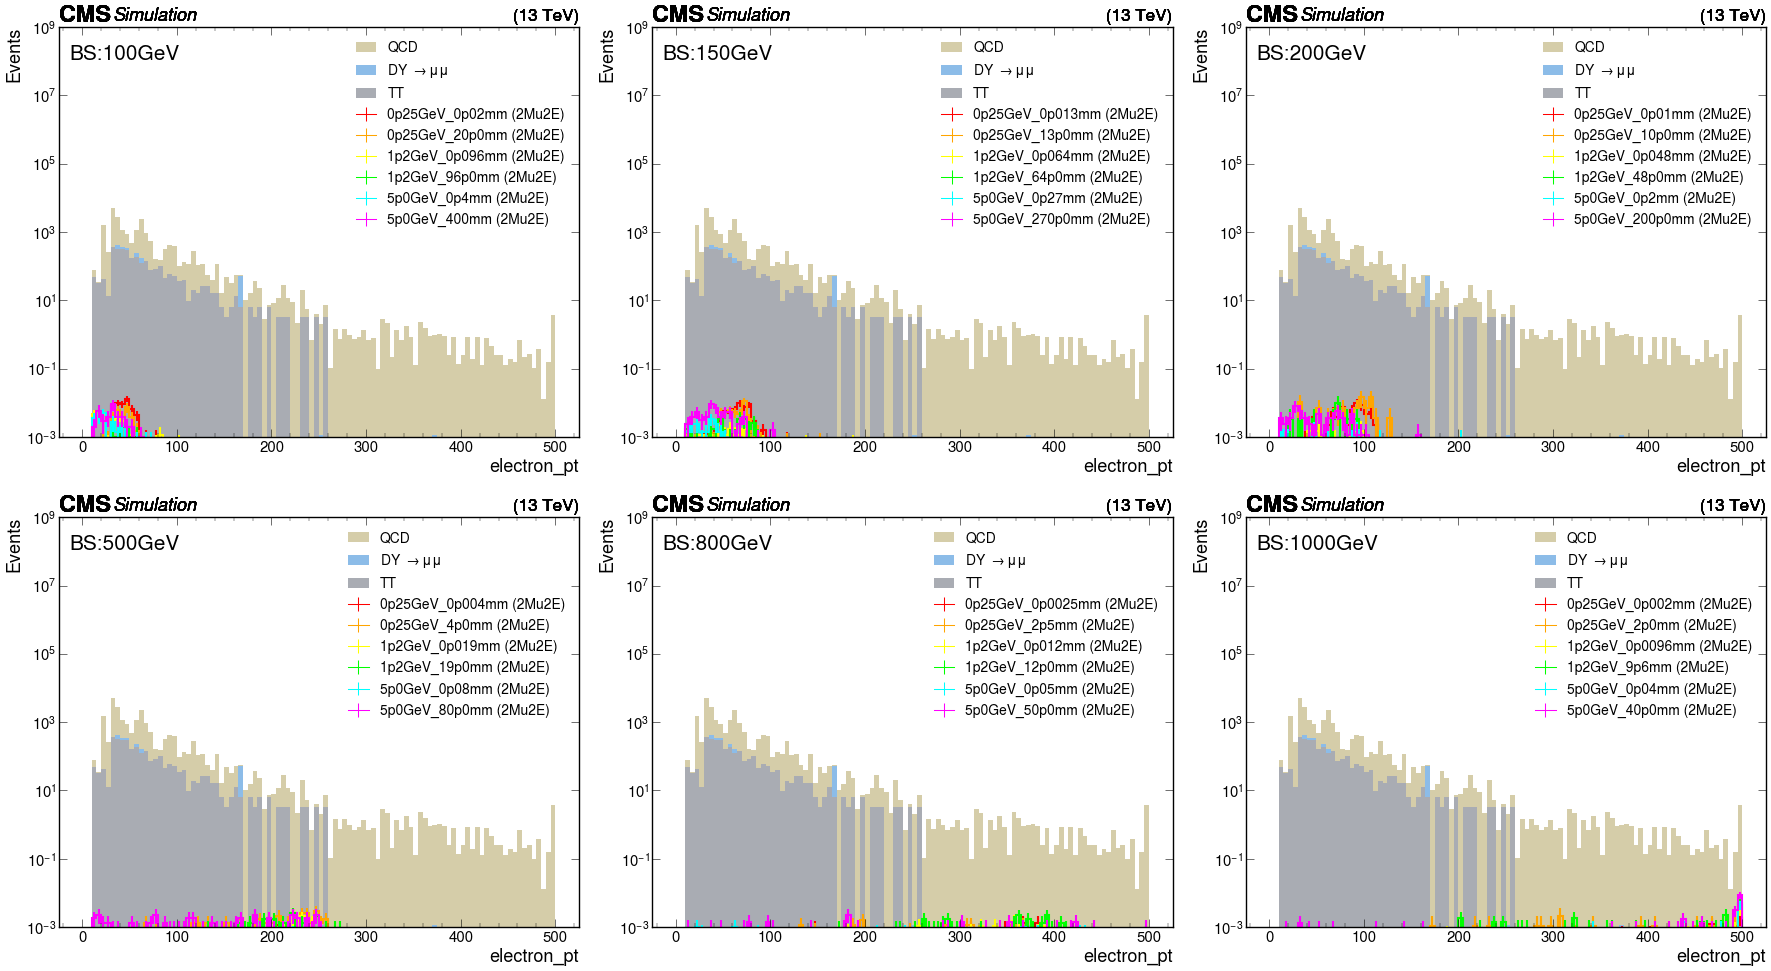

In [11]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

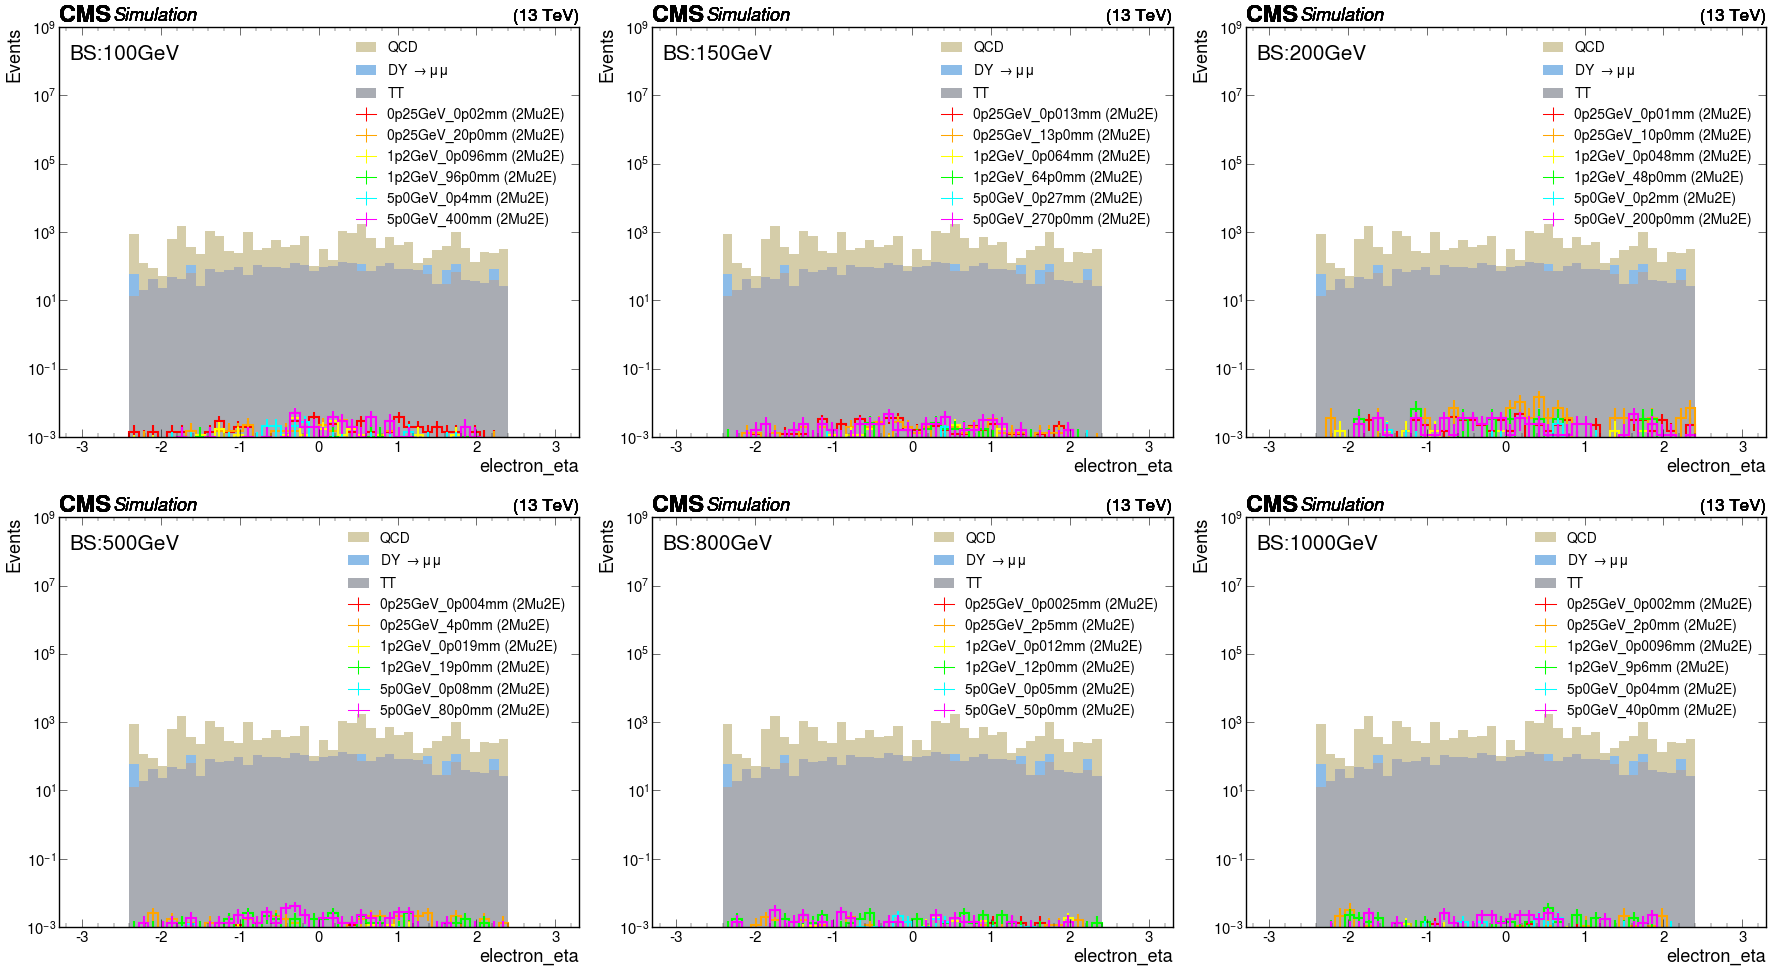

In [12]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_eta",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
    xlabel="electron_eta"
)

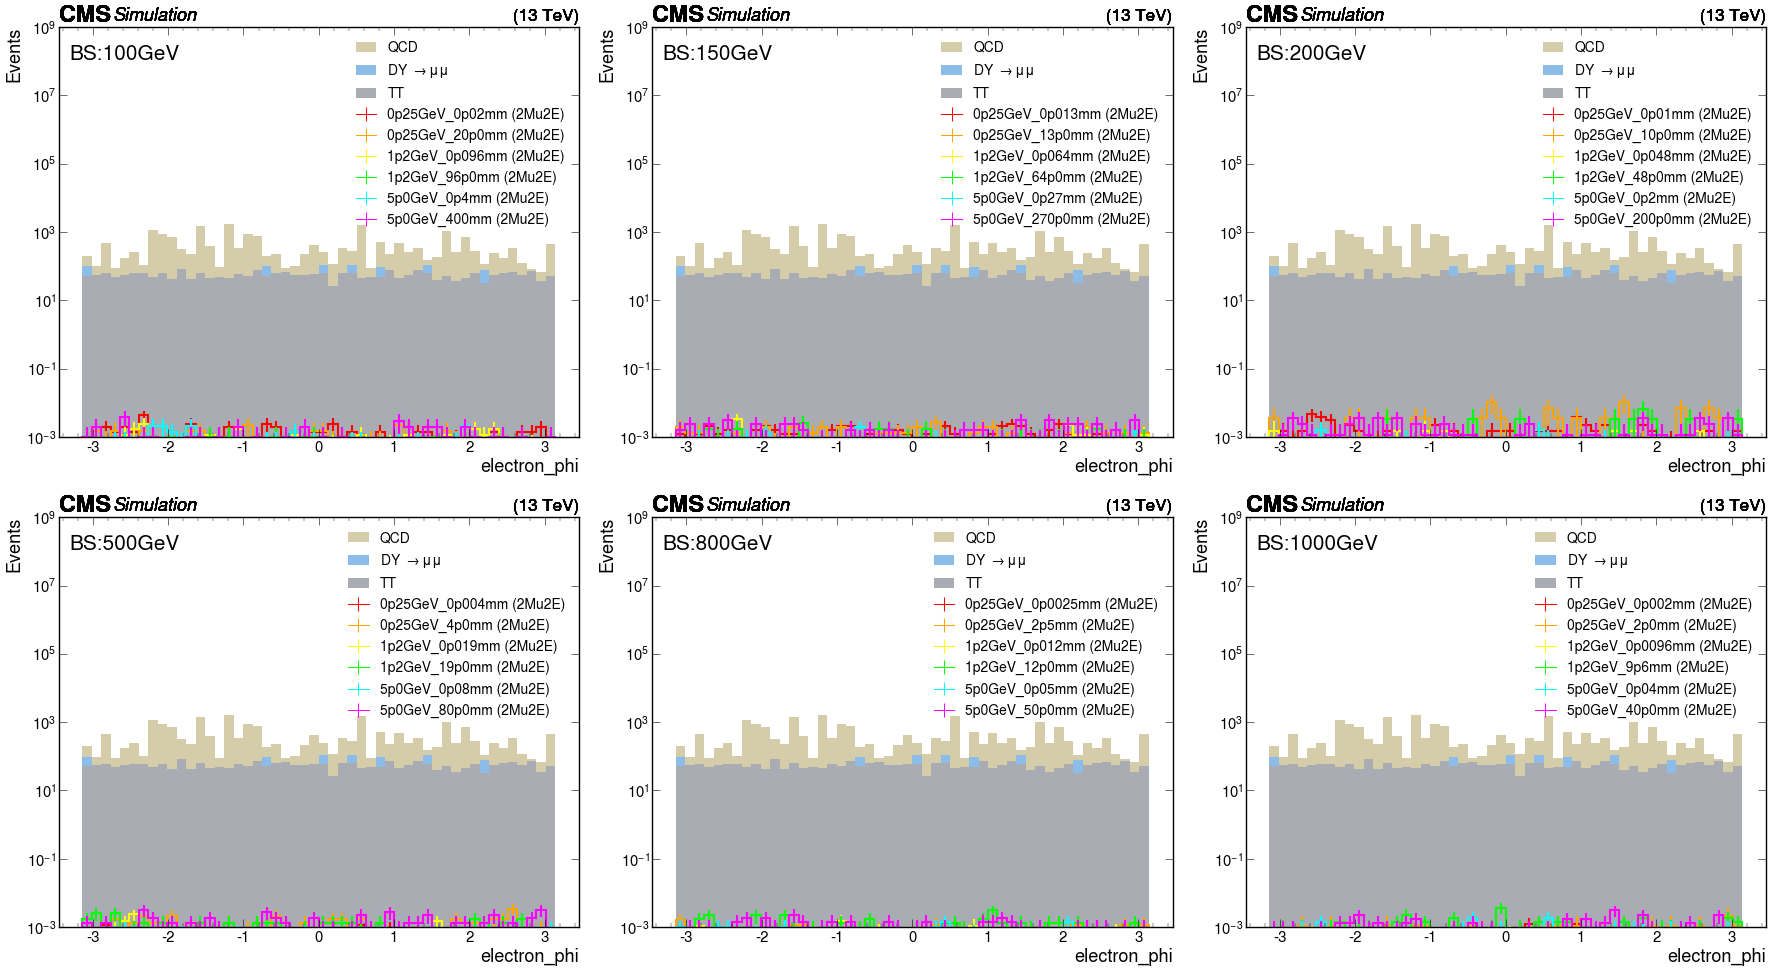

In [13]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_phi",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
    xlabel="electron_phi"
)

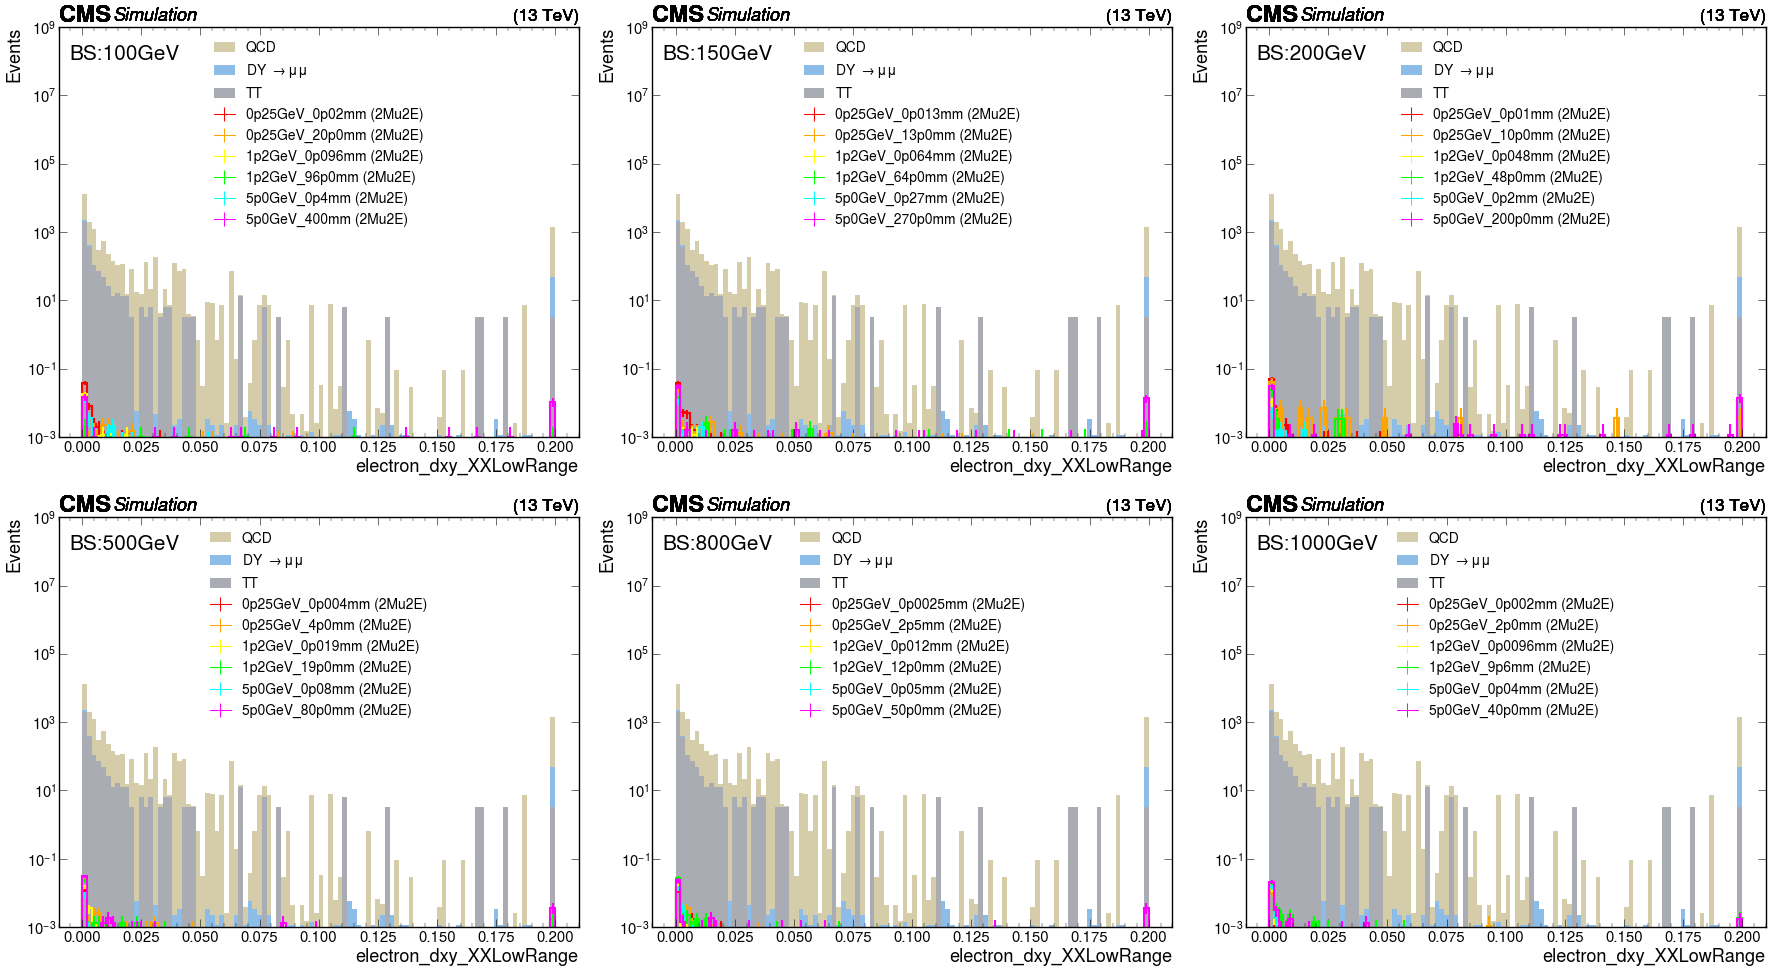

In [33]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_dxy_XXLowRange",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


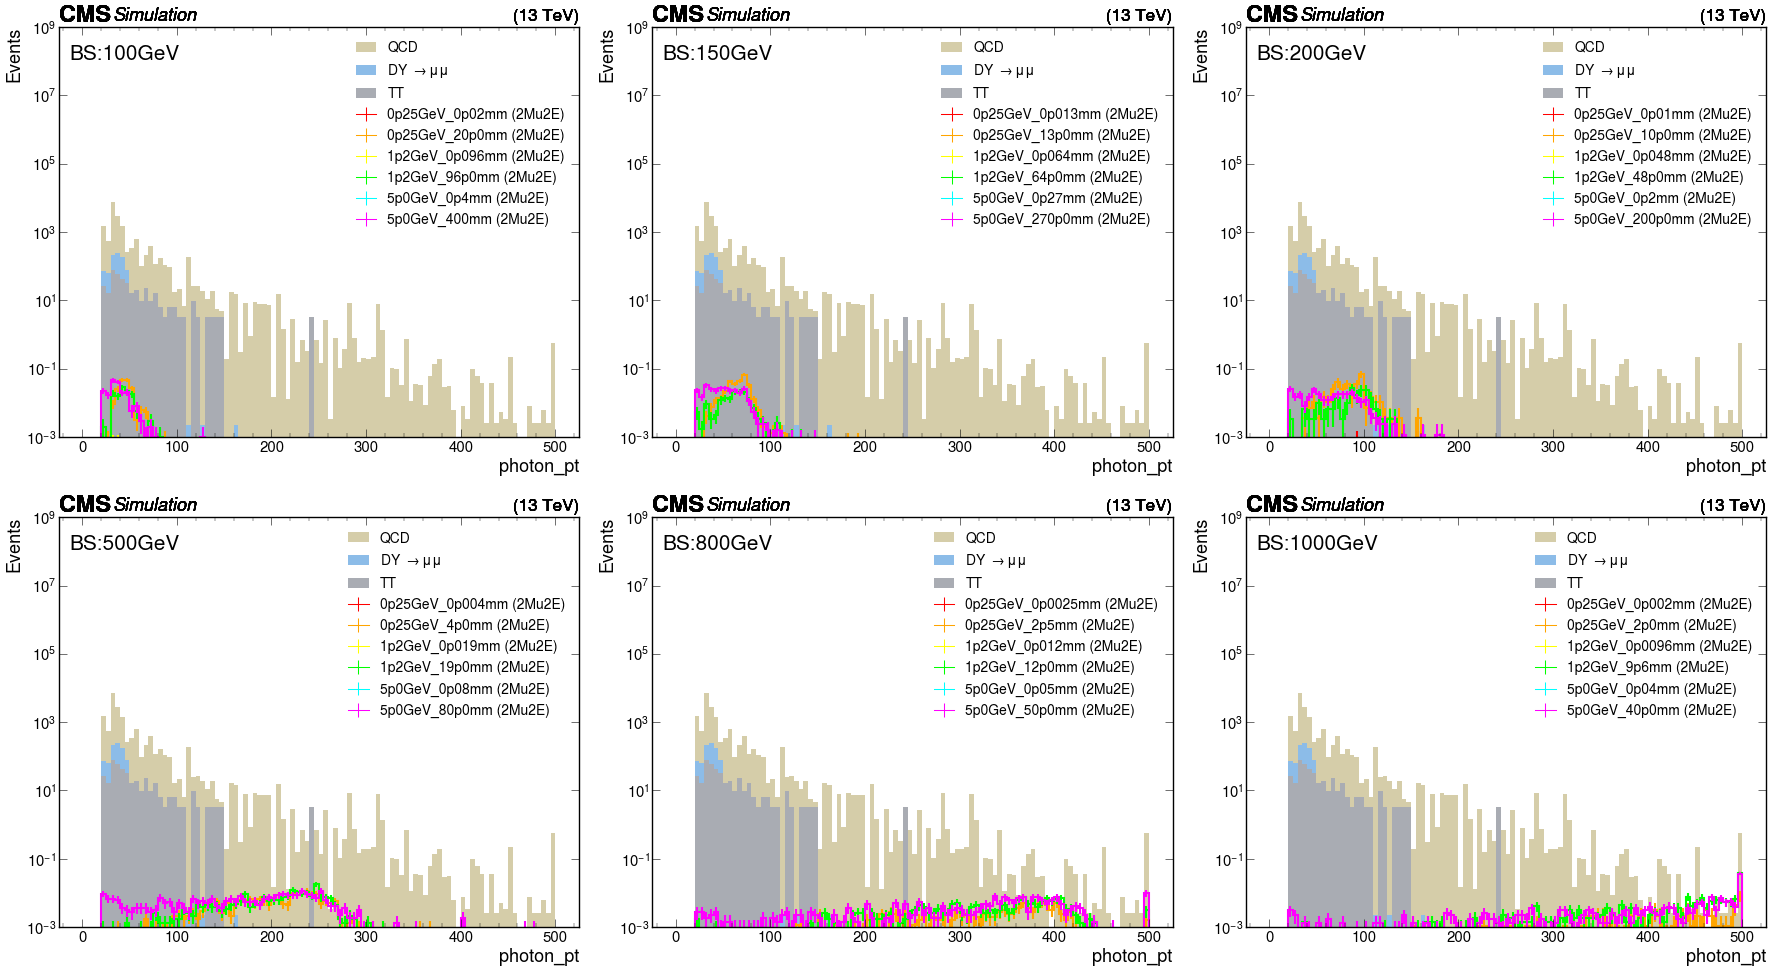

In [14]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


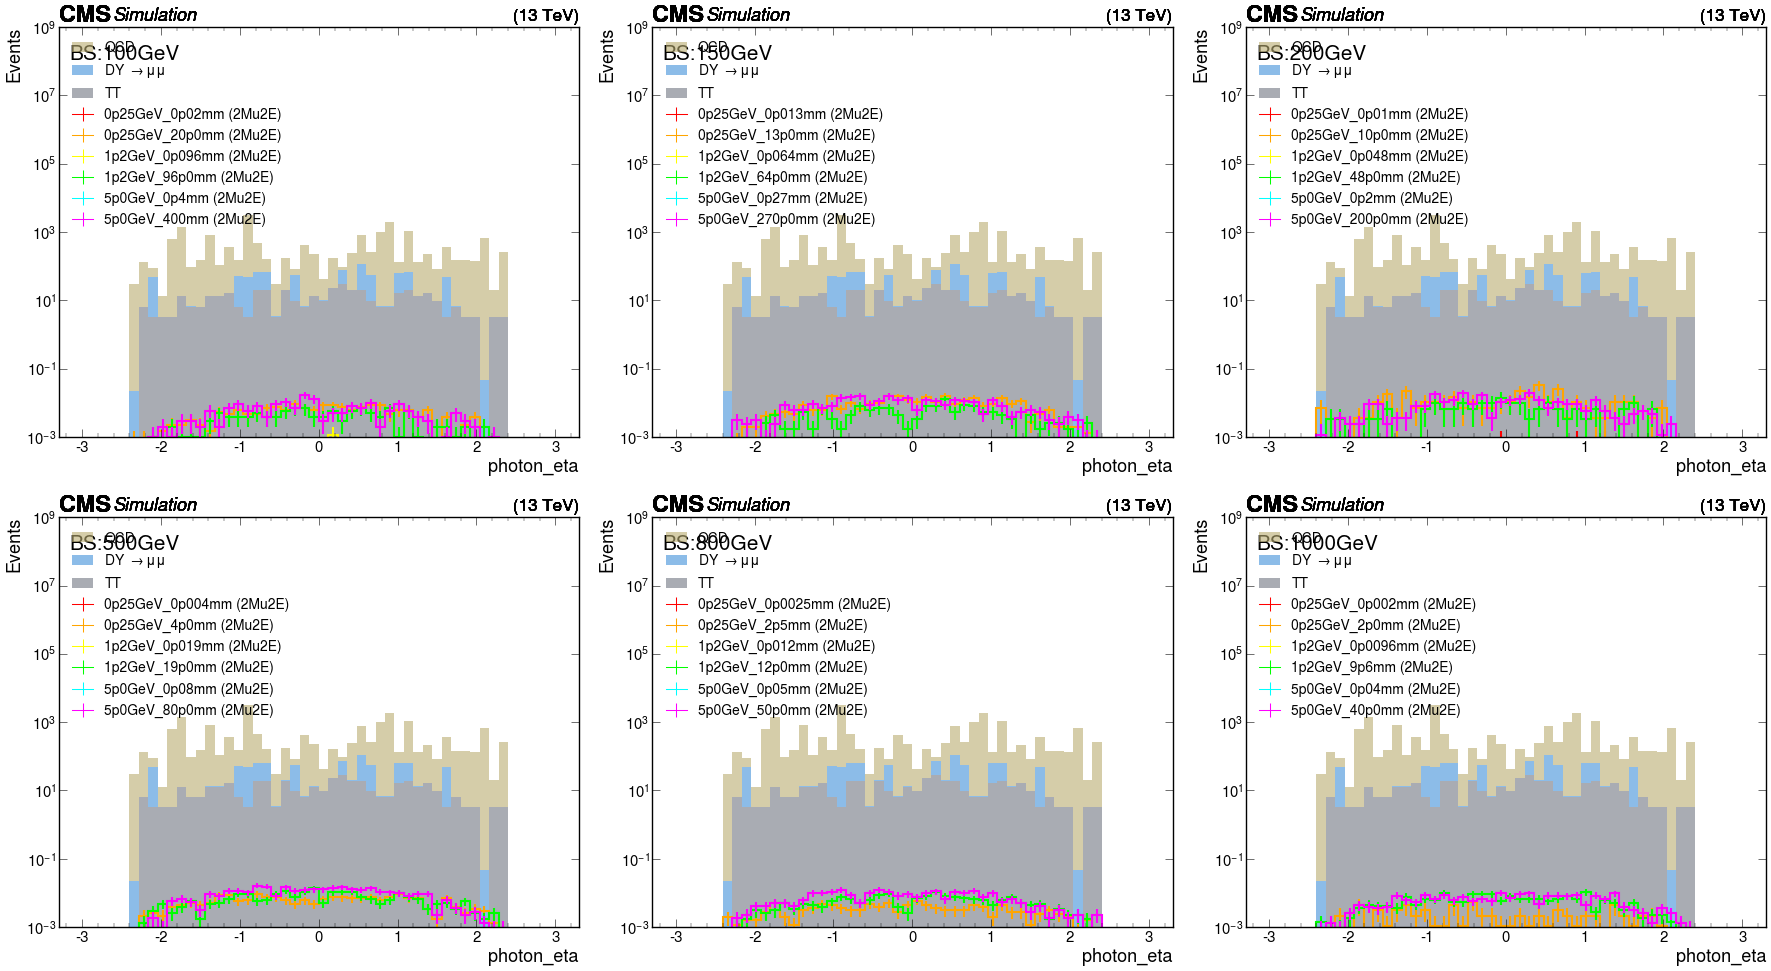

In [15]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_eta",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
    xlabel="photon_eta"
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


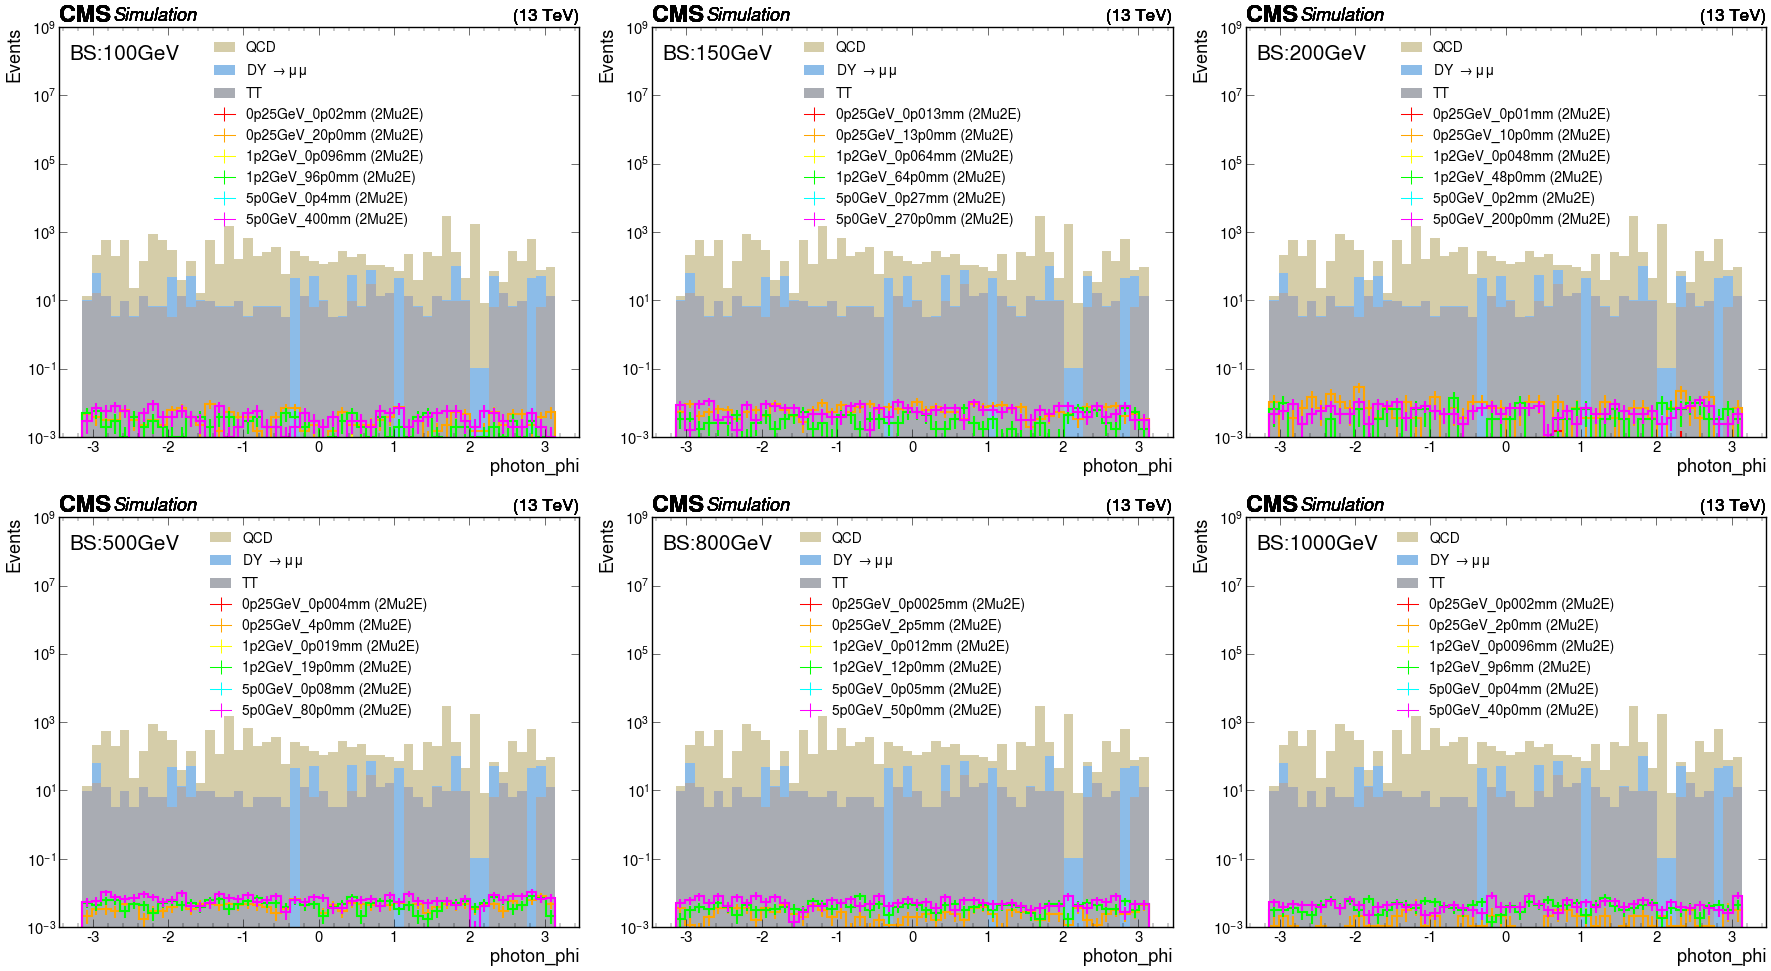

In [16]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_phi",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
    xlabel="photon_phi"
)

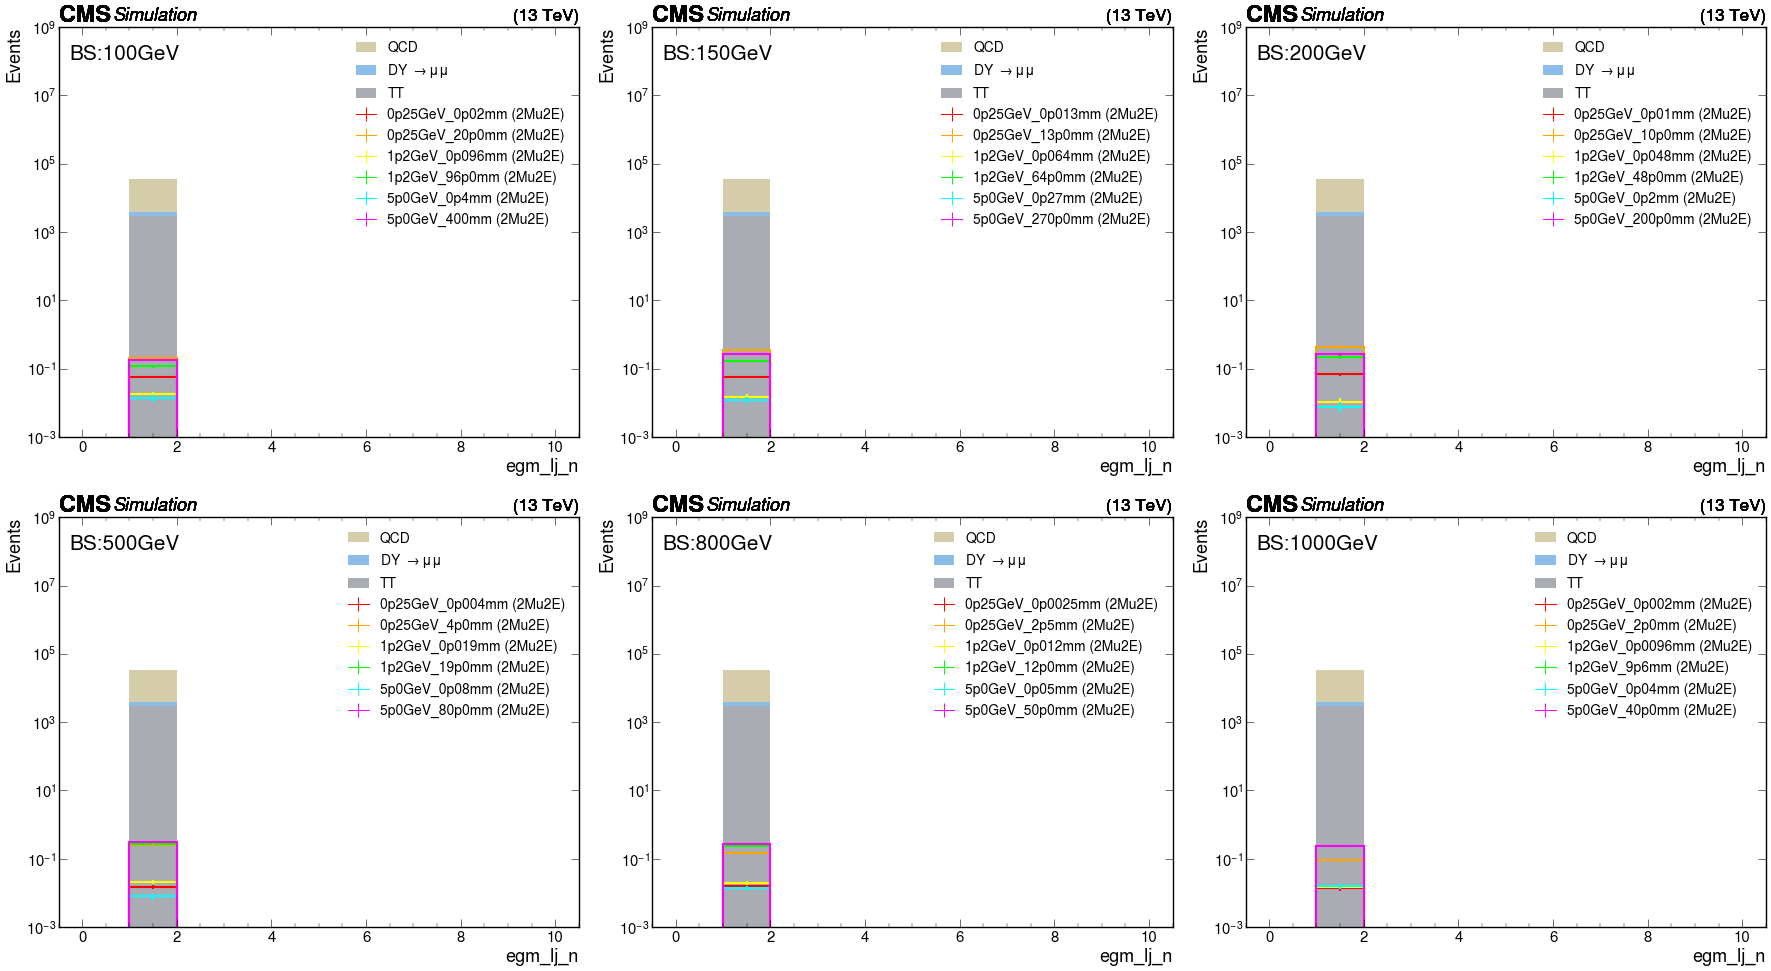

In [17]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_n",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

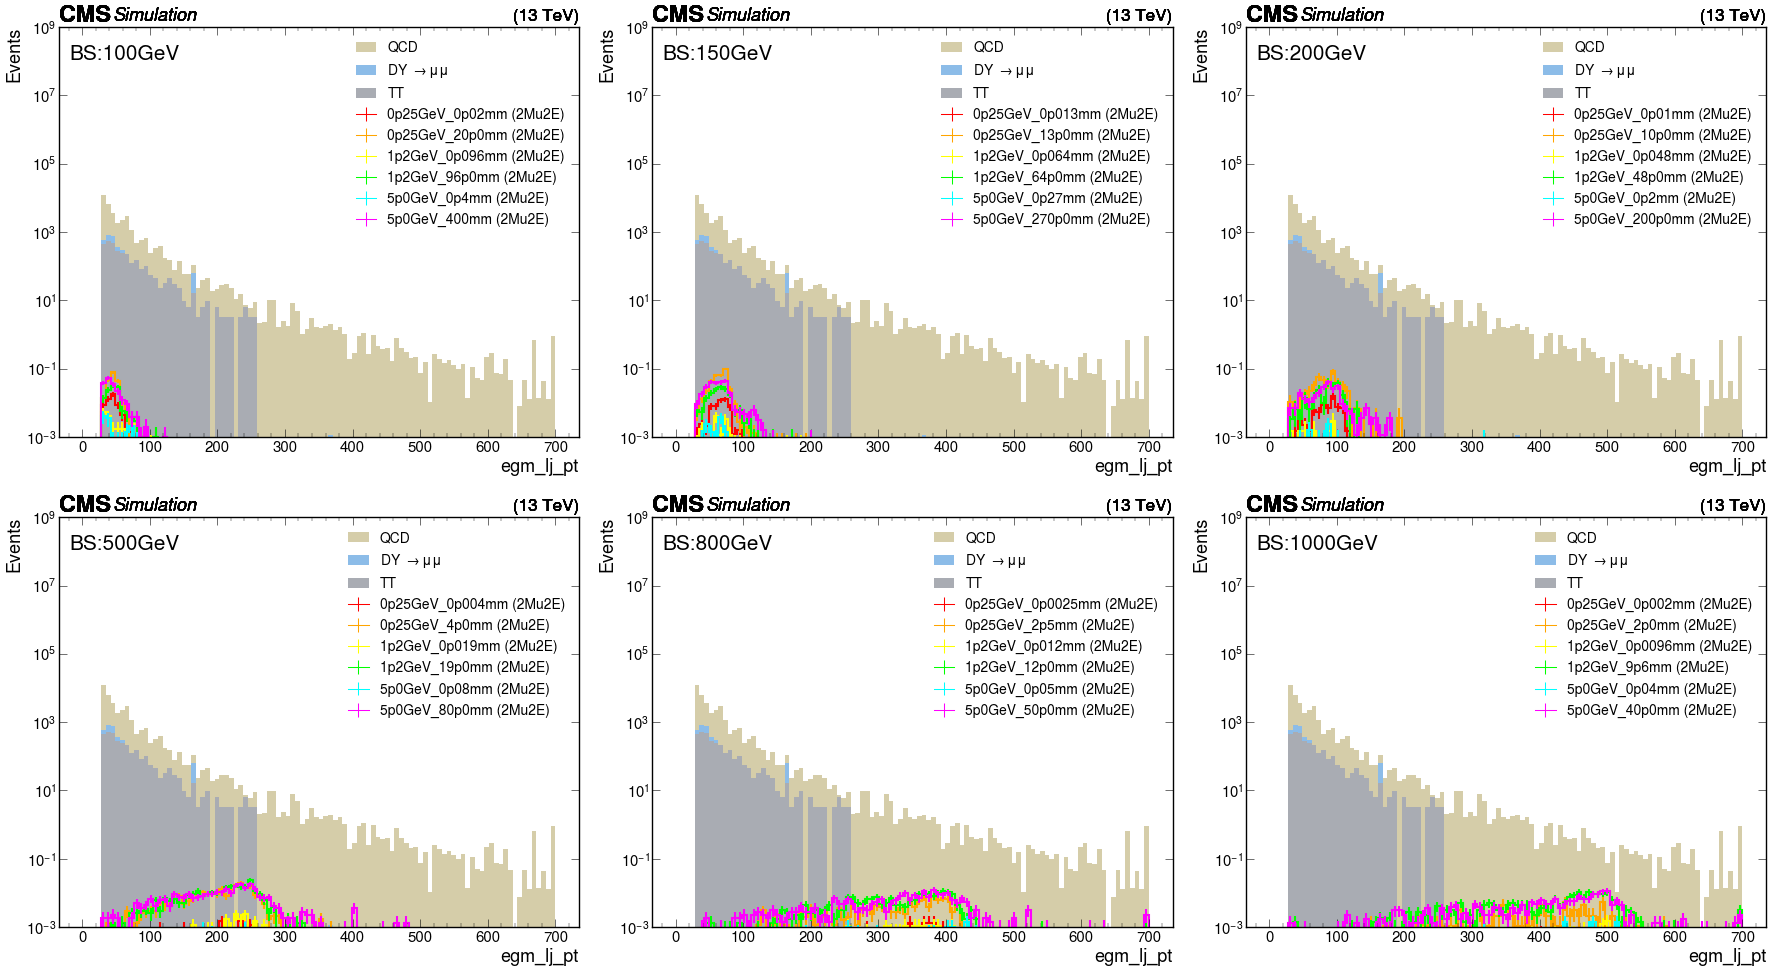

In [18]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

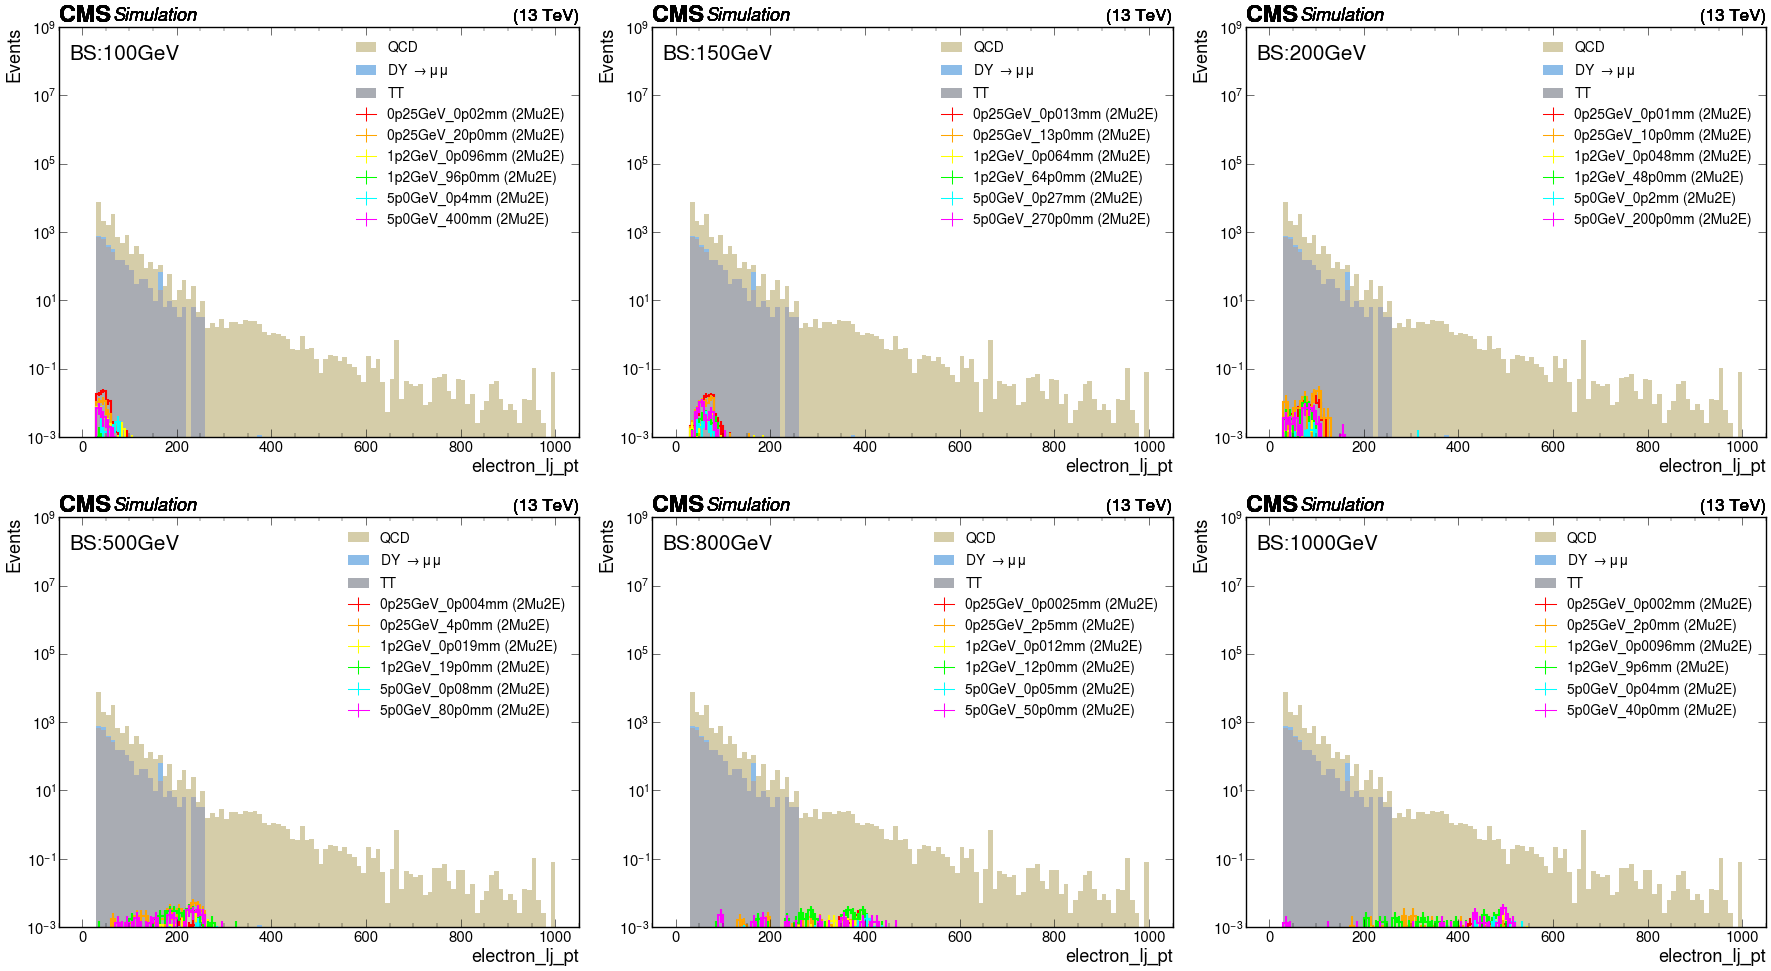

In [19]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_lj_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


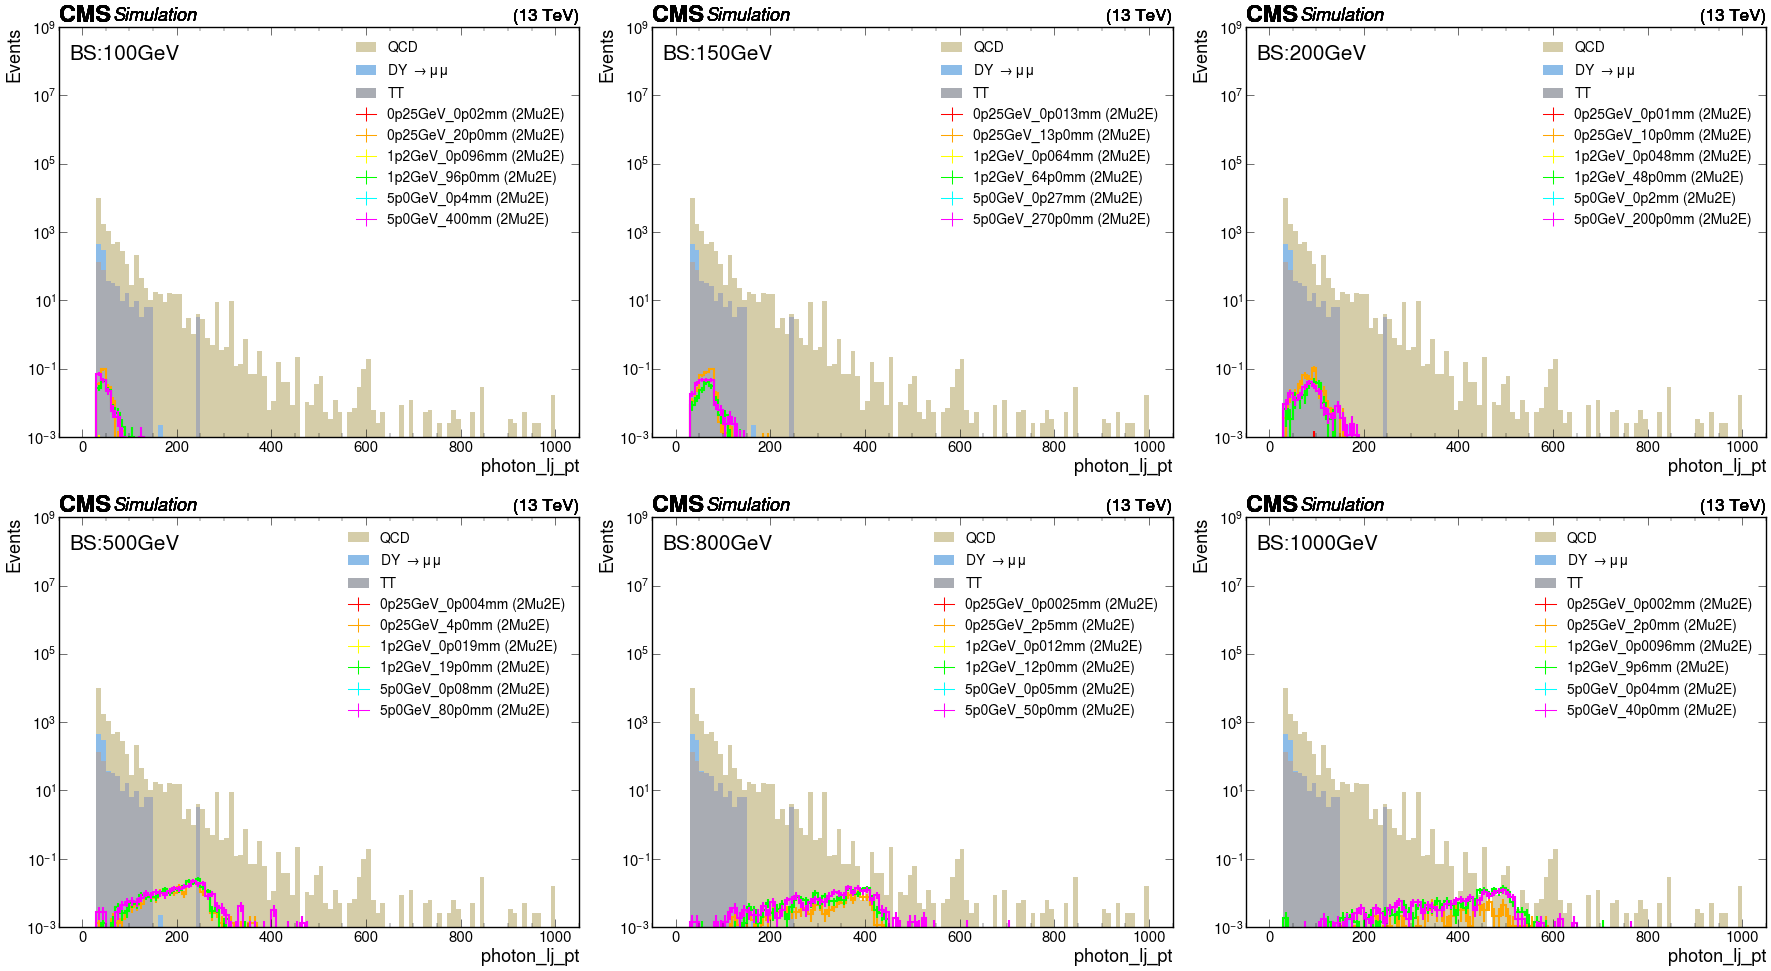

In [20]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_lj_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

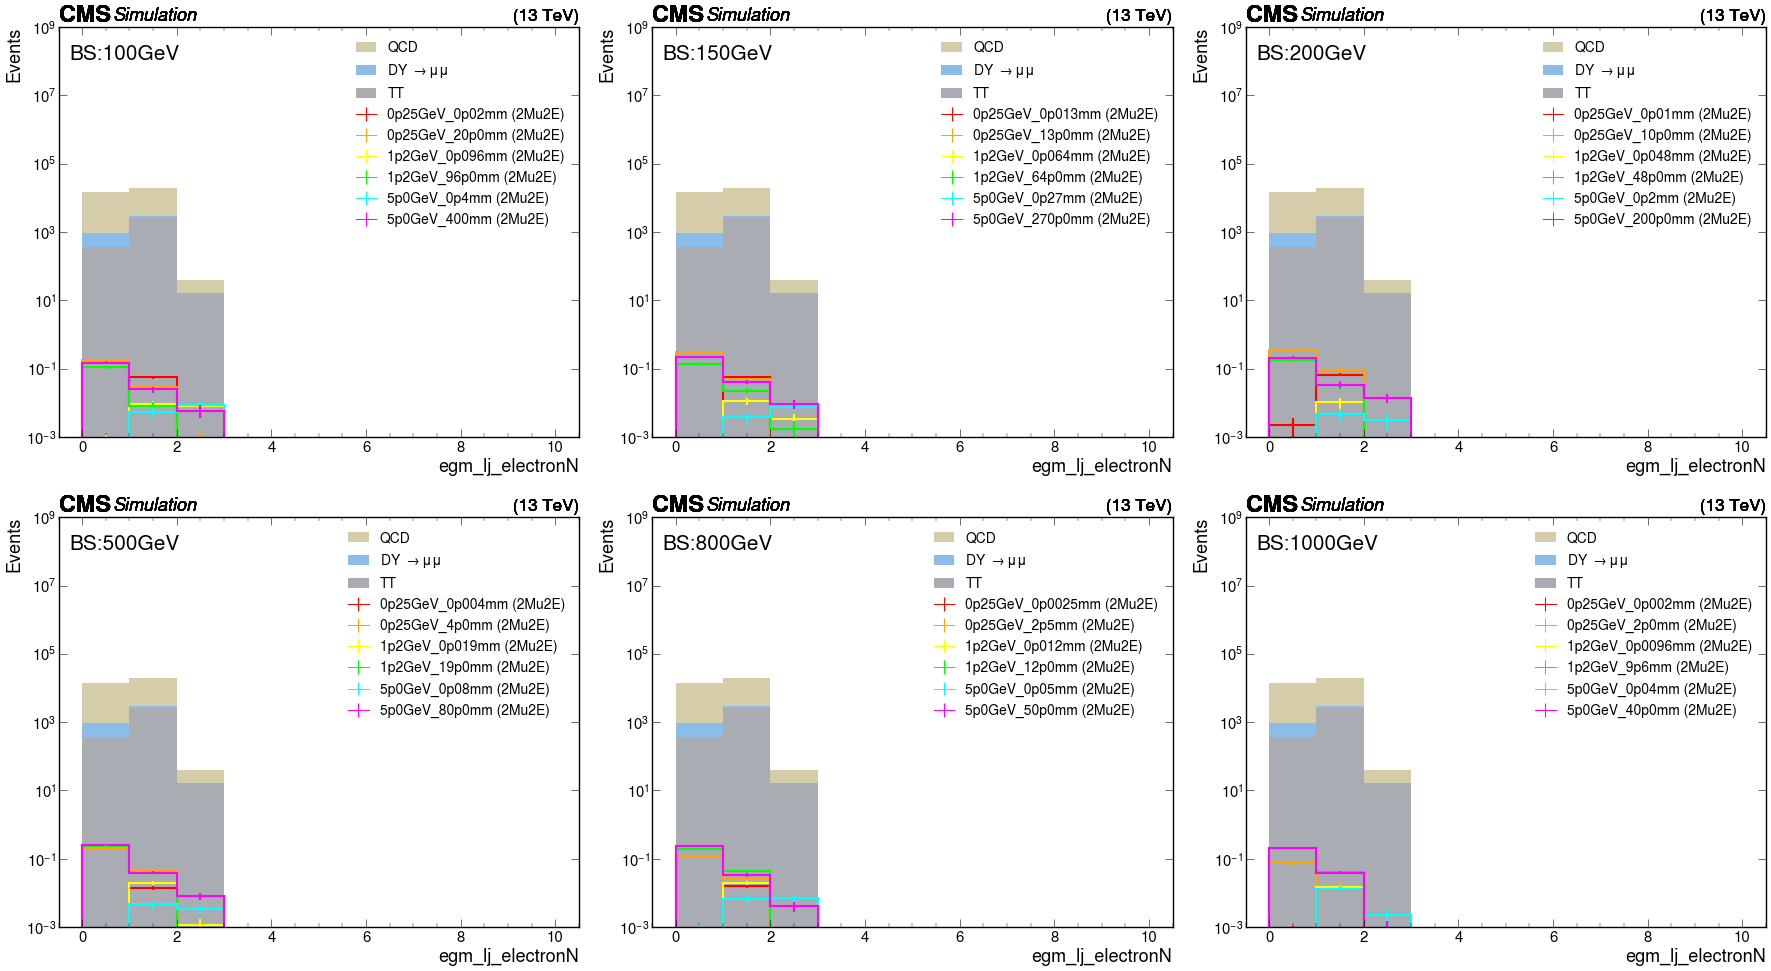

In [21]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_electronN",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

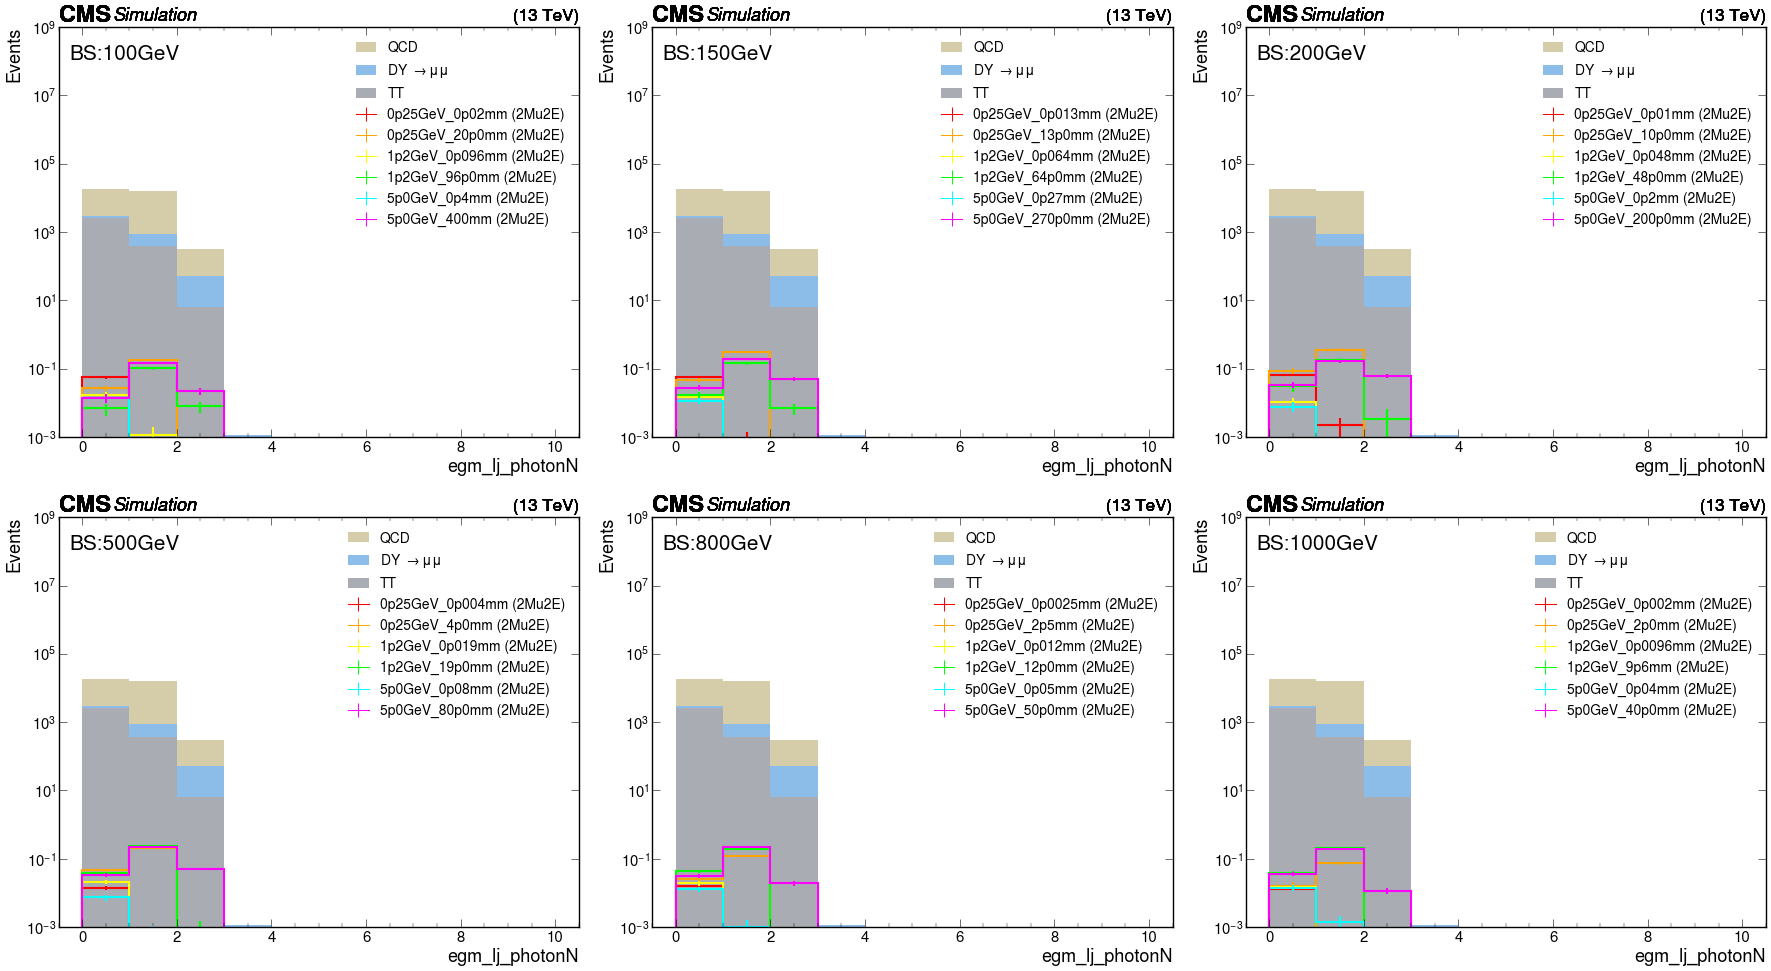

In [22]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_photonN",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

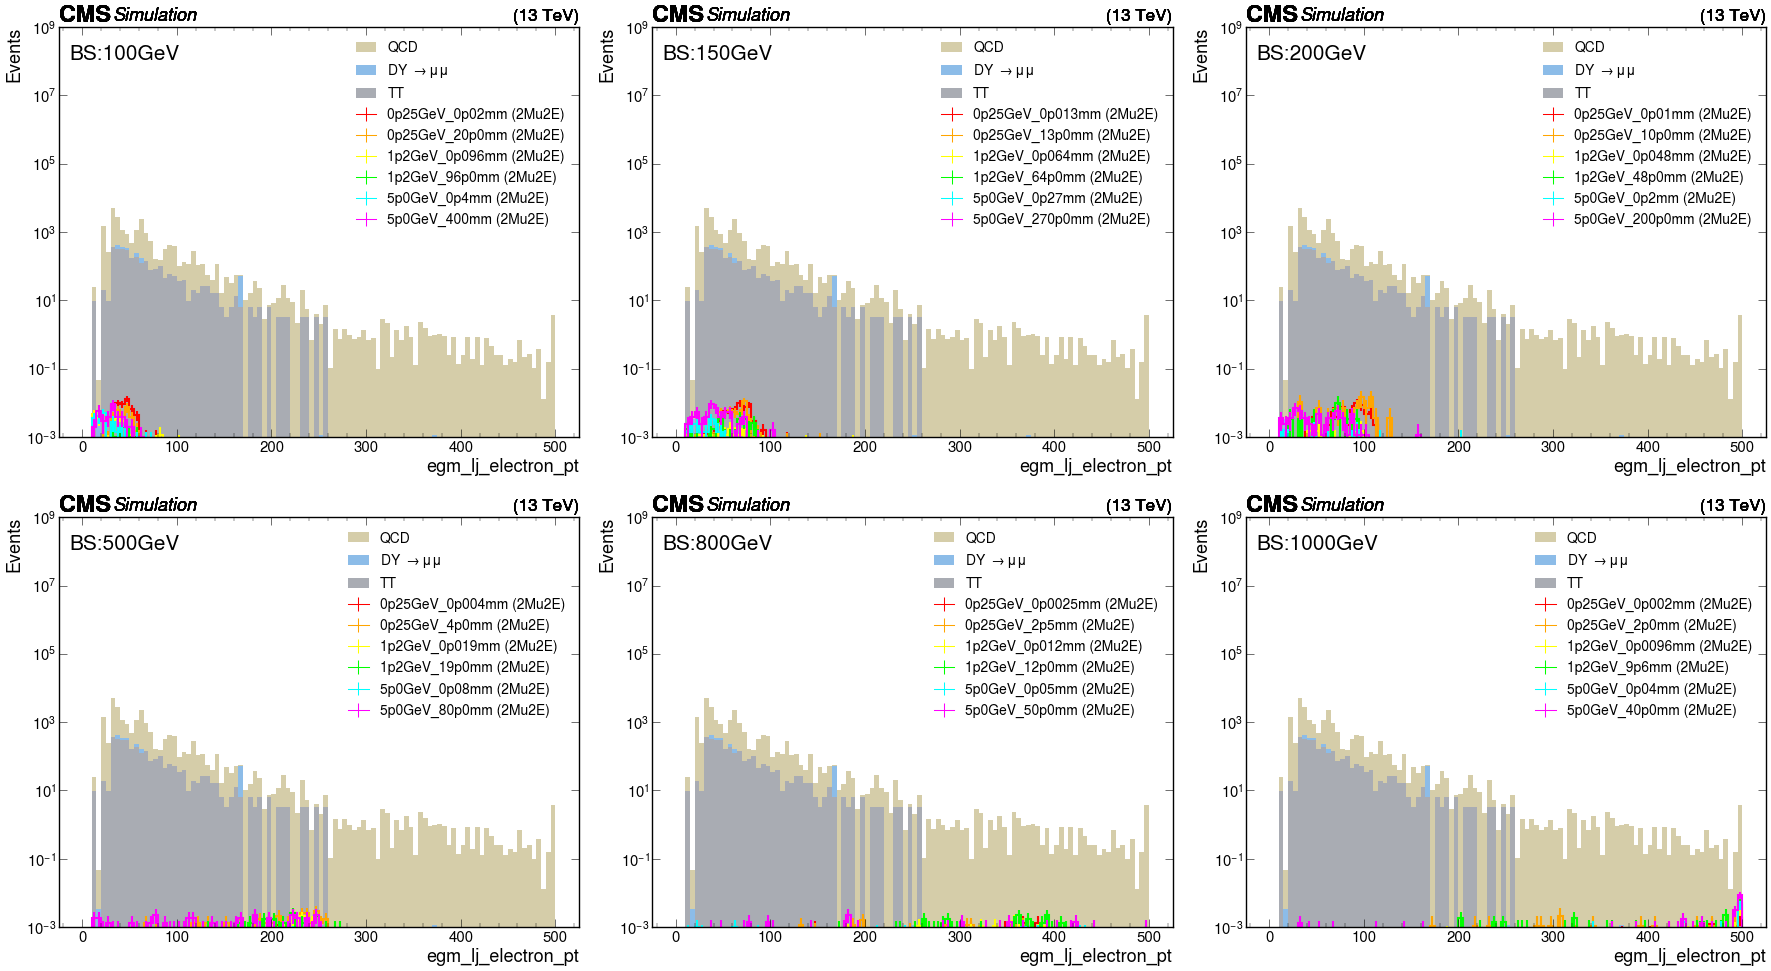

In [23]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_electron_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


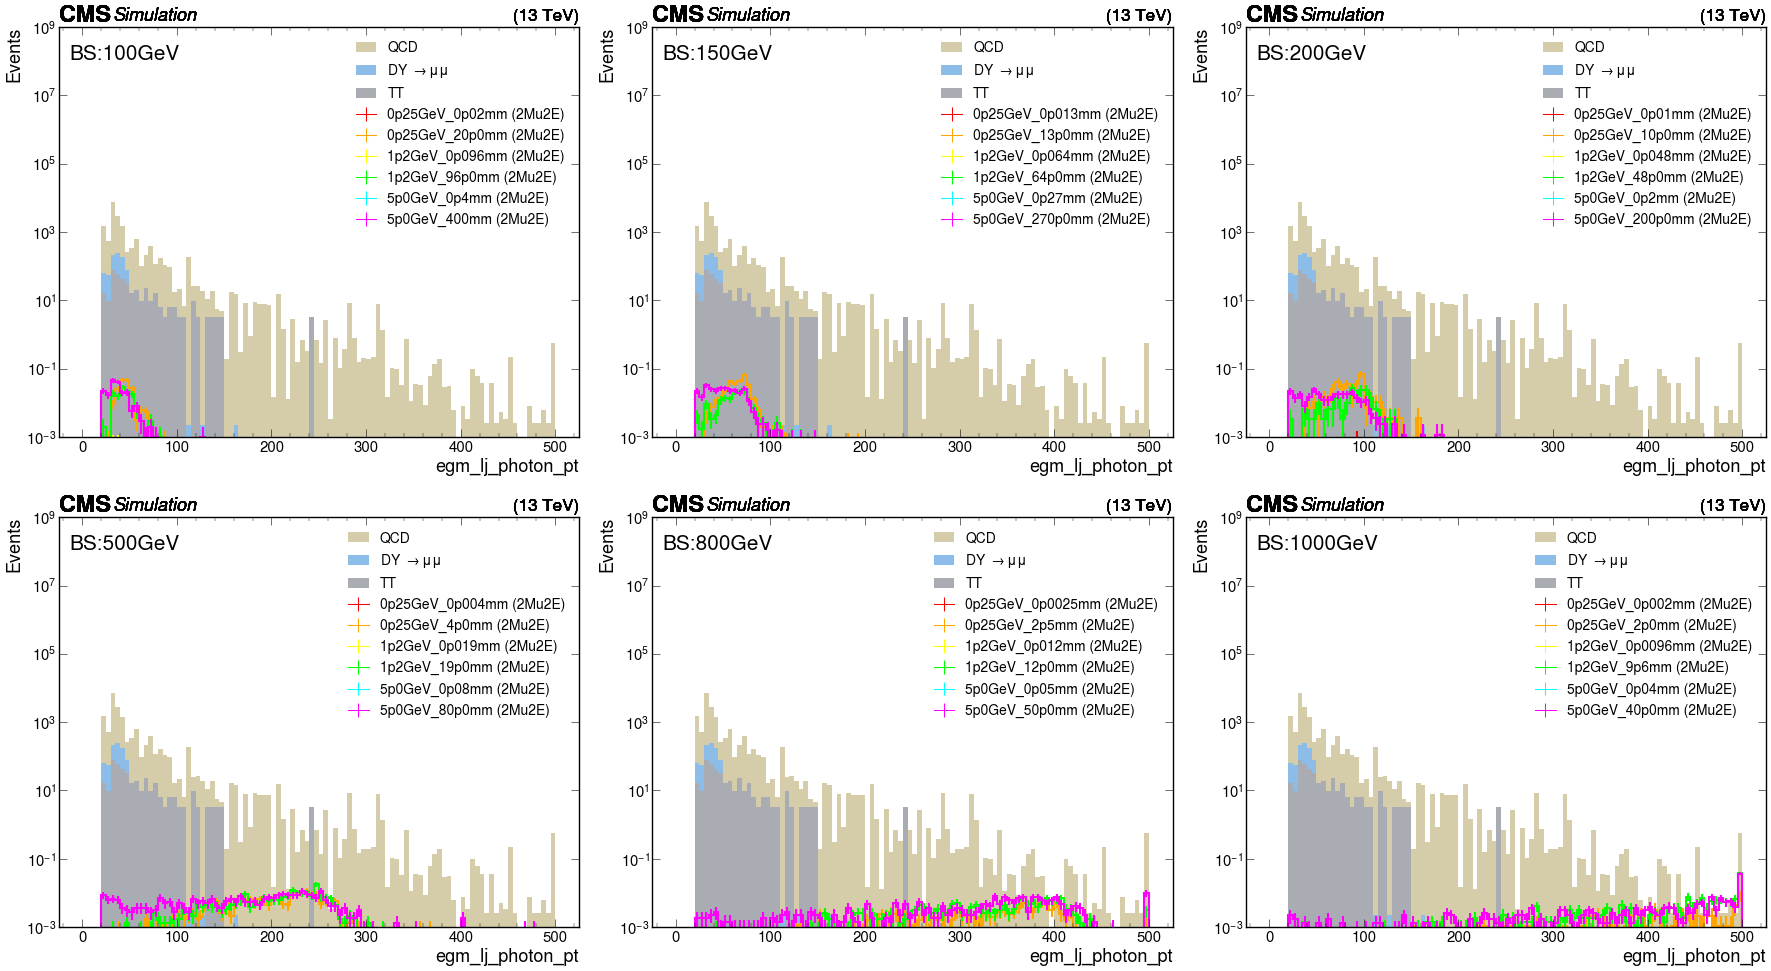

In [24]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_photon_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

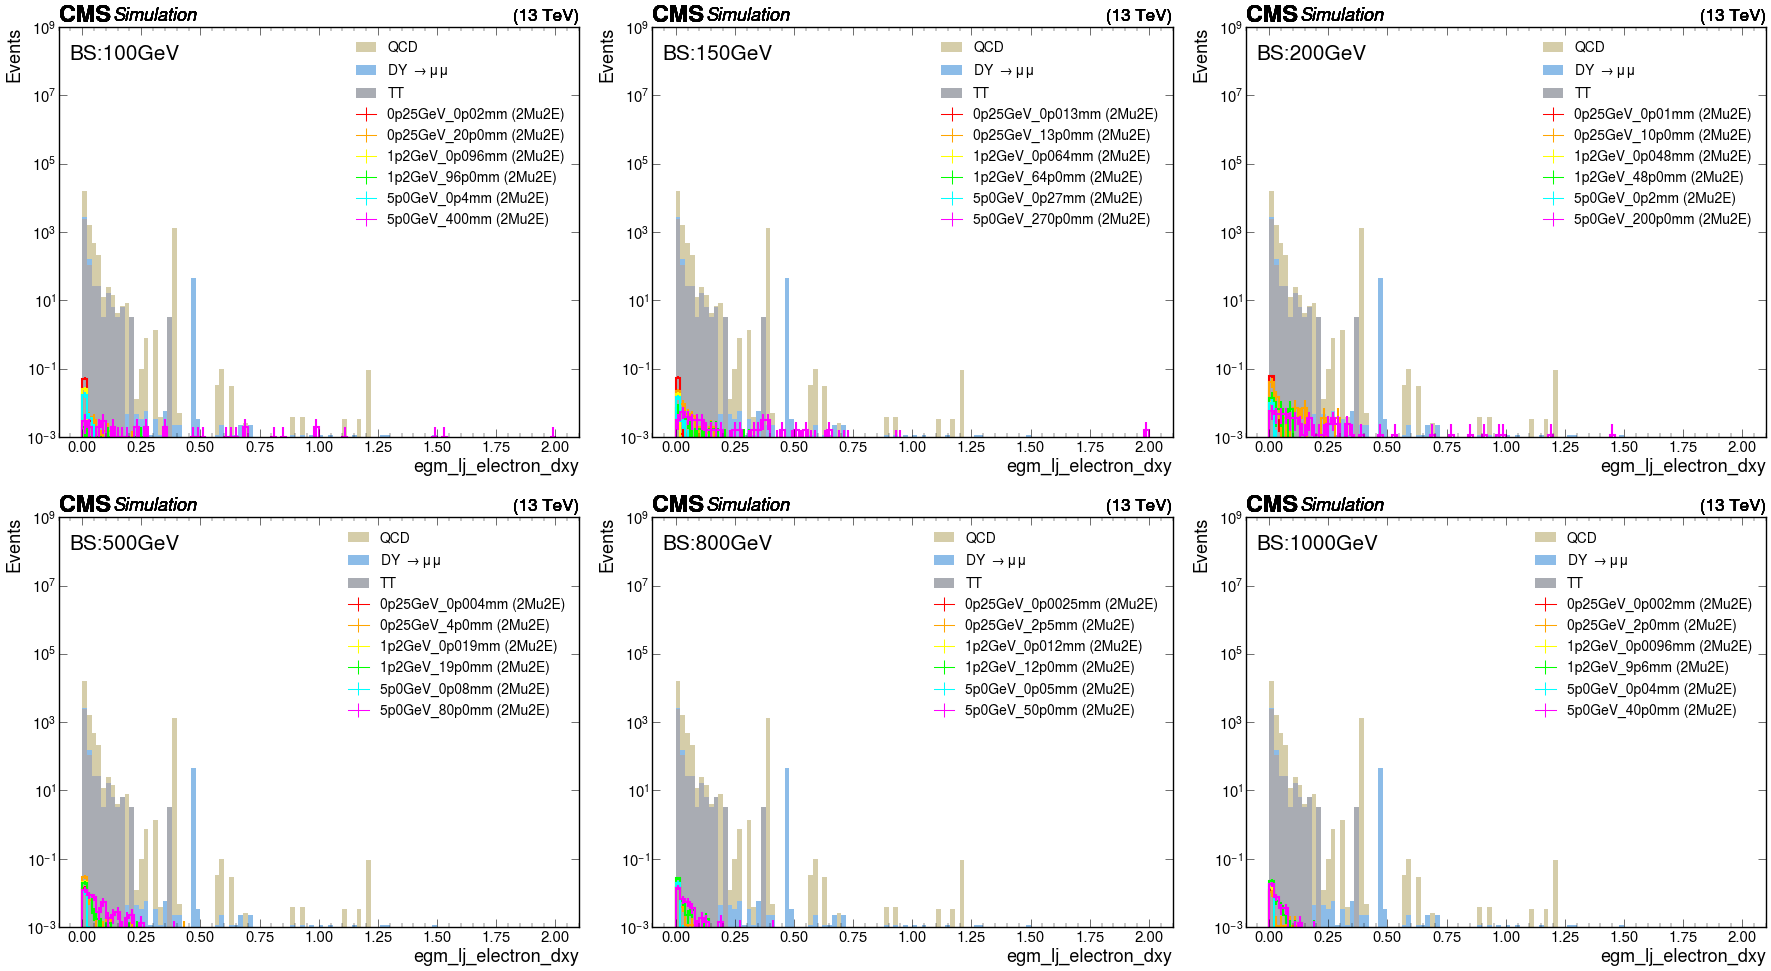

In [25]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_electron_dxy",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

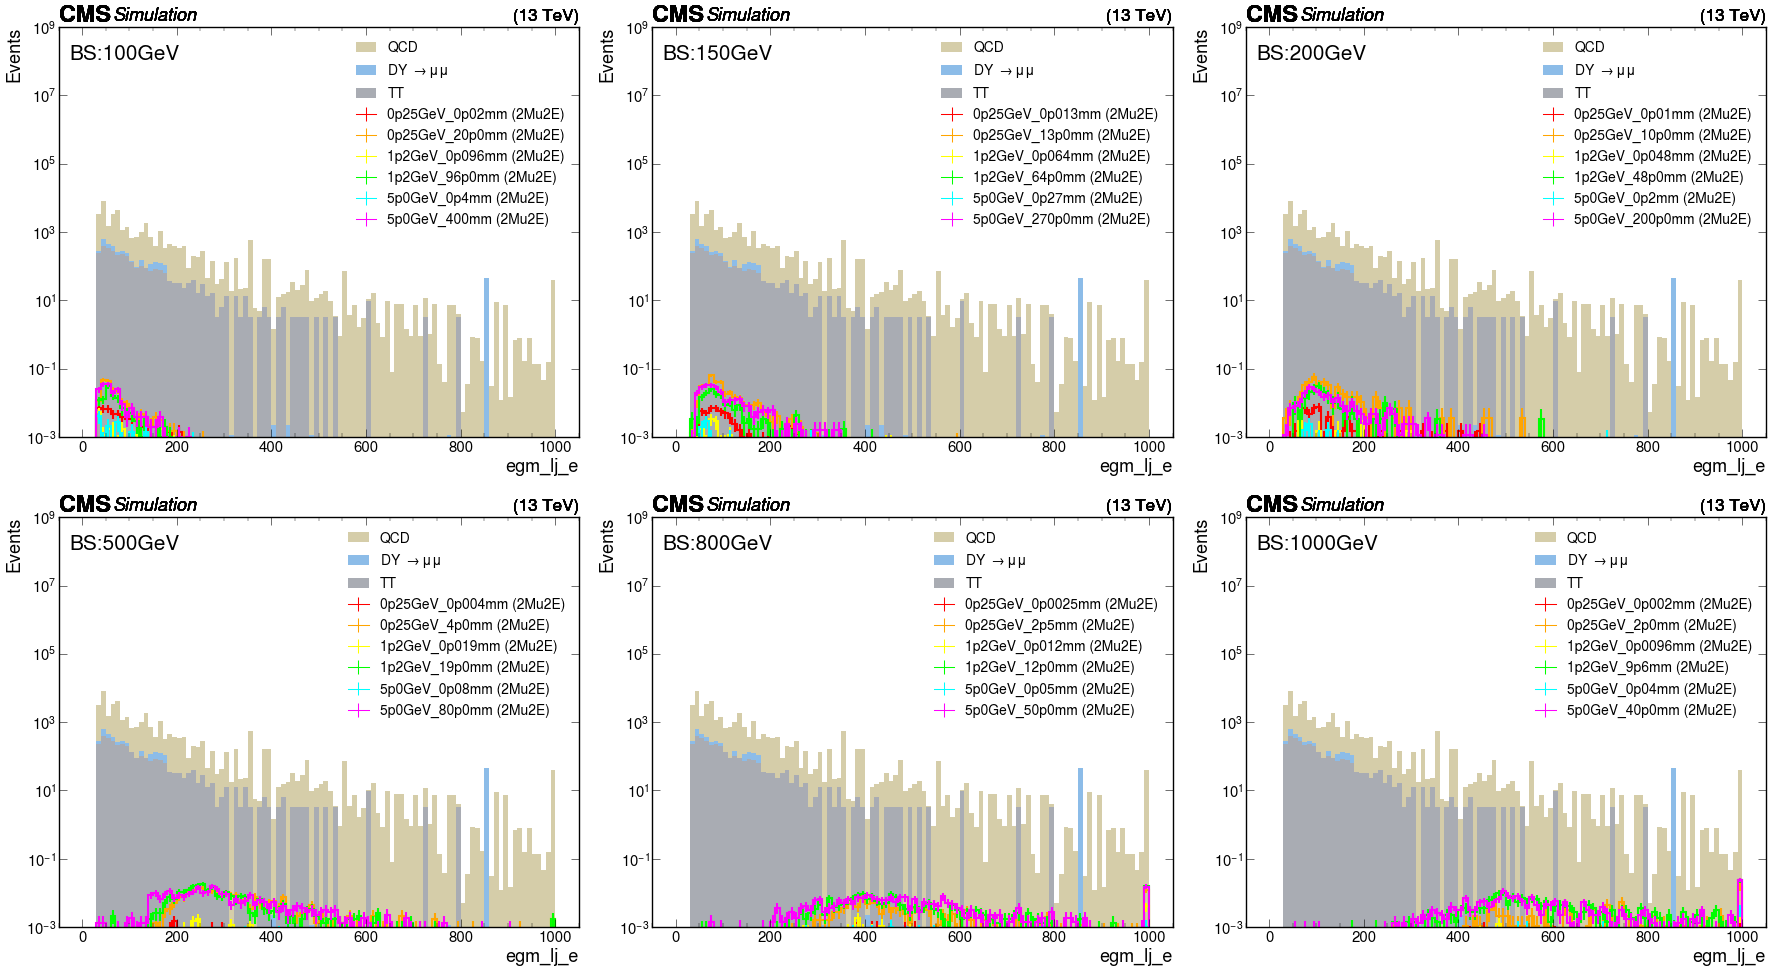

In [26]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_e",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

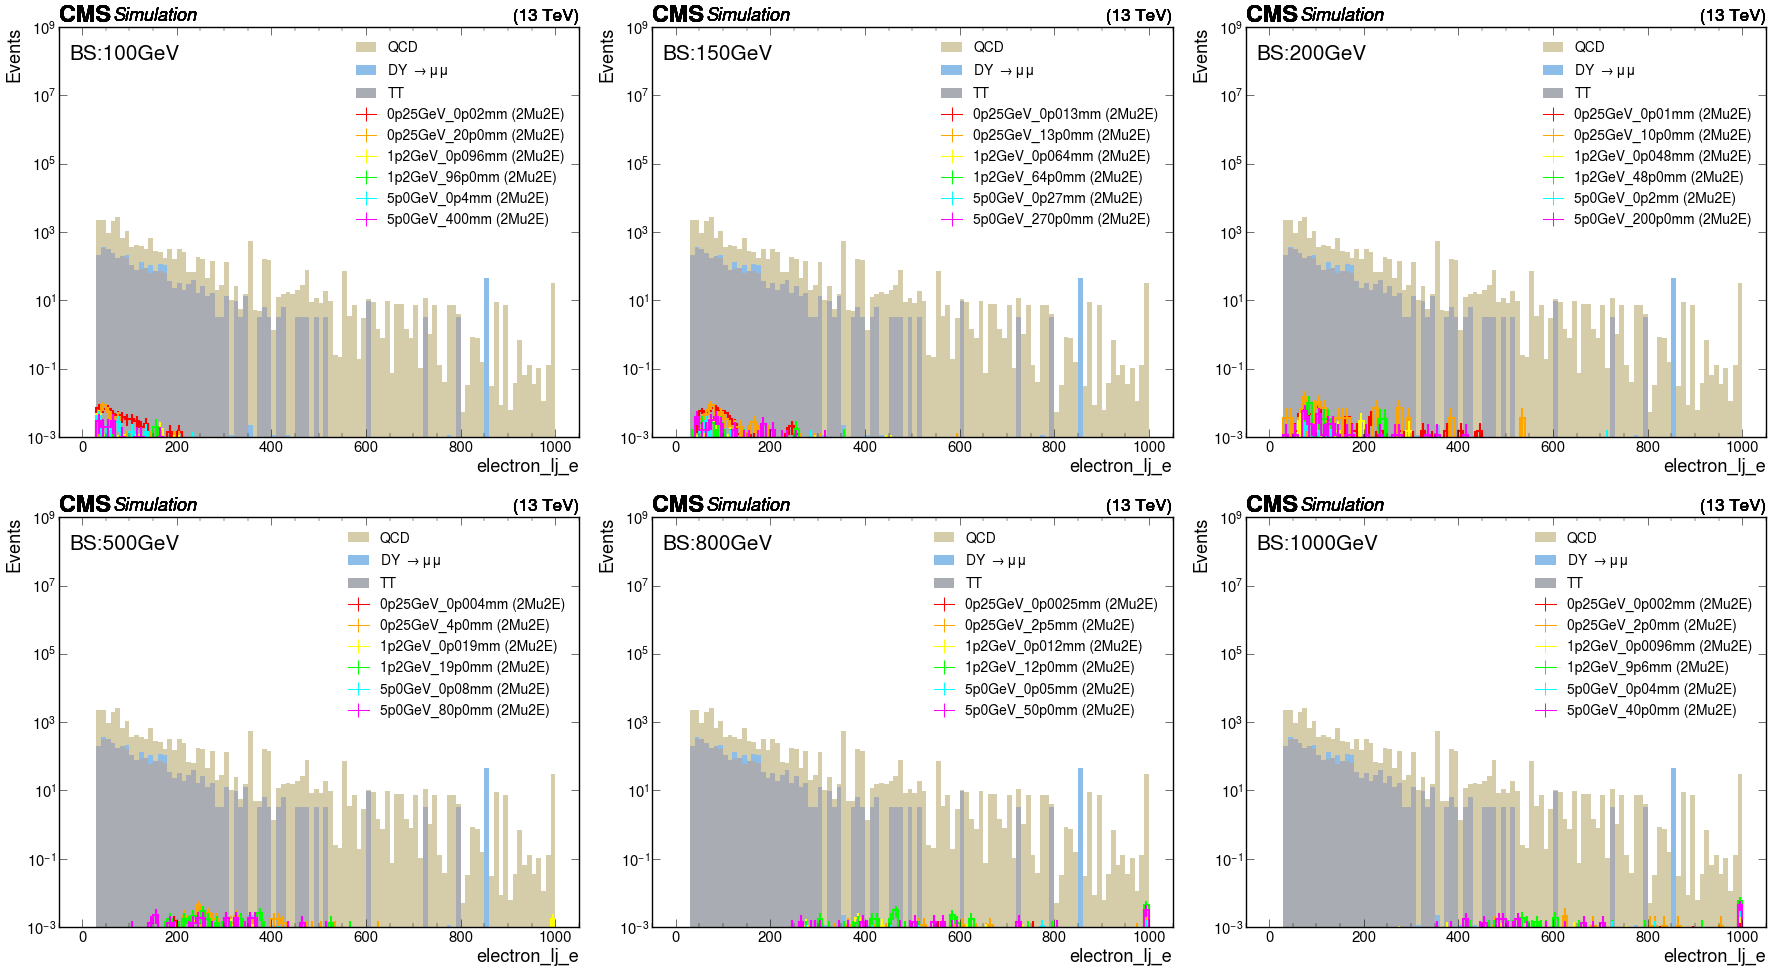

In [27]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_lj_e",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


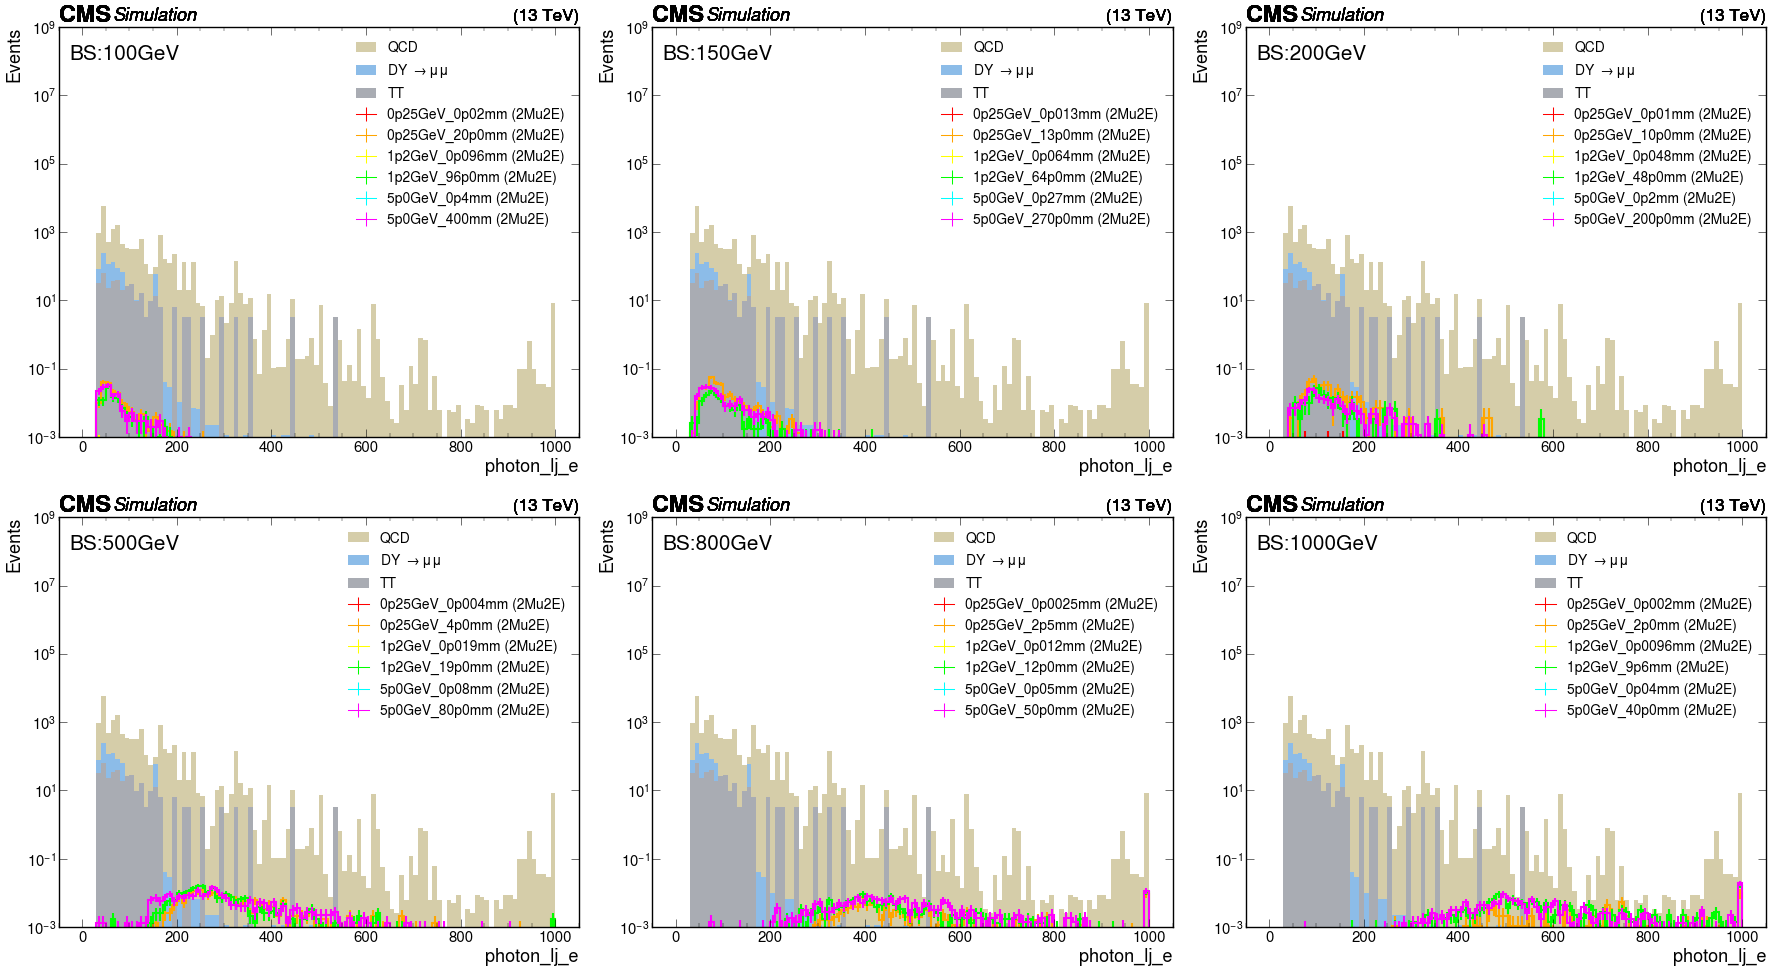

In [28]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_lj_e",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

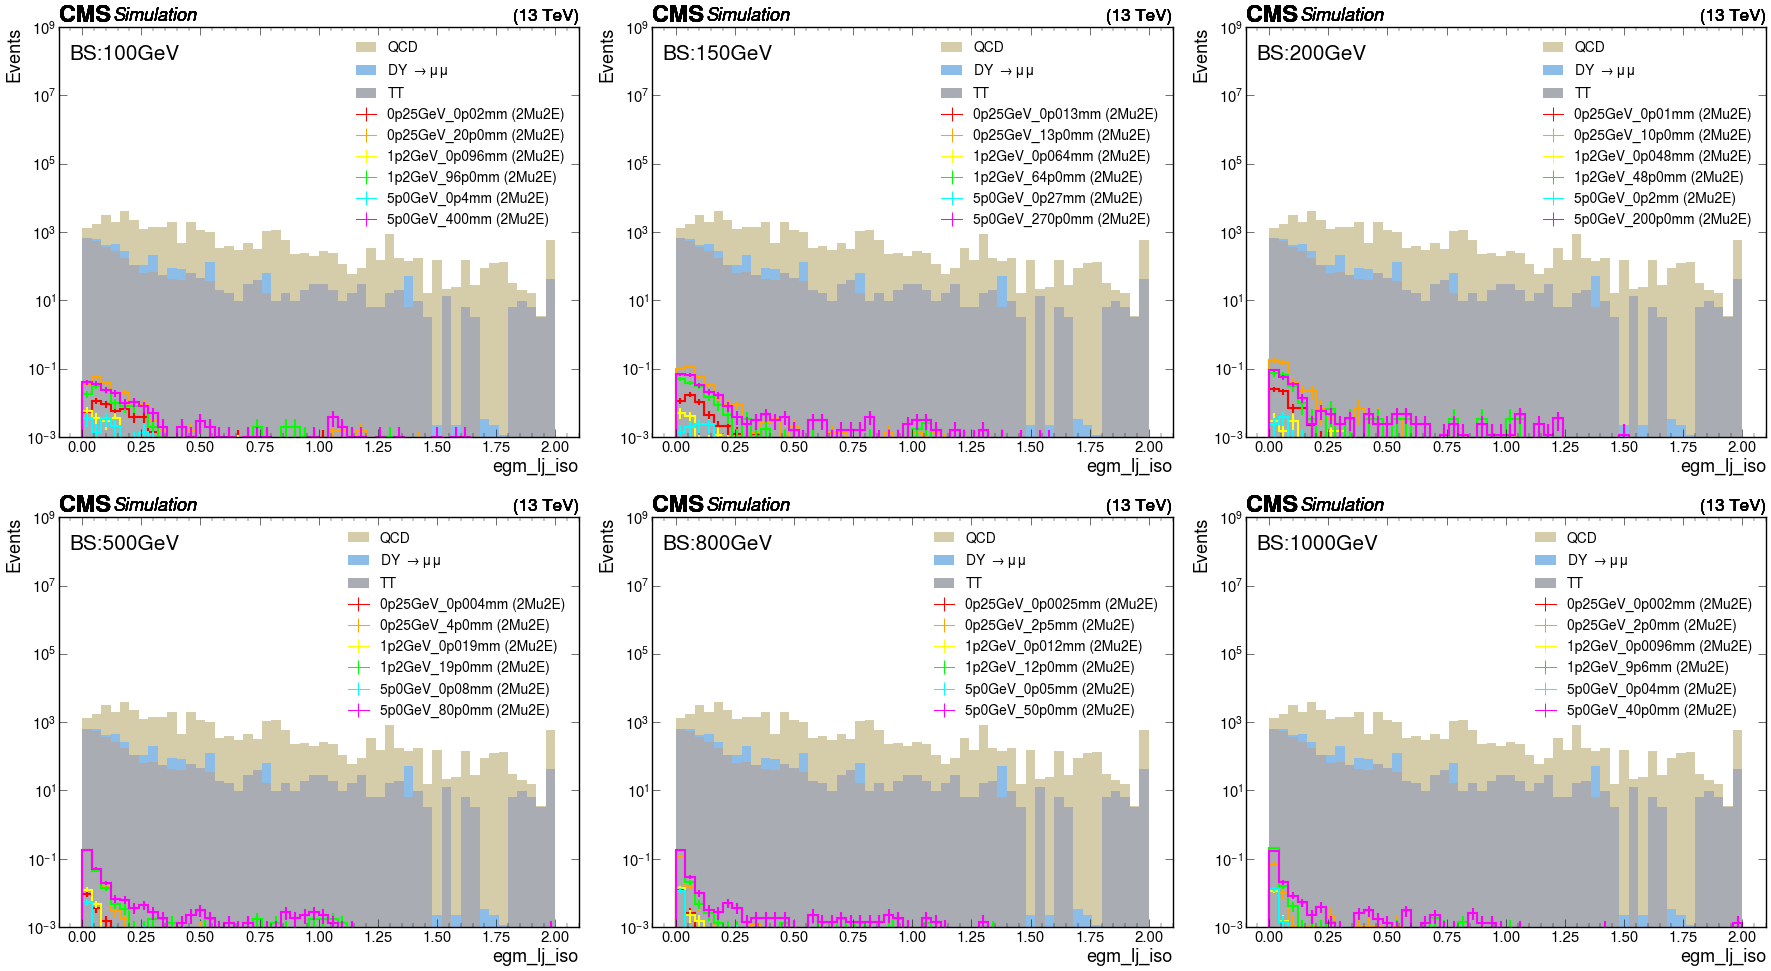

In [34]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_lj_iso",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

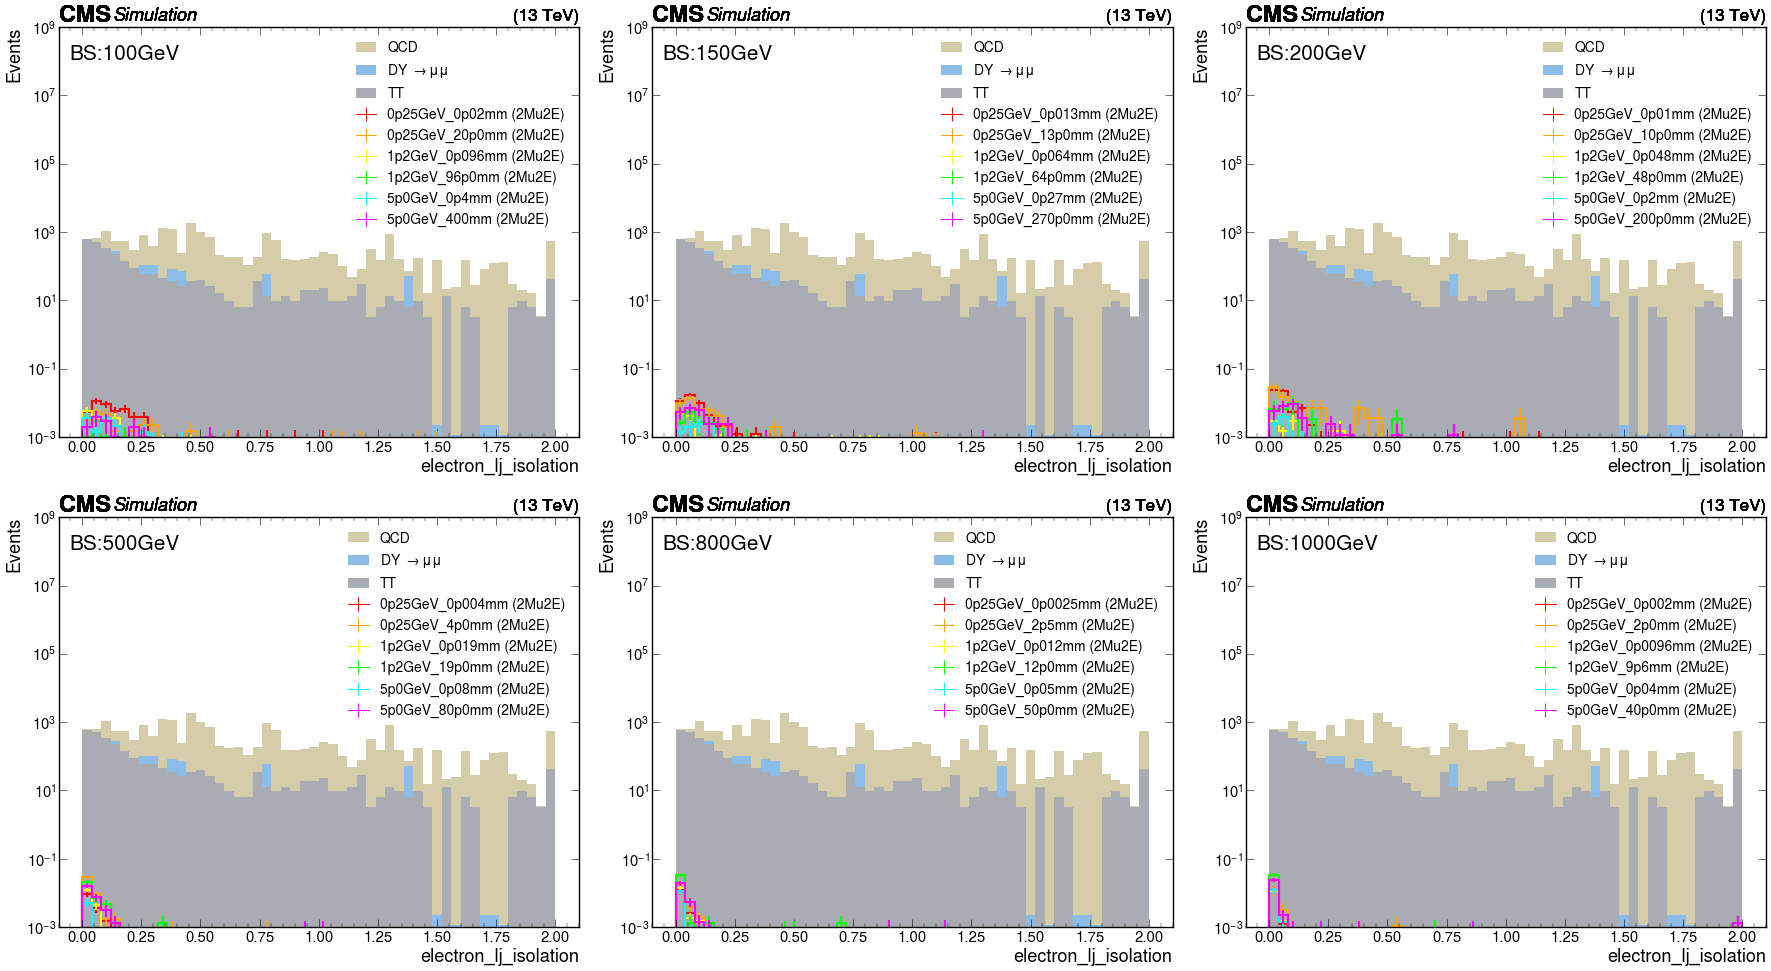

In [35]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_lj_isolation",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


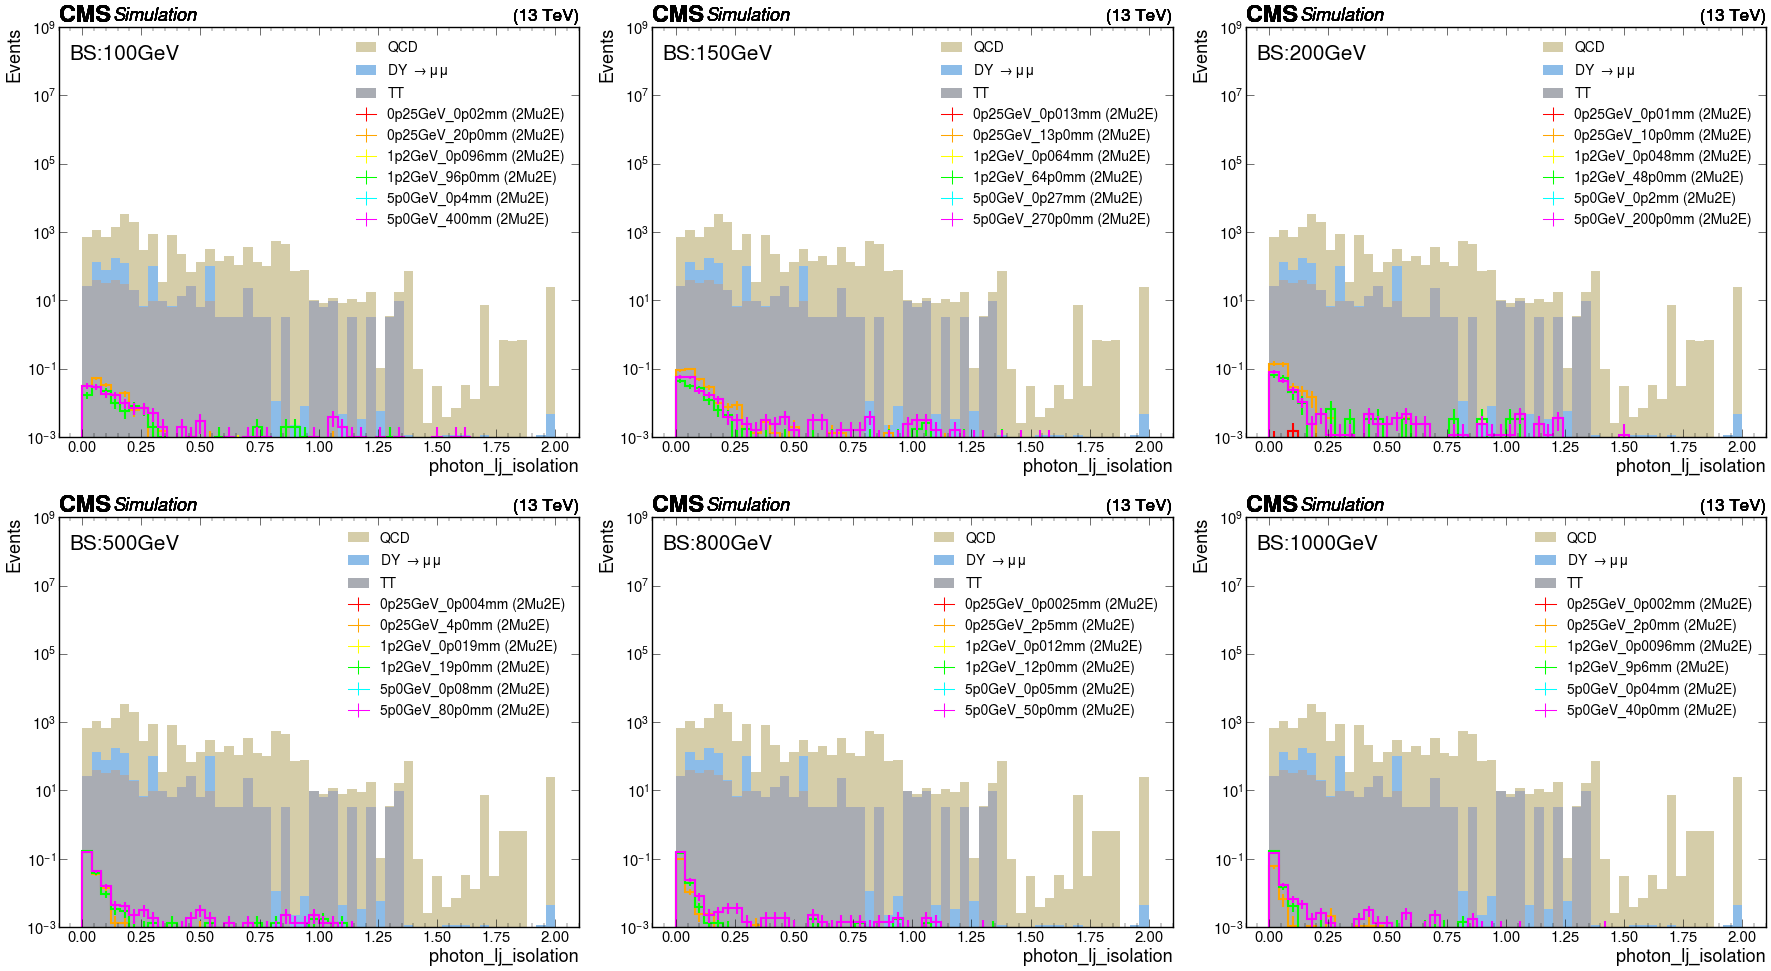

In [36]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_lj_isolation",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

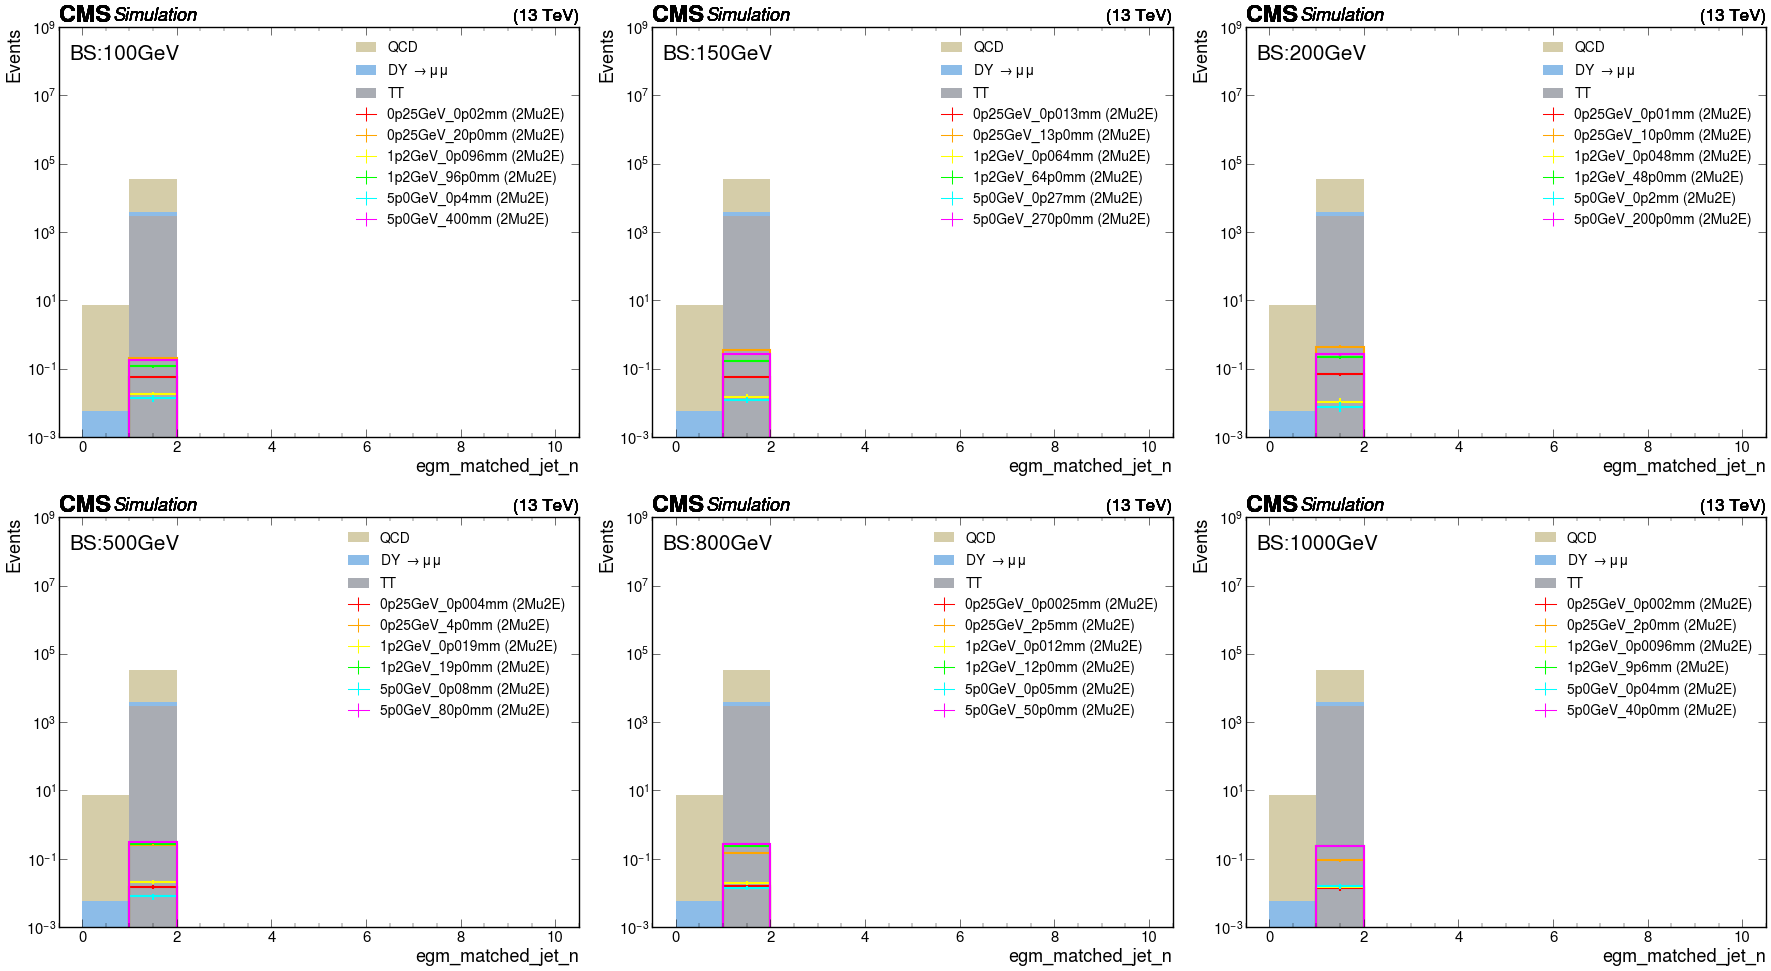

In [37]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_matched_jet_n",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

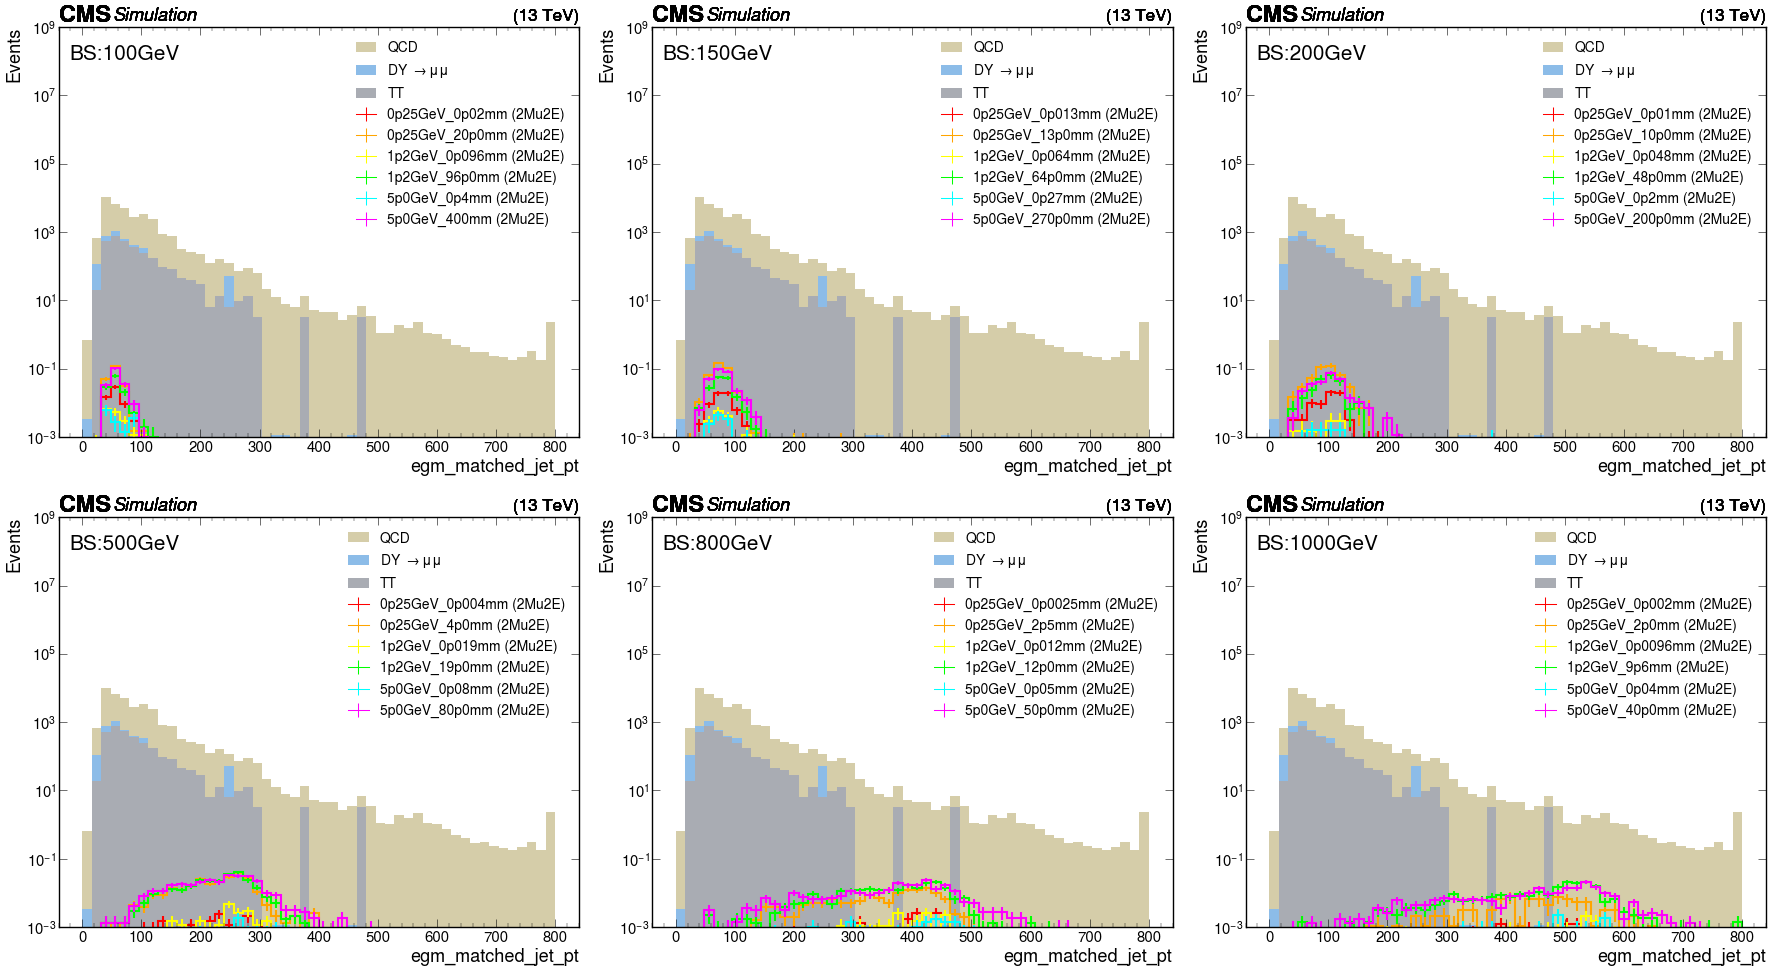

In [38]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_matched_jet_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

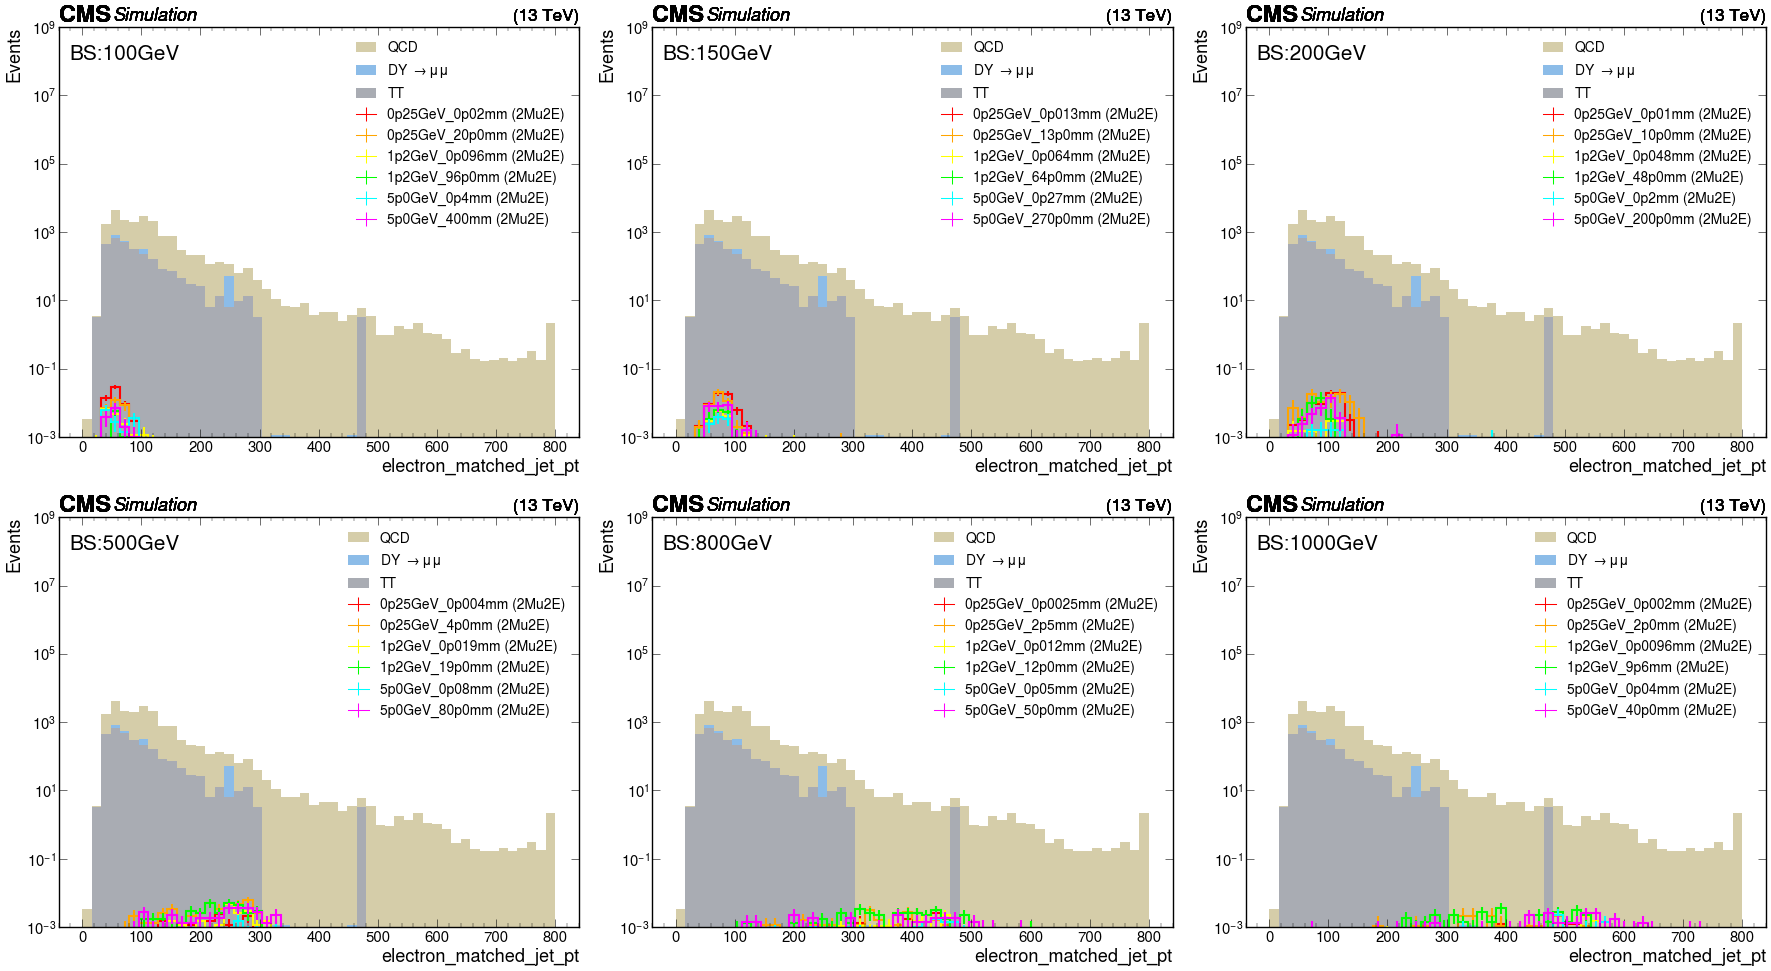

In [39]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_matched_jet_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


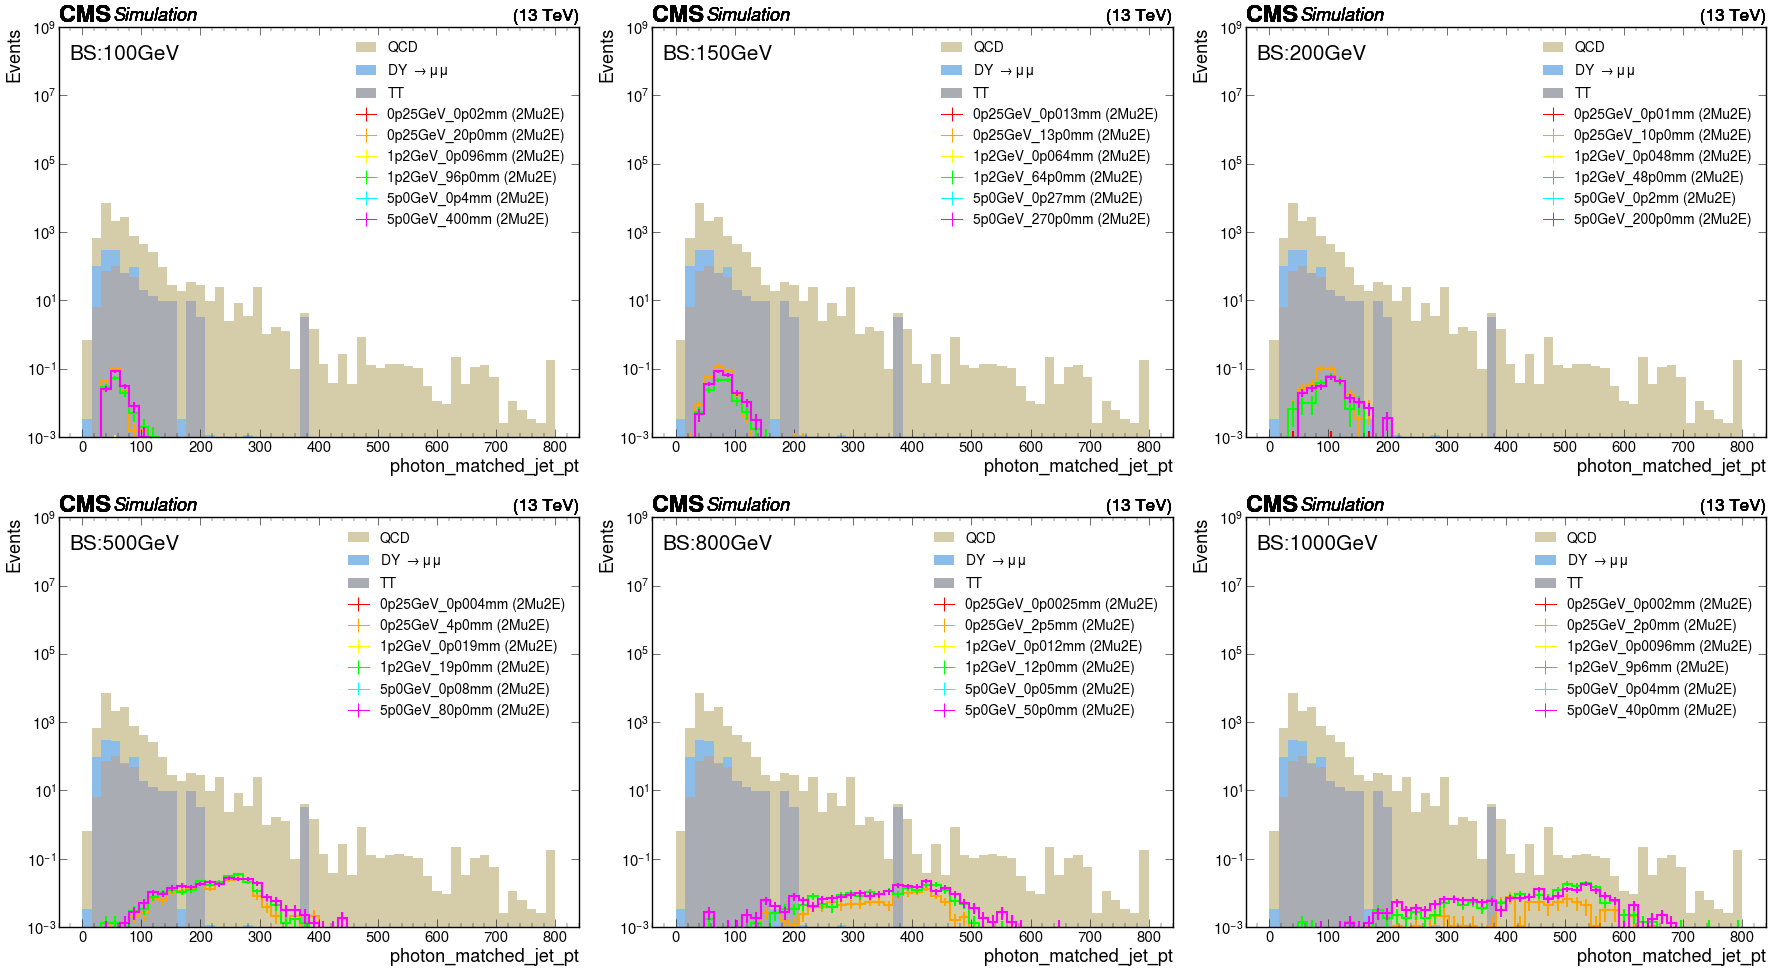

In [40]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_matched_jet_pt",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

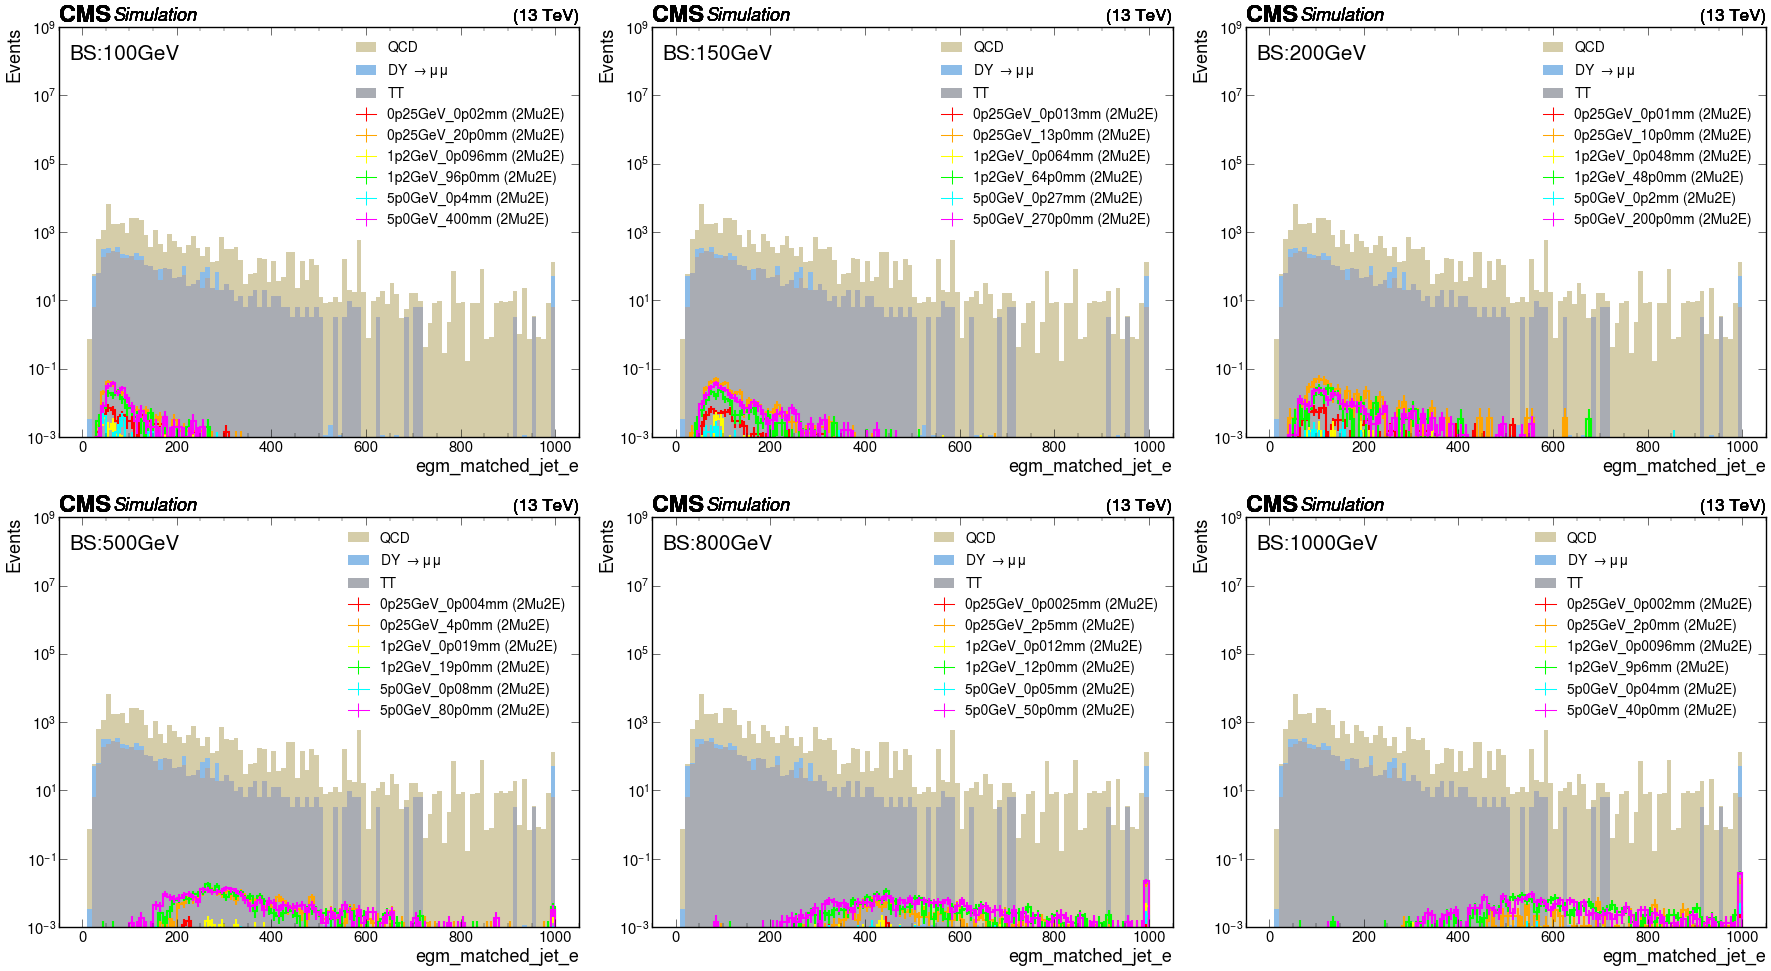

In [41]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_matched_jet_e",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

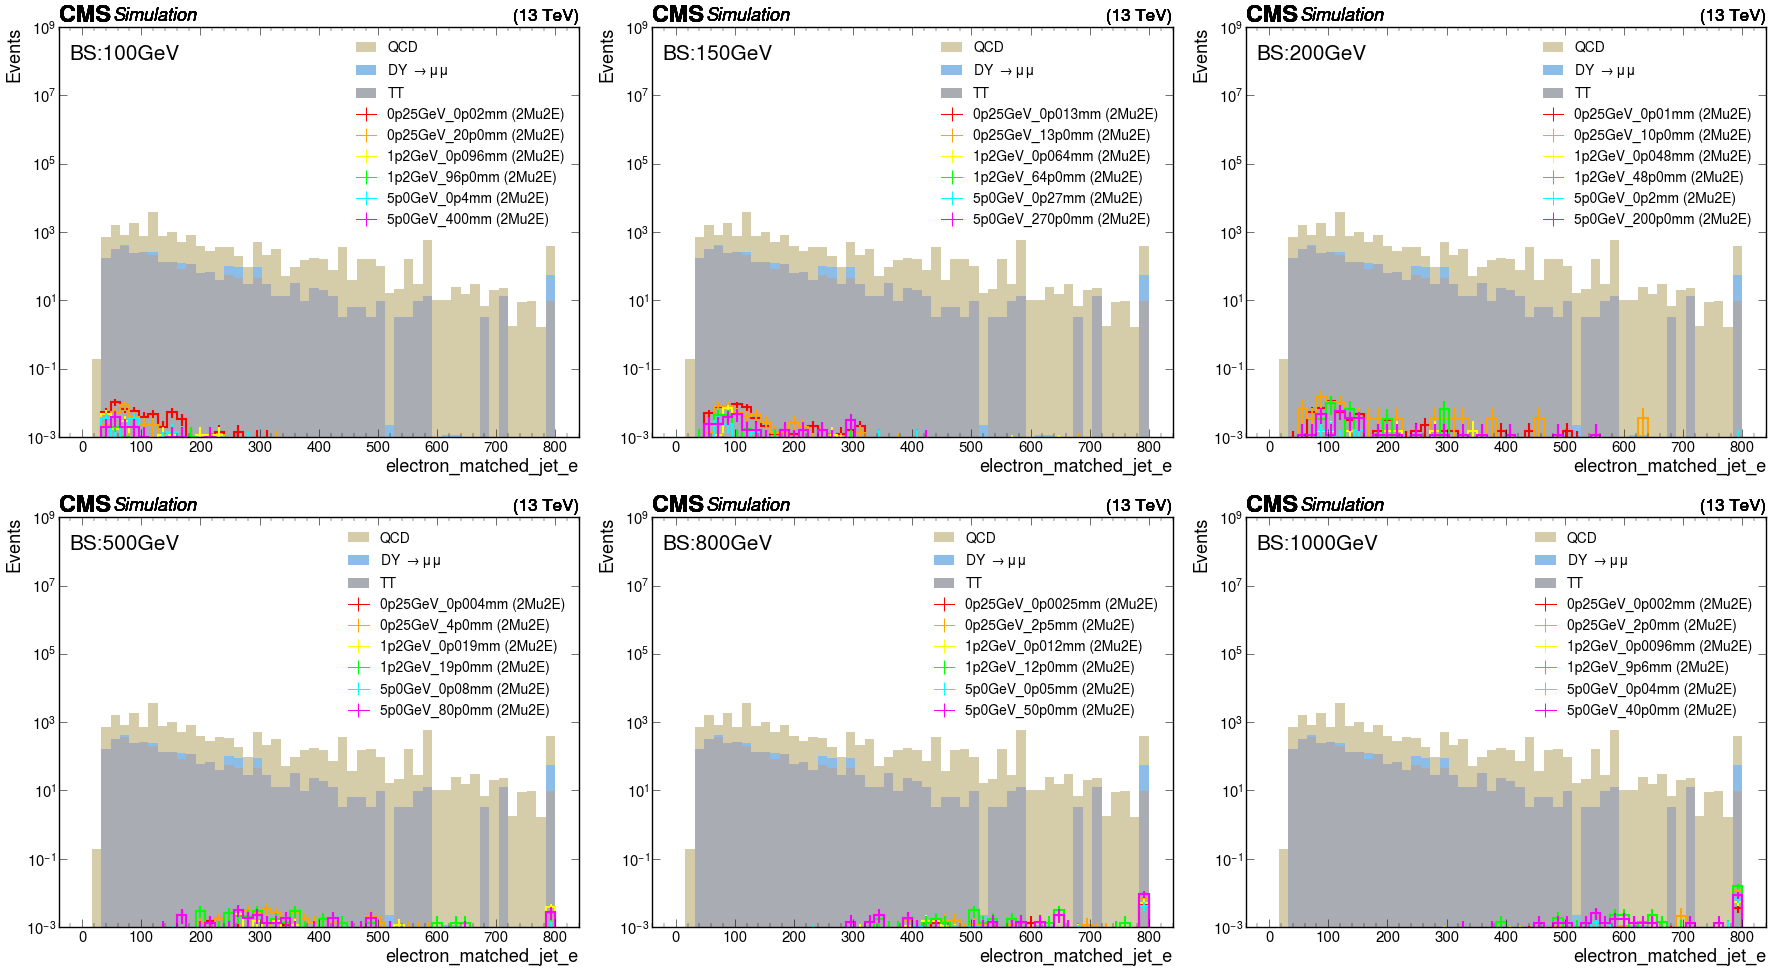

In [42]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_matched_jet_e",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


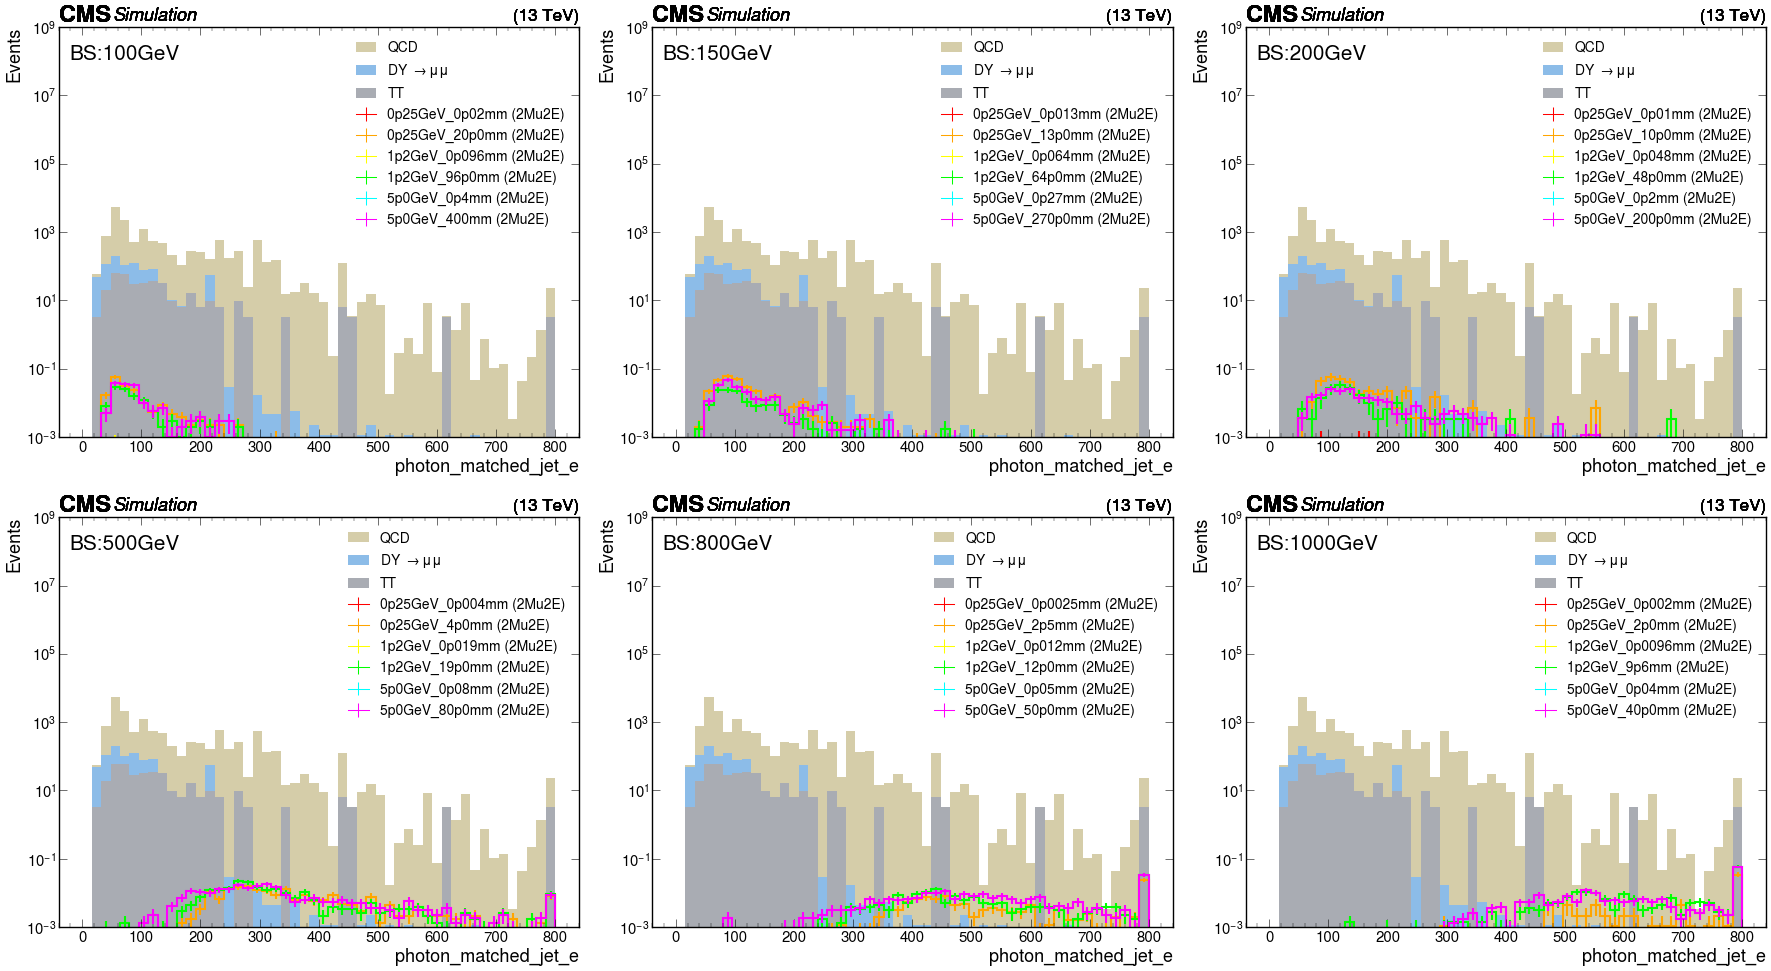

In [43]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_matched_jet_e",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

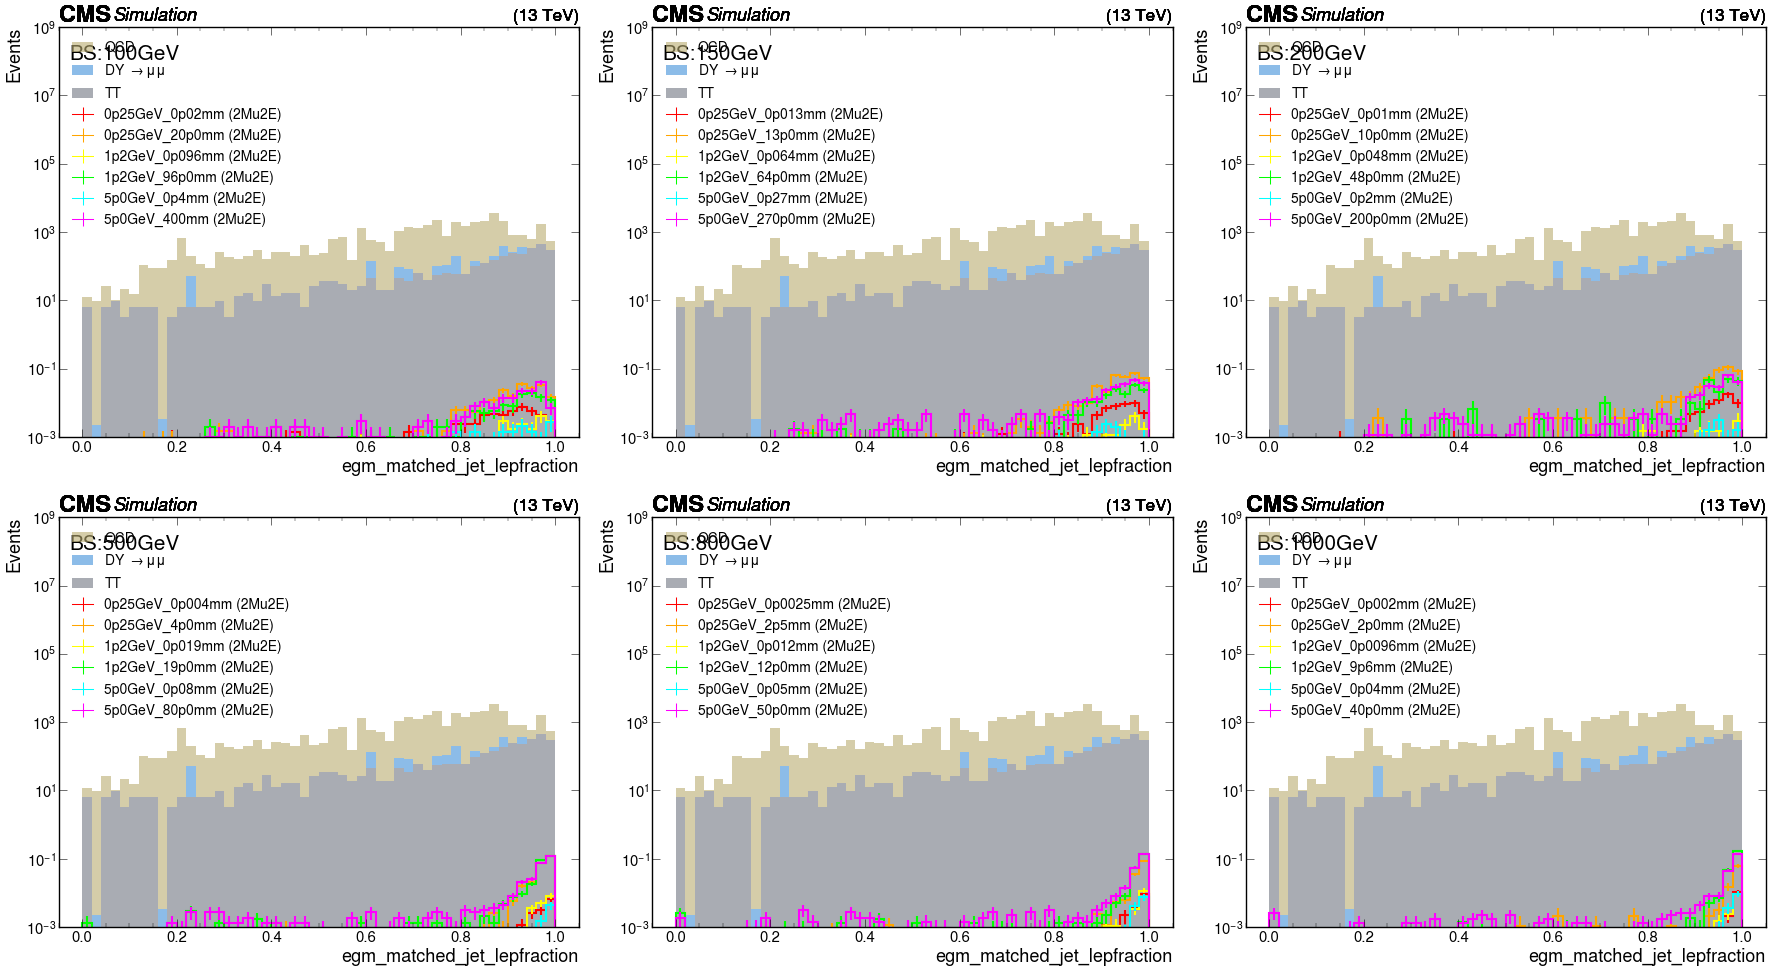

In [44]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_matched_jet_lepfraction",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

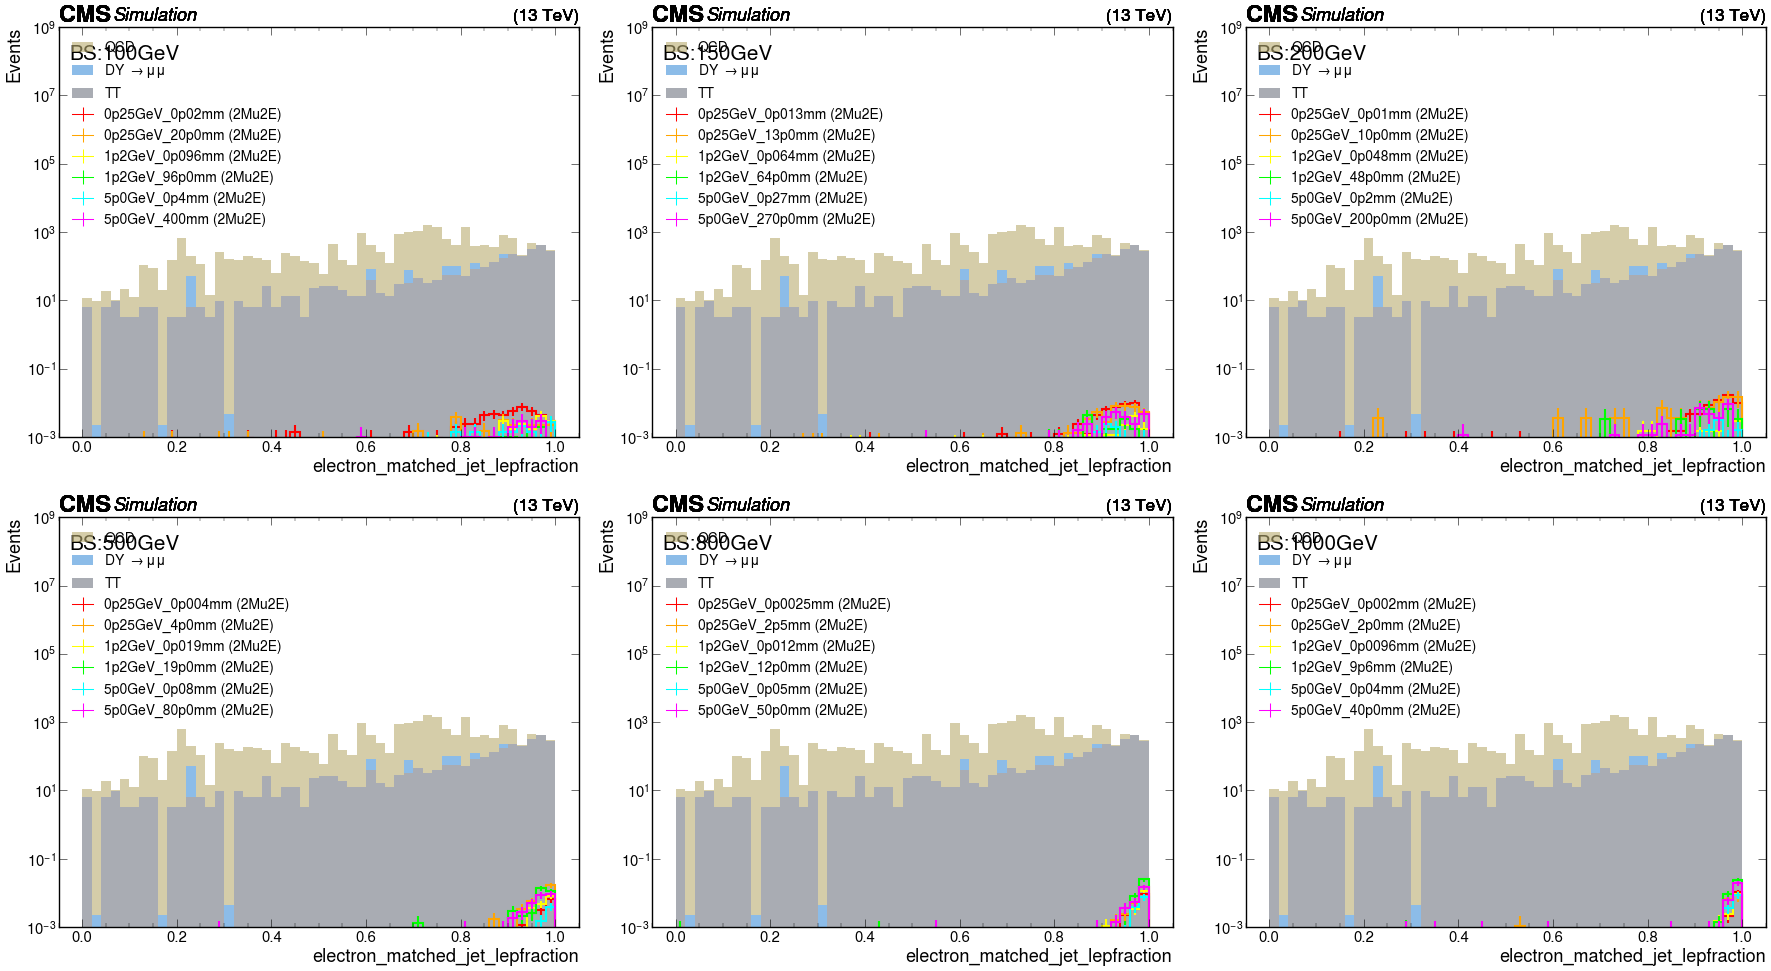

In [45]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_matched_jet_lepfraction",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


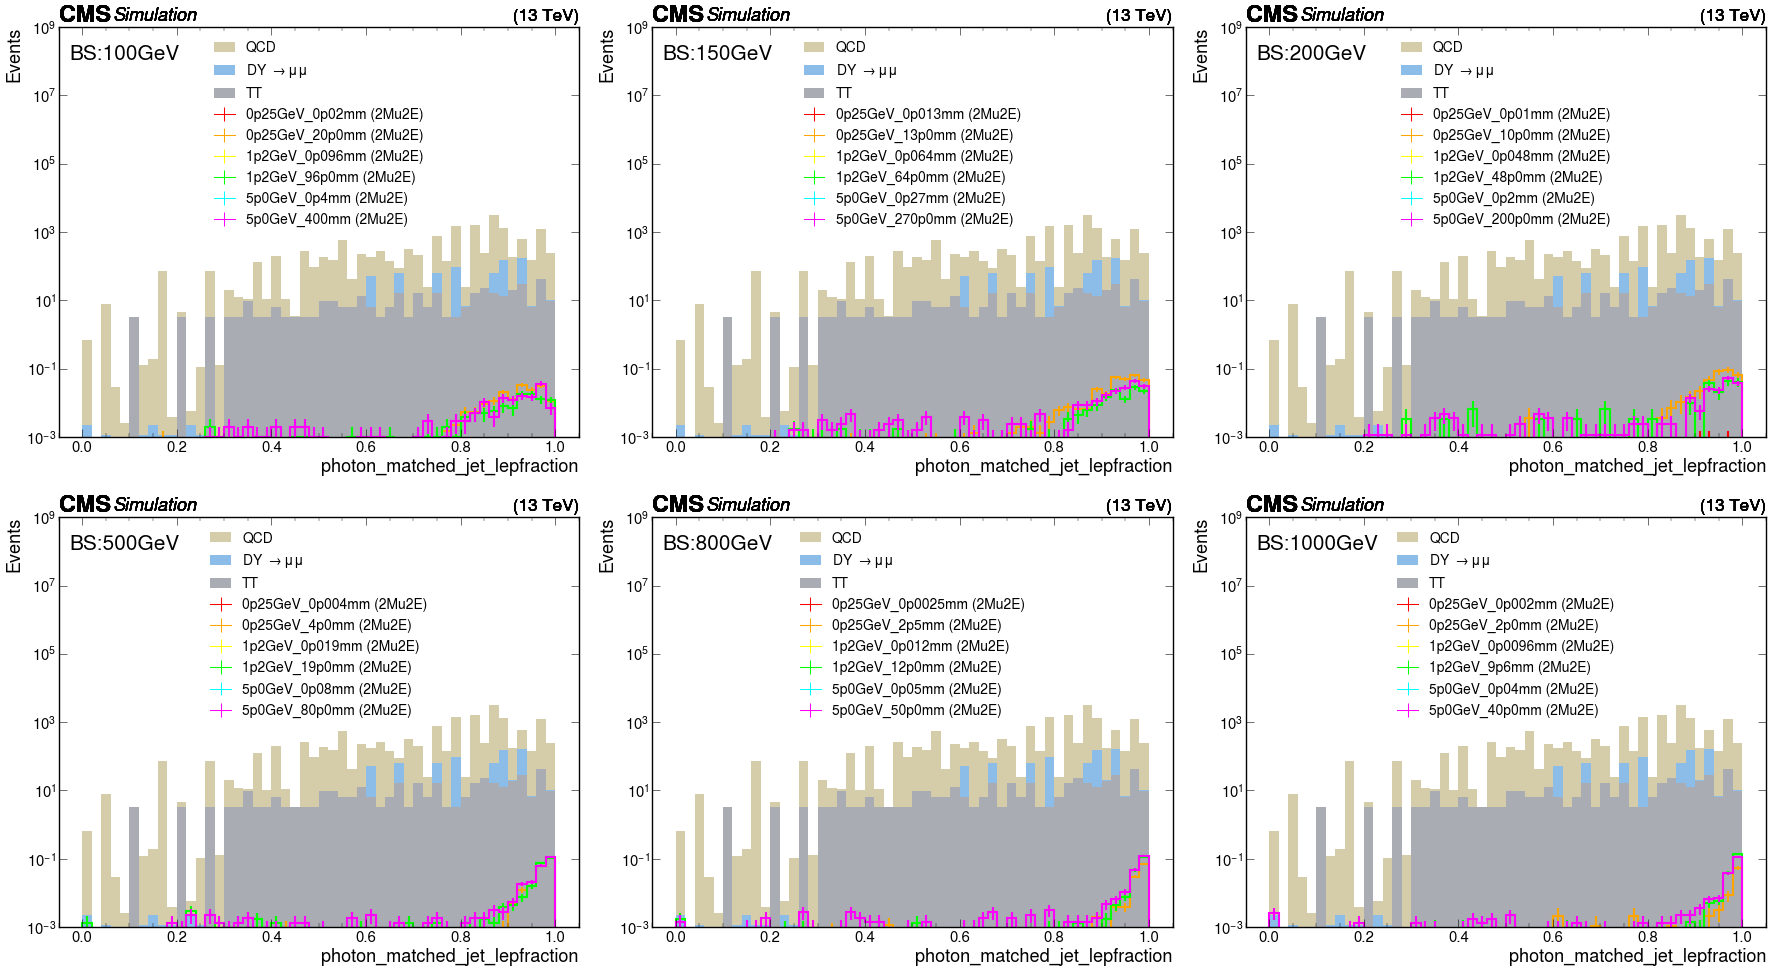

In [46]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_matched_jet_lepfraction",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

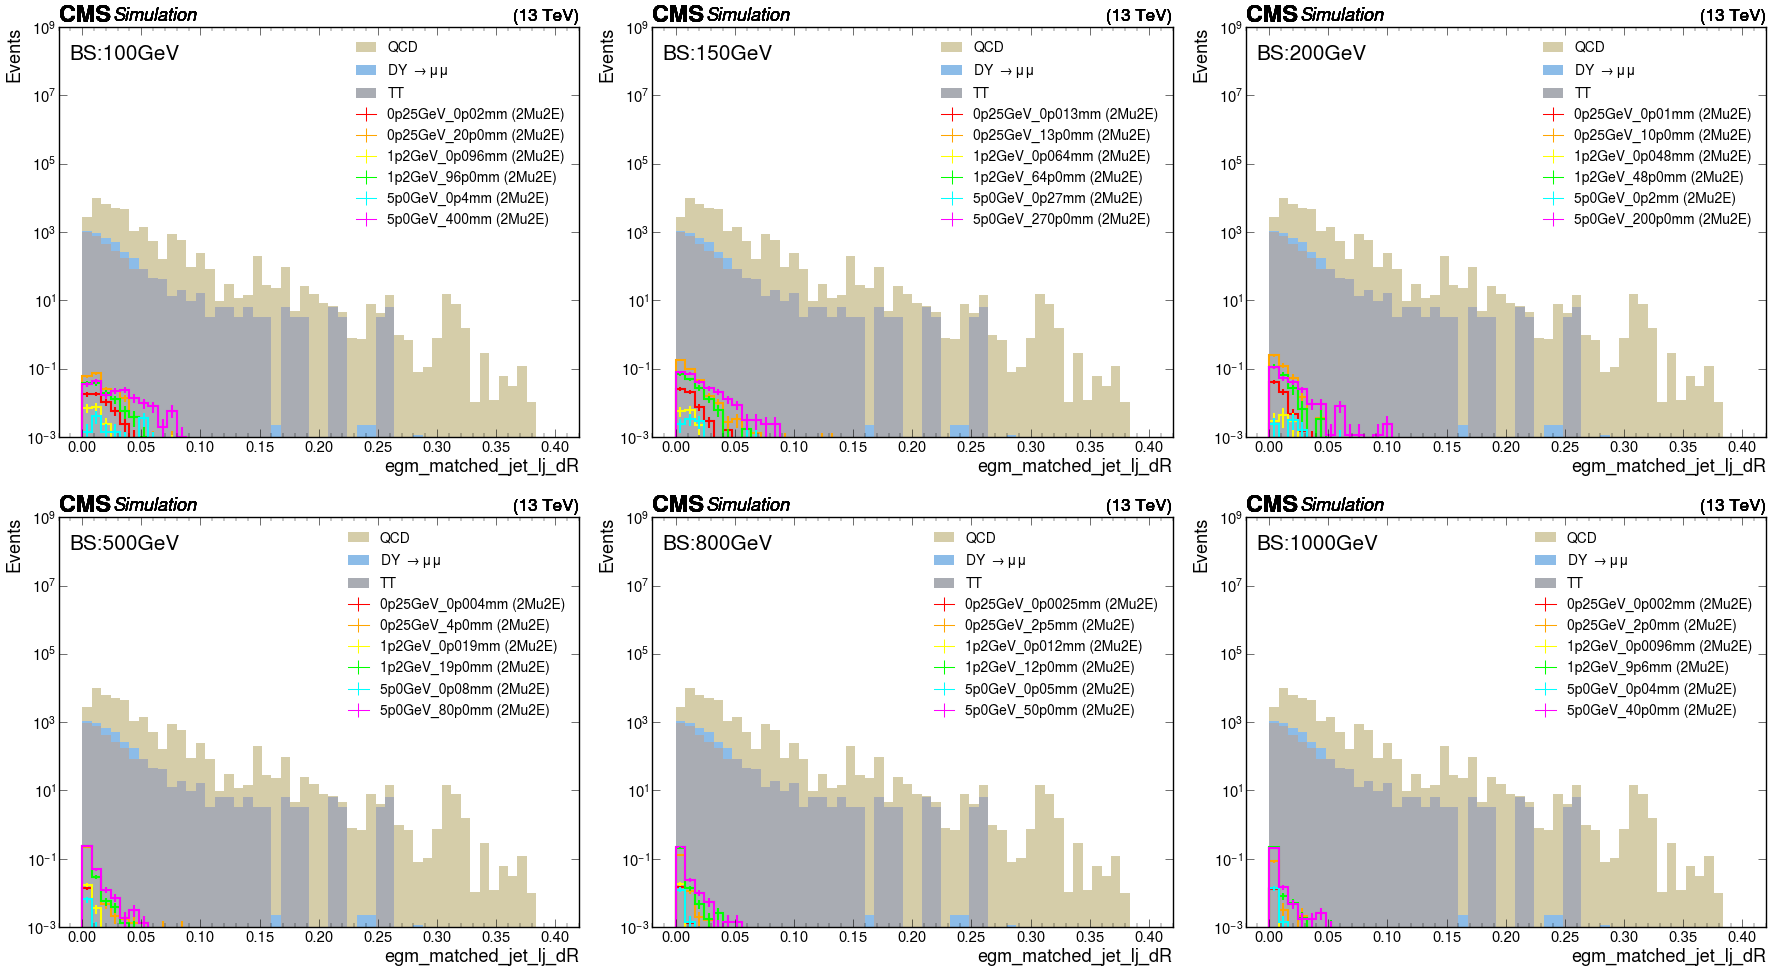

In [47]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_matched_jet_lj_dR",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

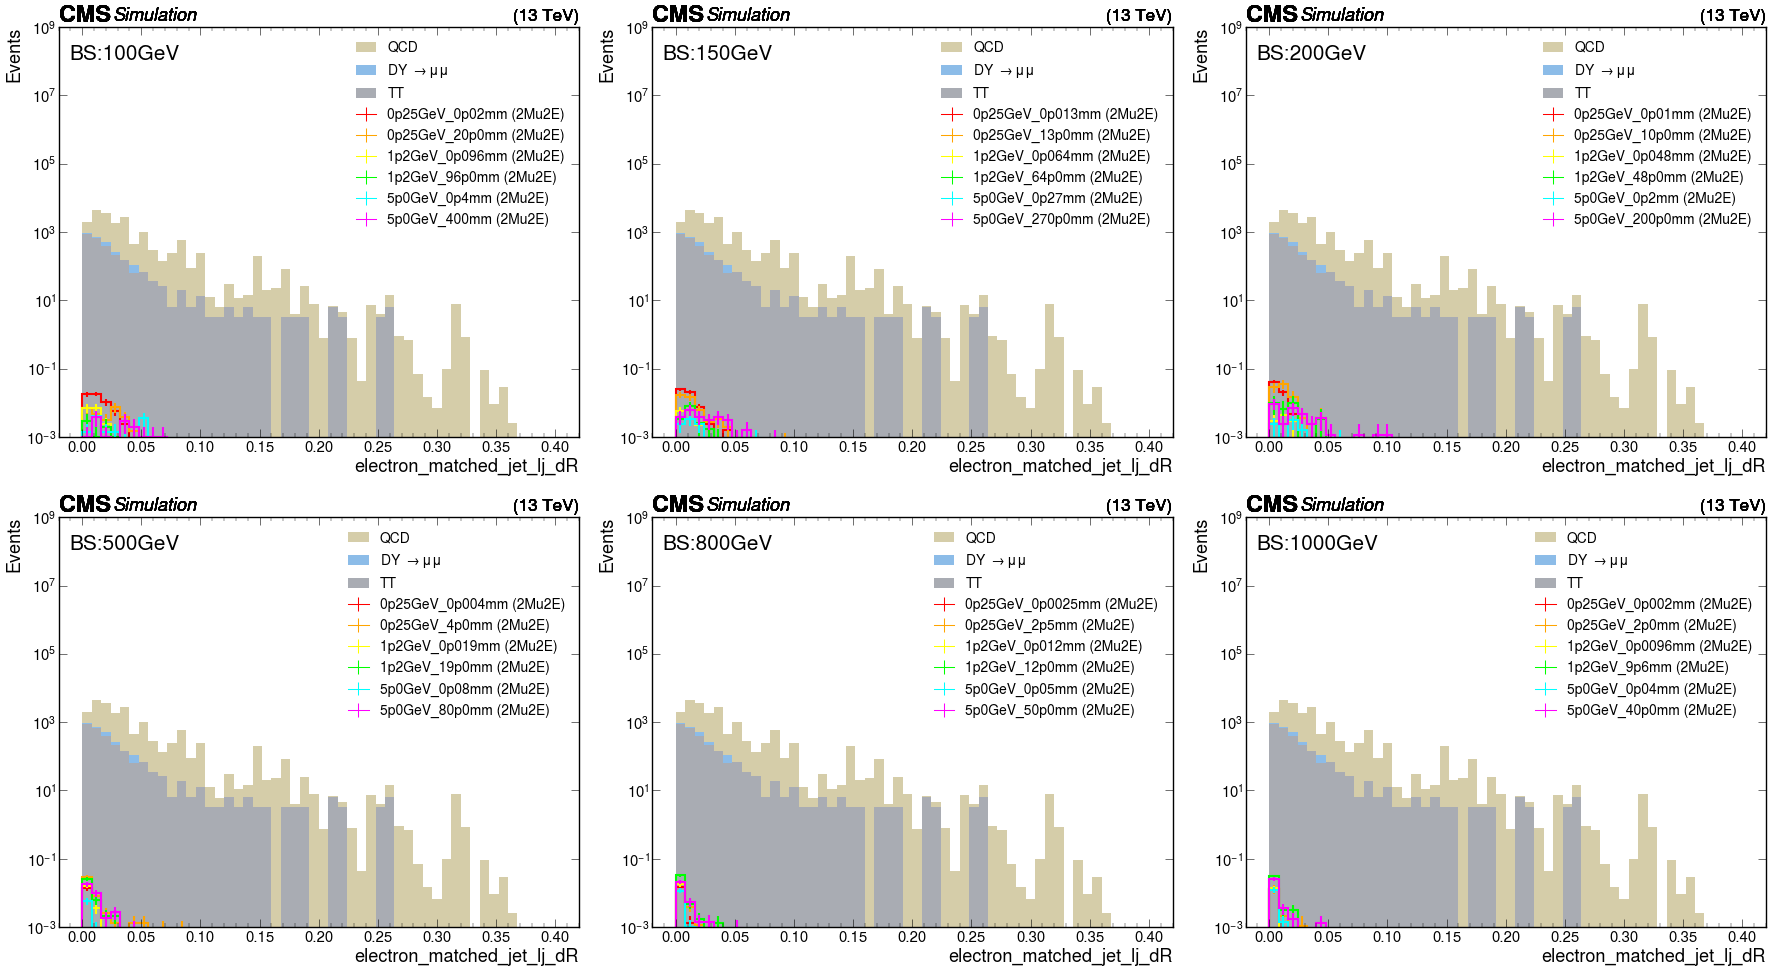

In [48]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_matched_jet_lj_dR",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


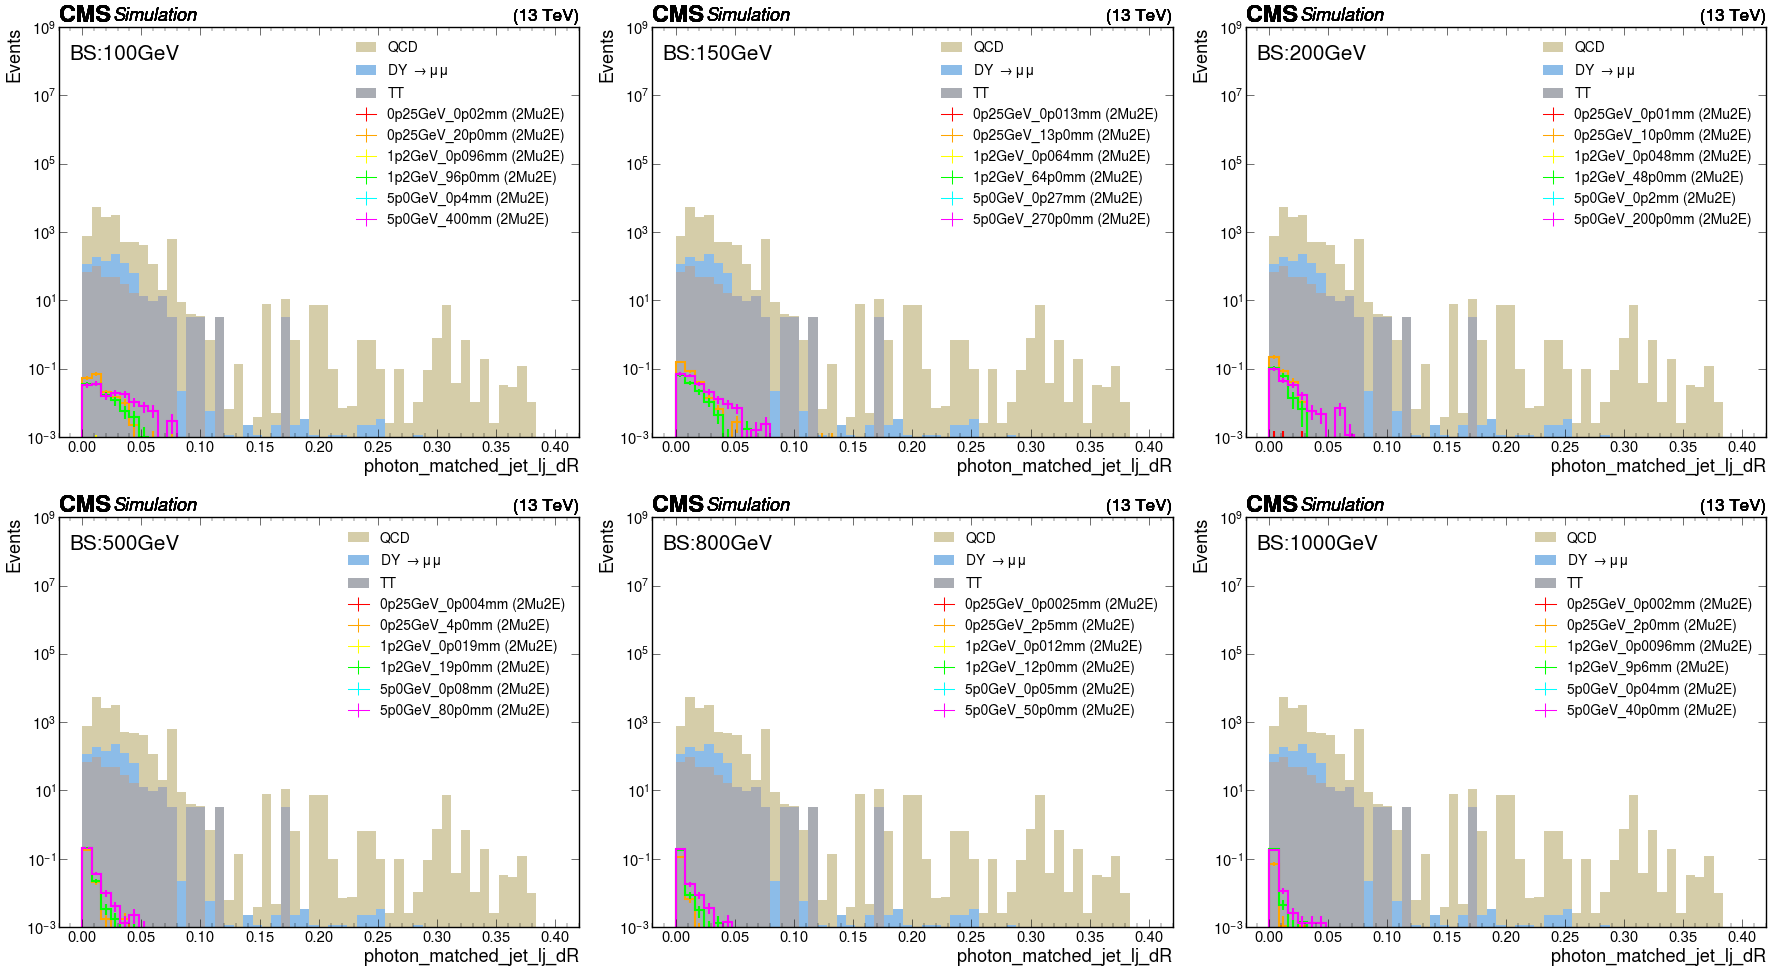

In [49]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_matched_jet_lj_dR",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

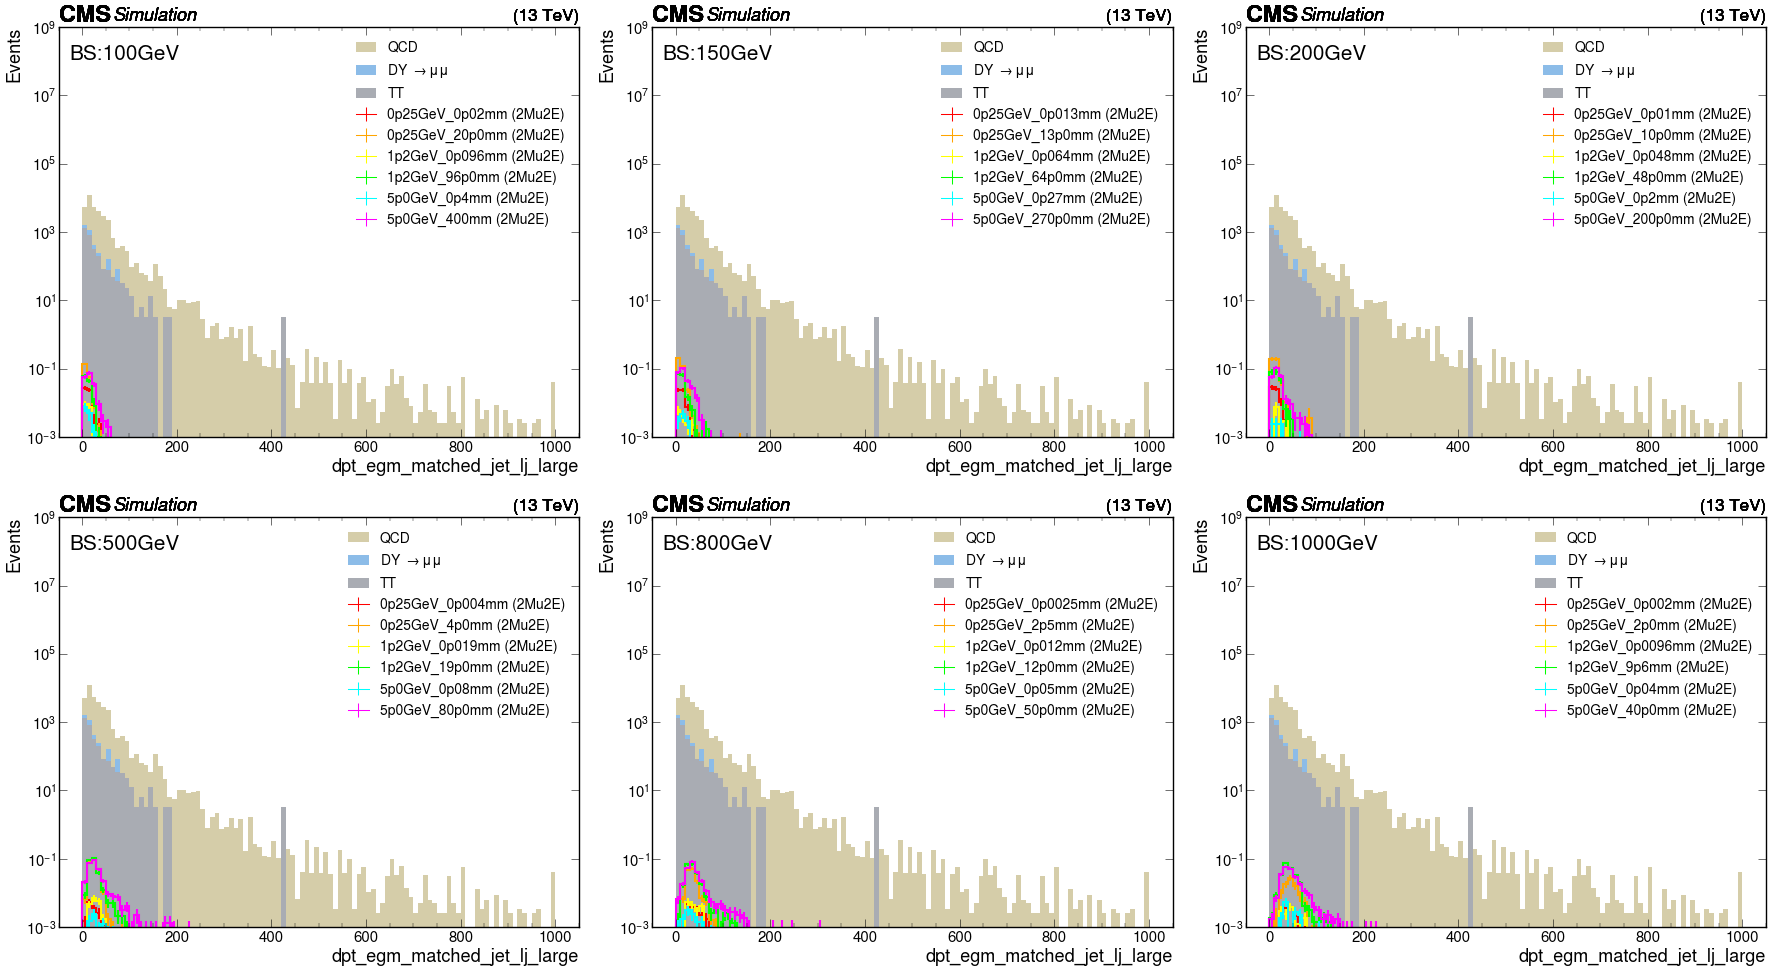

In [50]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="dpt_egm_matched_jet_lj_large",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

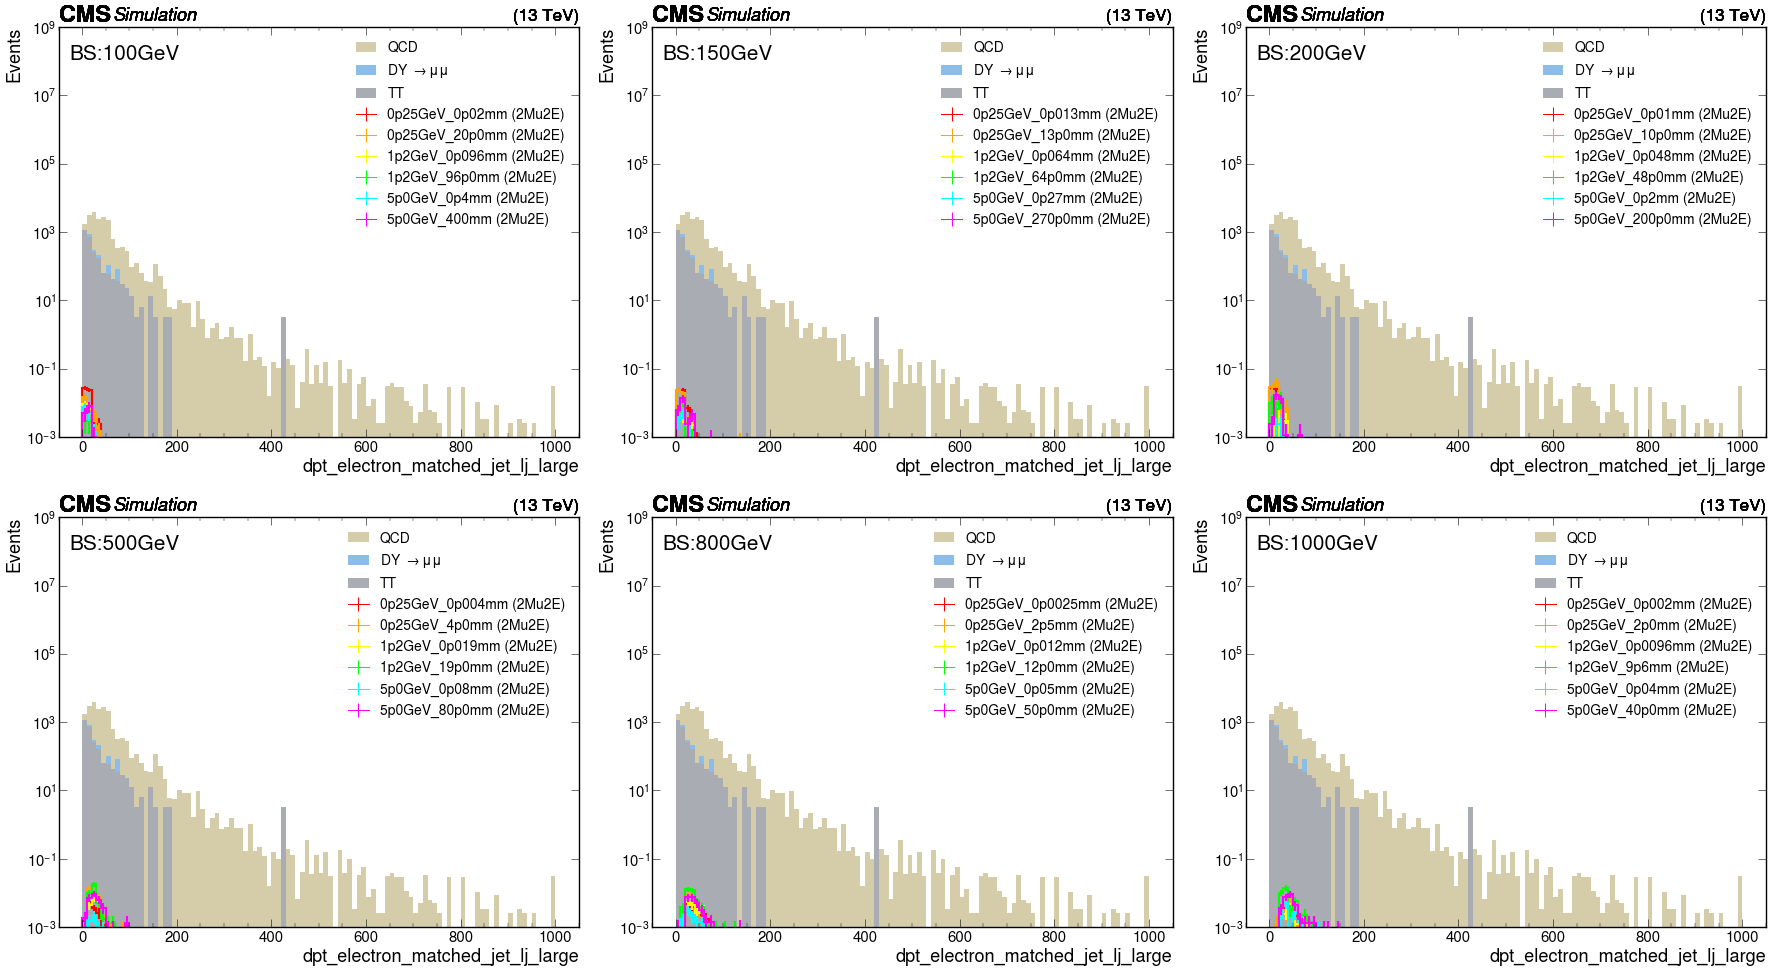

In [51]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="dpt_electron_matched_jet_lj_large",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


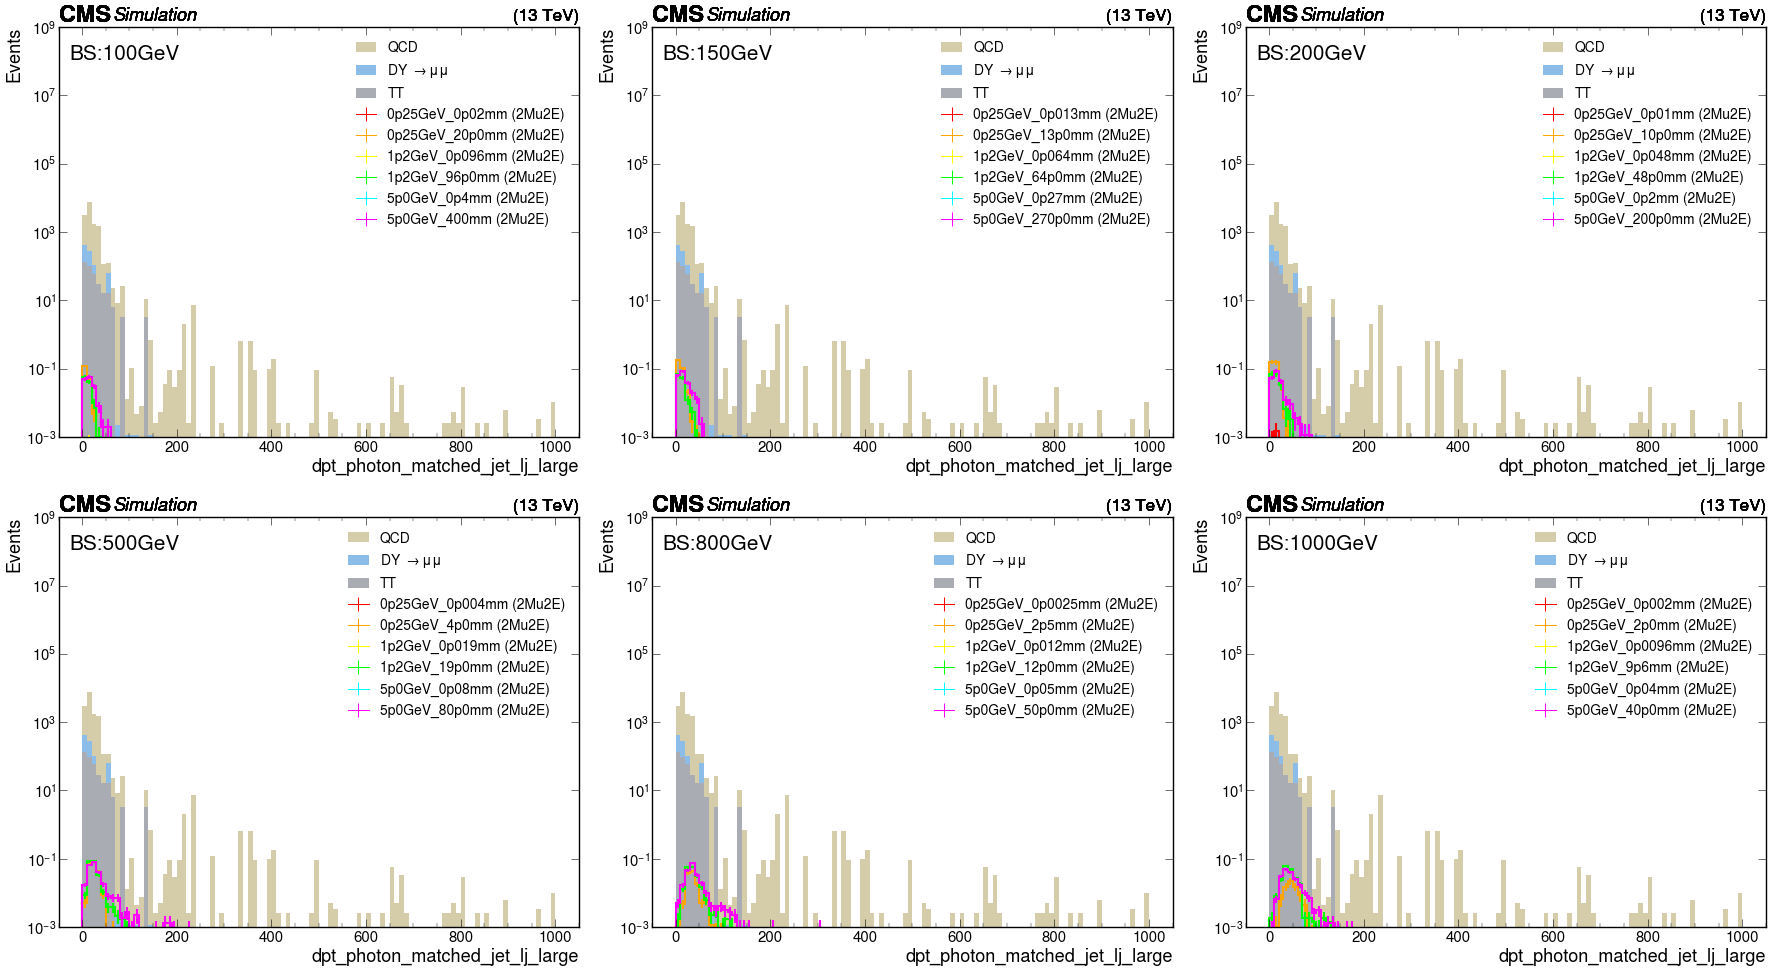

In [52]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="dpt_photon_matched_jet_lj_large",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

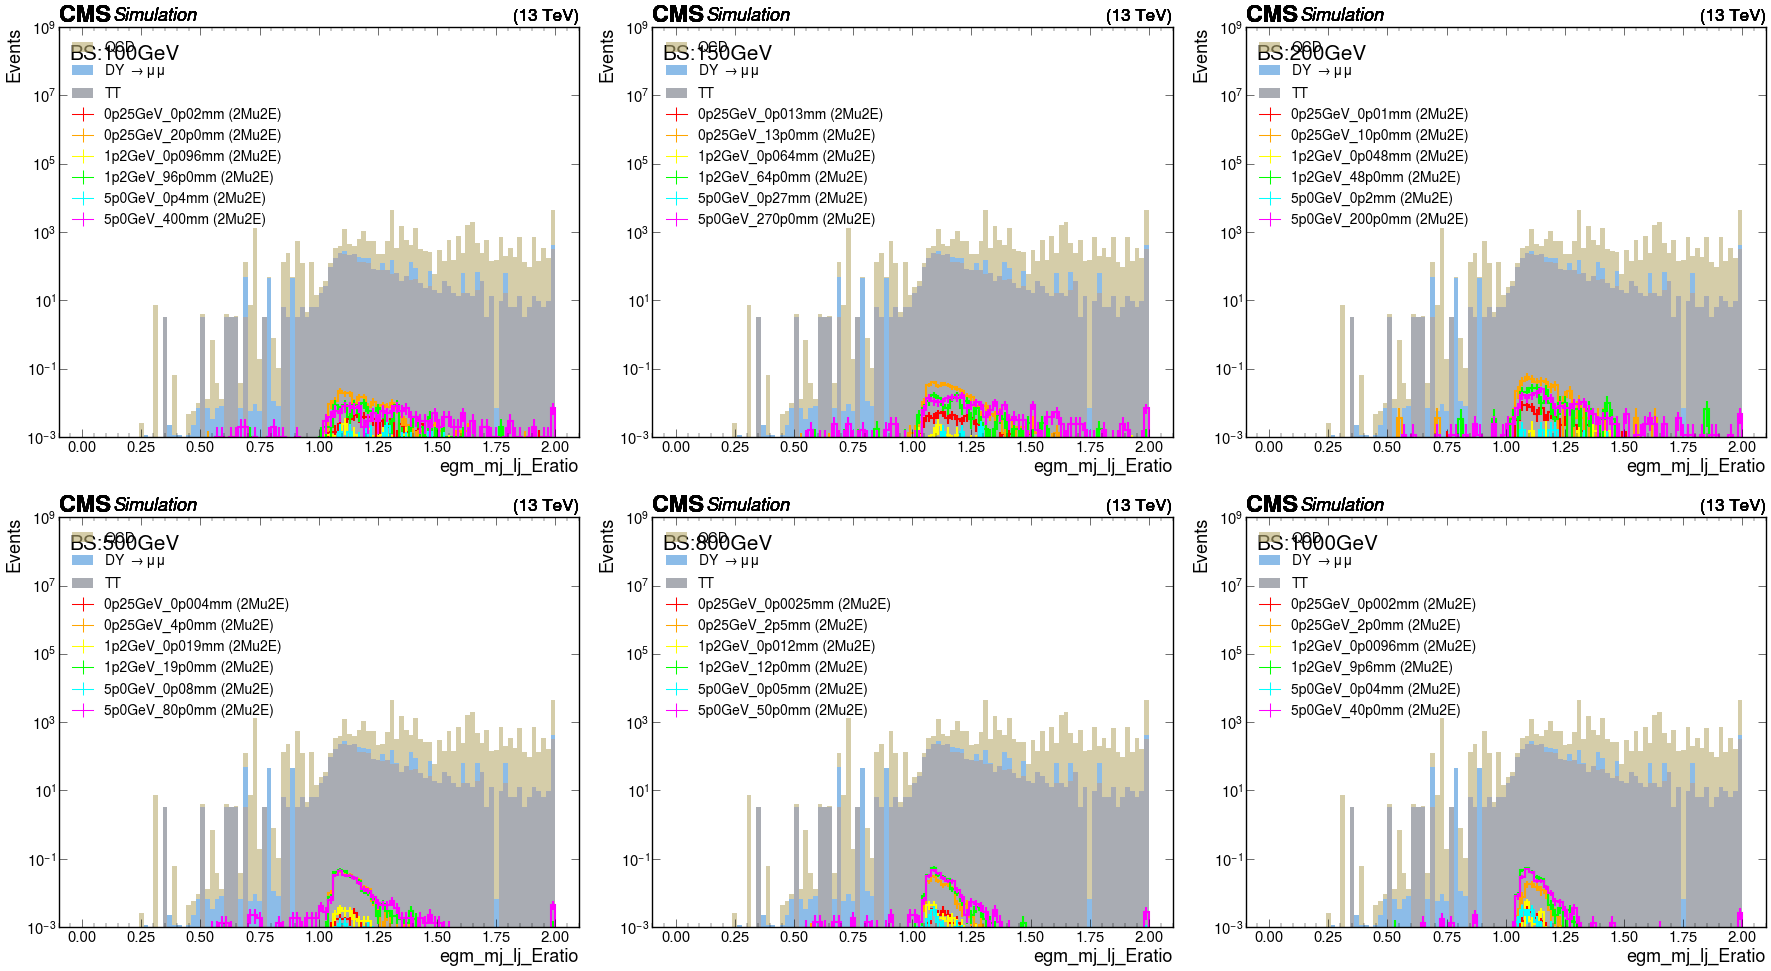

In [53]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="egm_mj_lj_Eratio",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

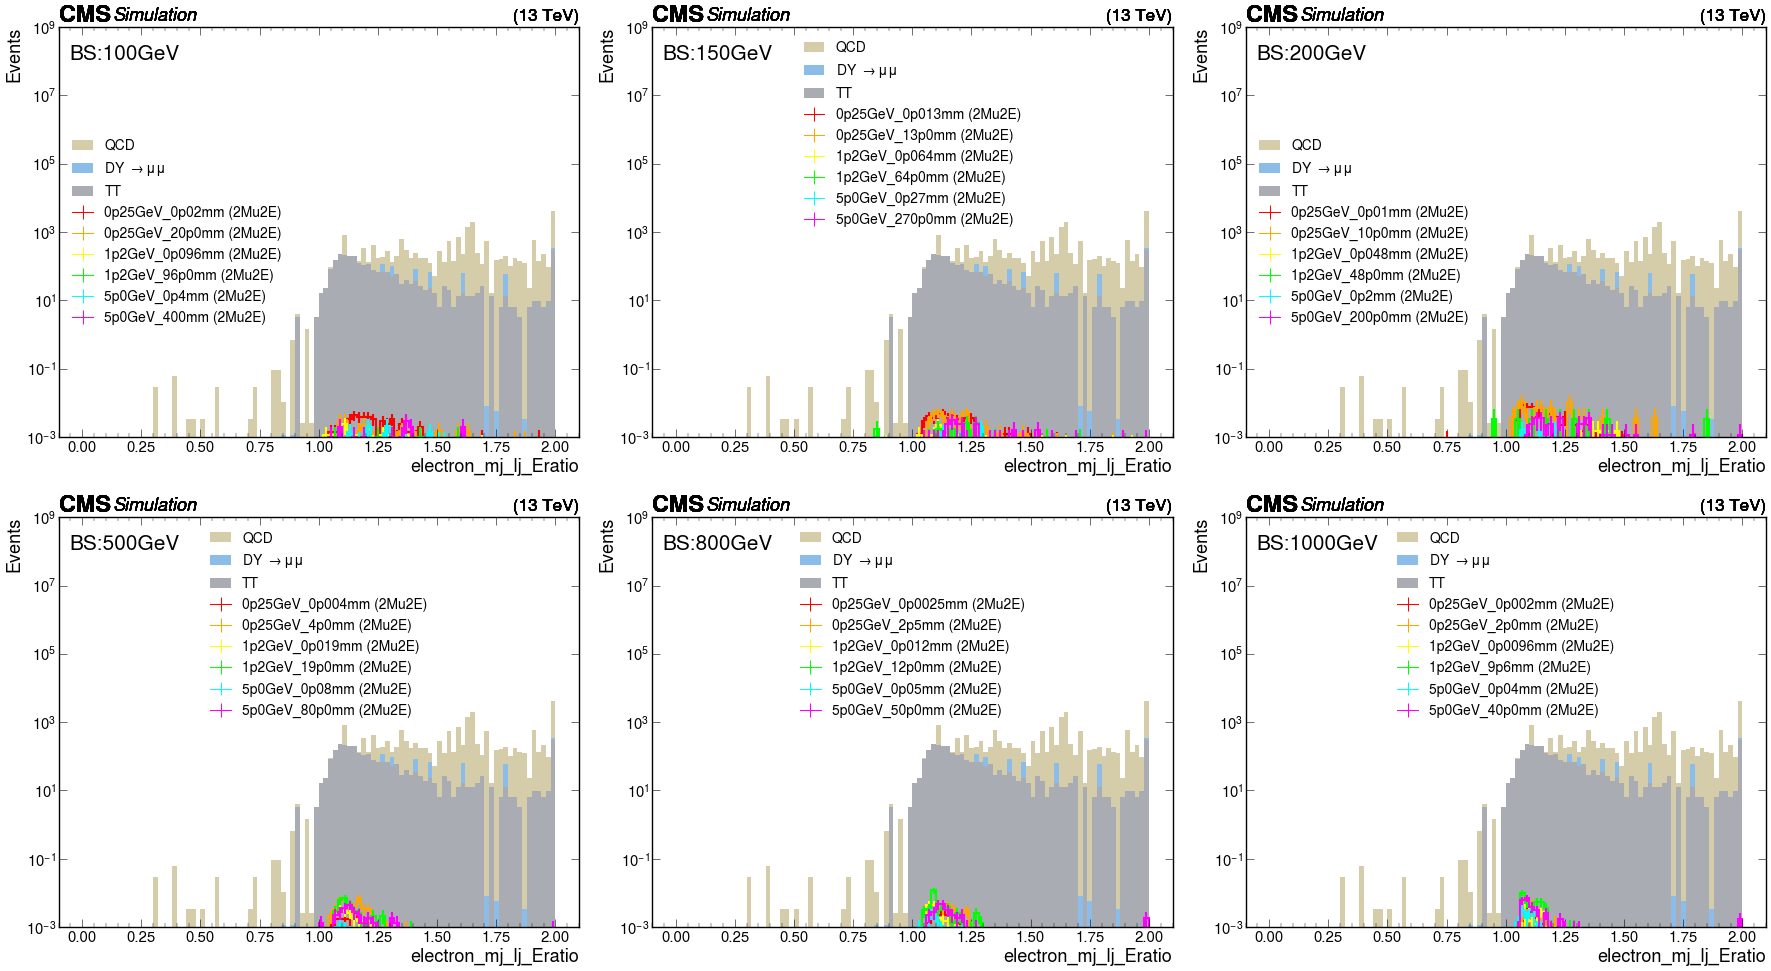

In [54]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="electron_mj_lj_Eratio",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


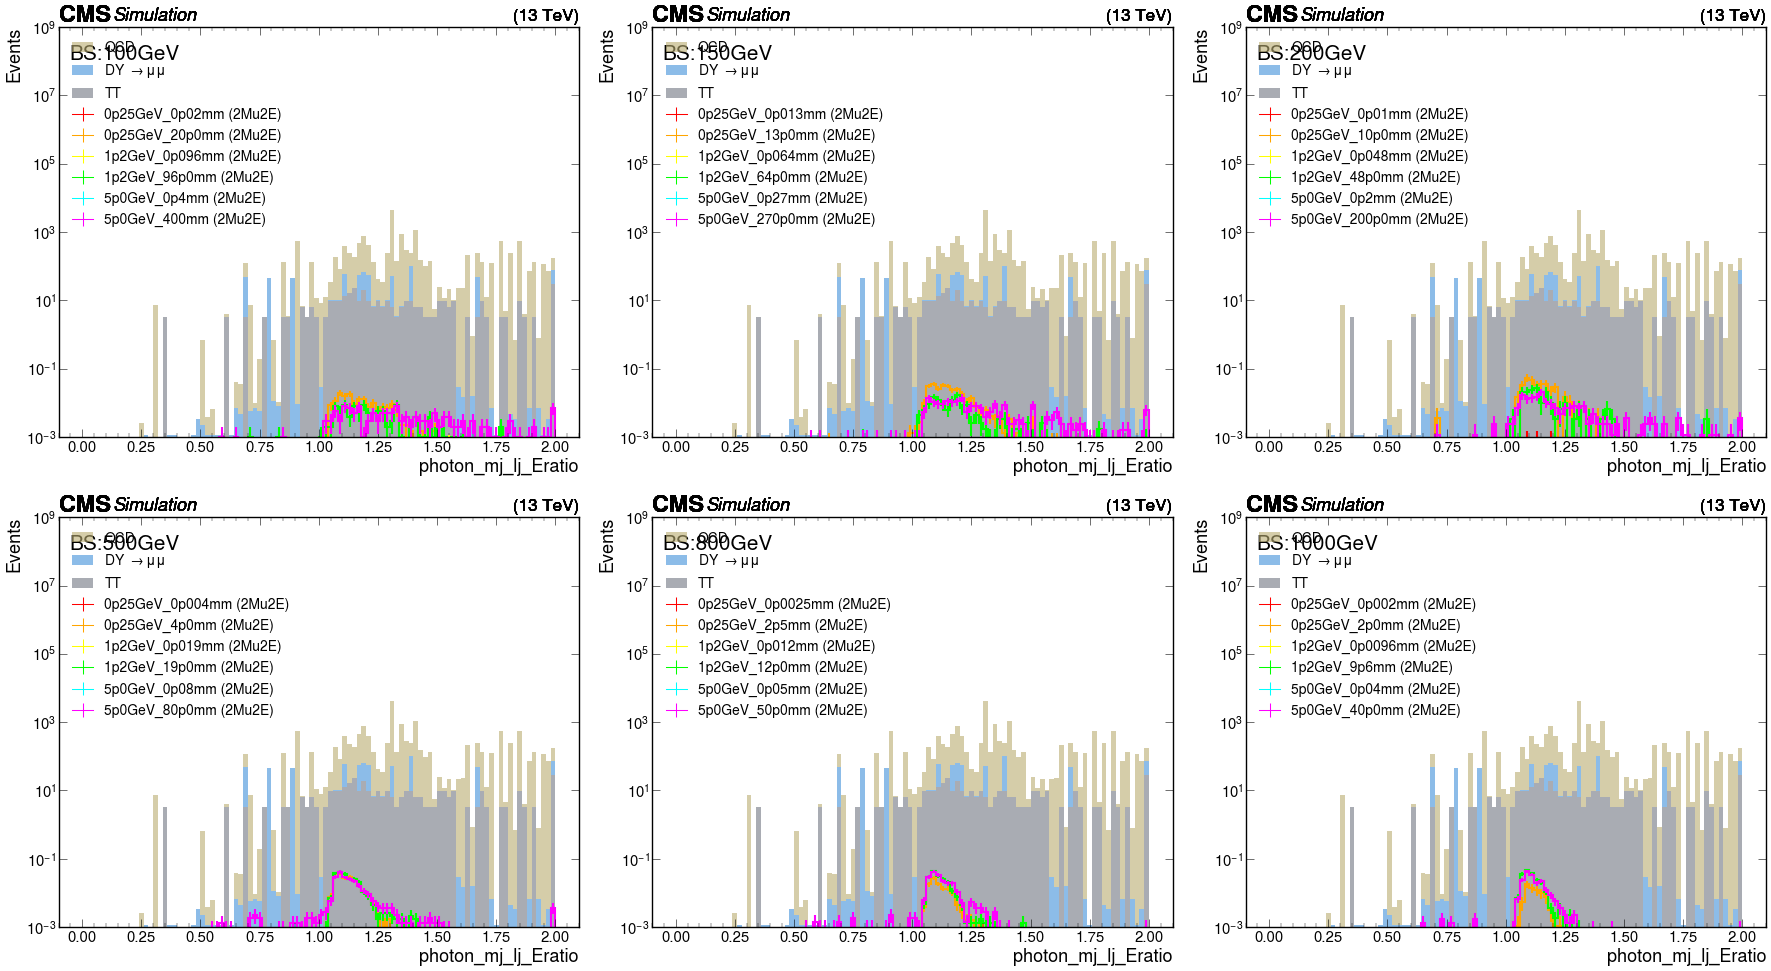

In [55]:
fig, axes = utilities.plot_MC_sig_vs_bkg_panels(
    out=out,
    channels=channels,
    backgrounds=backgrounds,
    signal_maps=signal_maps,
    variable="photon_mj_lj_Eratio",
    background_colors=background_colors,
    signal_colors=signal_colors,
    signal_linestyles=signal_linestyles,
)